In [11]:
import scanpy as sc
import numpy as np

In [585]:
def plot_gene_scdata(scdata2,gene='SOX9',nmax=20,sz_min=5,sz_max=30,transpose=1,flipx=1,flipy=1,tag='X_spatial'):
    Xcells = scdata2.obsm[tag][:,::transpose]*[flipx,flipy]
    ign = list(scdata2.var.index).index(gene)
    #scdata2.obsm['X_umap']
    if 'X_raw' not in scdata2.obsm:
        Xnorm = (np.exp(scdata2.X)-1)
        ncts = np.sum(Xnorm,axis=1)[0]
        scdata2.obsm['X_raw']=np.round(Xnorm/ncts*np.array(scdata2.obs['total_counts'])[:,np.newaxis])
    cts = scdata2.obsm['X_raw'][:,ign].copy()
    plt.style.use("dark_background")
    cts[np.isnan(cts)]=0
    #cts[cts>20]=0
    ncts = np.clip(cts/nmax,0,1)
    size = sz_min+ncts*(sz_max-sz_min)
    from matplotlib import cm as cmap
    #cols = cmap.coolwarm(ncts)
    cols = cmap.coolwarm(ncts)

    good_cells = slice(None)
    good_cells = np.argsort(cts)

    #blanks = [gn for gn in df.columns if 'blank' in gn]
    #blanks_cts = np.nanmean(df[blanks],axis=-1)
    #good_cells = blanks_cts<th_blank

    XC = -Xcells[good_cells,::-1]
    #viewer = napari.view_points(XC,size=size[good_cells],face_color=cols[good_cells],name=gene)
    fig = plt.figure(facecolor='k',figsize=(15,15))
    plt.title(gene+' - N max '+str(nmax))
    fig.set_facecolor('black')
    plt.scatter(XC[:,0],XC[:,1],c=cols[good_cells],s=size[good_cells])
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.axis('equal')
    plt.tight_layout()
    return fig

def plot_cluster_scdata(scdata,clusters=[1,2],transpose=1,flipx=1,flipy=1,sbig=30,small=5,plot_legend = False):
    import matplotlib.pyplot as plt
    cmap = scdata.uns['cmap']
    fig = plt.figure(figsize=(10, 10), facecolor="black")

    from matplotlib import pylab as plt
    x,y = (scdata.obsm['X_spatial']*[-flipx,-flipy])[:,::-transpose].T
    
    #np.unique(scdata.obs["leiden"].astype(np.int))[::-1]
    plt.scatter(x, y, c='gray', s=small, marker='.')
    for cluster in clusters:
        cluster_ = str(cluster)
        inds = scdata.obs["leiden"] == cluster_
        x_ = x[inds]
        y_ = y[inds]
        col = cmap[int(cluster) % len(cmap)]
        plt.scatter(x_, y_, c=col, s=sbig, marker='.',label = cluster_)
    
    plt.grid(False)
    plt.axis("off")
    plt.axis("equal")
    if plot_legend:
        plt.legend()
    plt.tight_layout()
    return fig

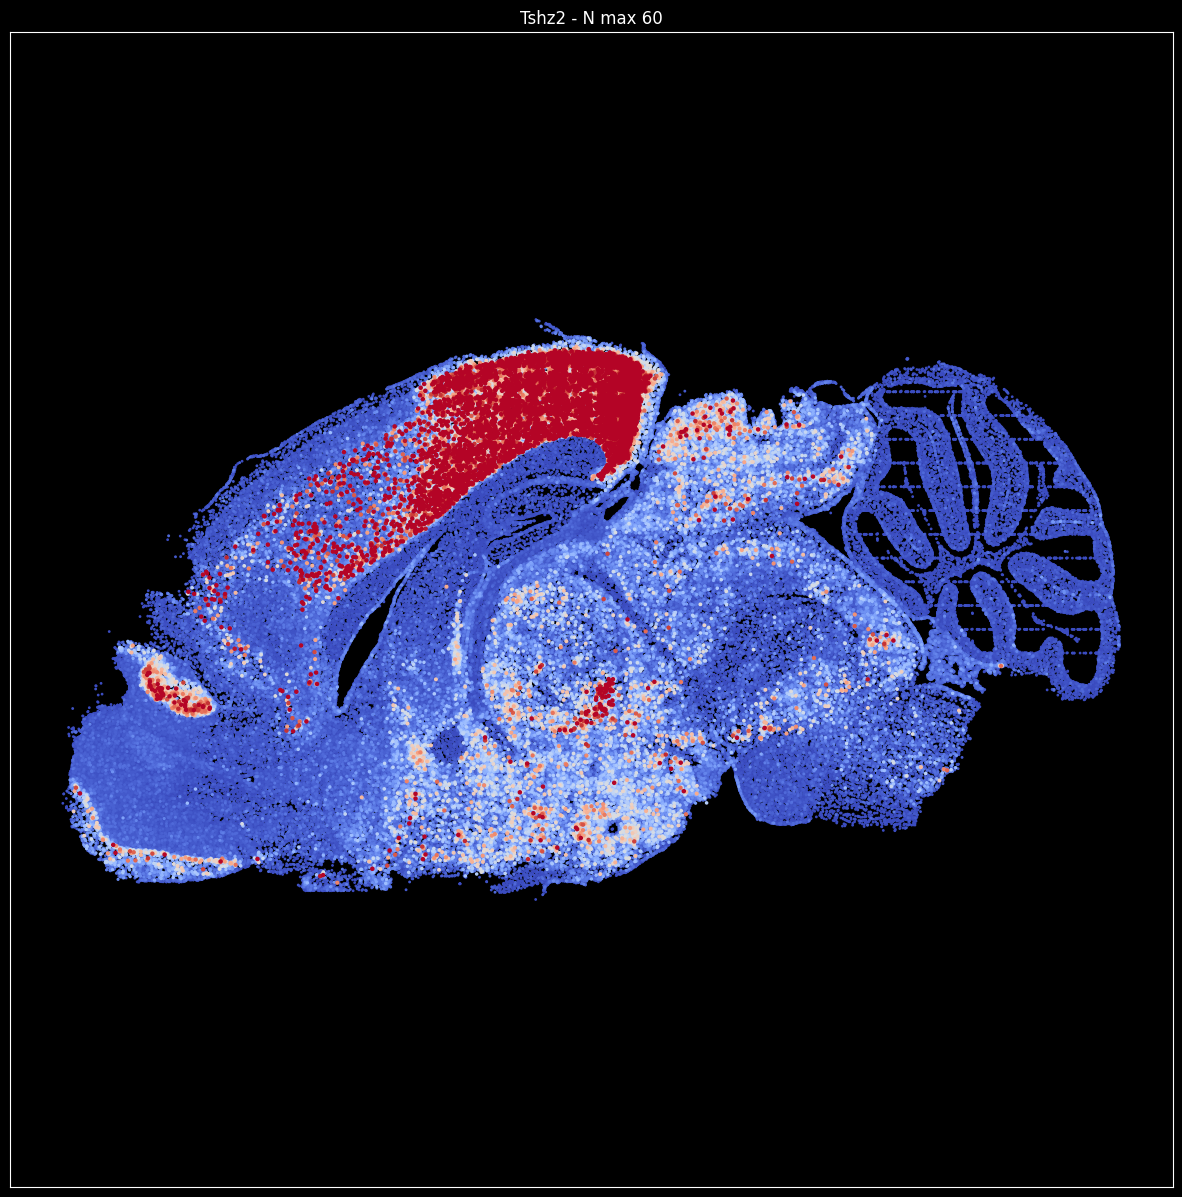

In [238]:
plot_gene_scdata(scdata,gene='Tshz2',nmax=60,sz_min=1,sz_max=5,transpose=-1,flipx=-1,flipy=1,tag='X_spatial');

In [232]:
np.sort(list(scdata.var.index))

array(['2900052N01Rik', '4930509J09Rik', '9330158H04Rik', 'A630012P03Rik',
       'A830036E02Rik', 'Abcc9', 'Abi3bp', 'Acta2', 'Adamts19', 'Adamts2',
       'Adamts9', 'Adamtsl1', 'Adcy2', 'Adcyap1', 'Adgrf5', 'Adgrv1',
       'Adra1a', 'Adra1b', 'Agt', 'Agtr1a', 'Angpt1', 'Ankfn1', 'Apela',
       'Aqp1', 'Aqp4', 'Aqp6', 'Arhgap15', 'Arhgap25', 'Arhgap28',
       'Arhgap36', 'B230323A14Rik', 'Baiap3', 'Barhl1', 'Barhl2',
       'Bcl11a', 'Bcl11b', 'Bmp3', 'Bmp4', 'Bmpr1b', 'Bnc2',
       'C030029H02Rik', 'C1ql1', 'C1ql3', 'C230014O12Rik', 'Cacng3',
       'Calb1', 'Calb2', 'Calcb', 'Calcr', 'Caln1', 'Car4', 'Cartpt',
       'Casr', 'Cbln1', 'Cbln2', 'Cbln4', 'Ccbe1', 'Ccdc3', 'Ccn3',
       'Ccn4', 'Ccnd2', 'Cd247', 'Cd24a', 'Cd34', 'Cd36', 'Cdh20', 'Cdh6',
       'Cdh9', 'Cdkn1a', 'Cftr', 'Cgnl1', 'Chat', 'Chn2', 'Chodl',
       'Chrm2', 'Chrm3', 'Chrnb3', 'Chst9', 'Cidea', 'Cited1', 'Ckap2l',
       'Cldn5', 'Clic5', 'Clic6', 'Cnih3', 'Cnr1', 'Cntn6', 'Cntnap3',
       'Col11a1', 'C

C:\Users\ClevelandLab\anaconda3\envs\cellpose\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:371: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\ClevelandLab\anaconda3\envs\cellpose\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:381: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(
C:\Users\ClevelandLab\anaconda3\envs\cellpose\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


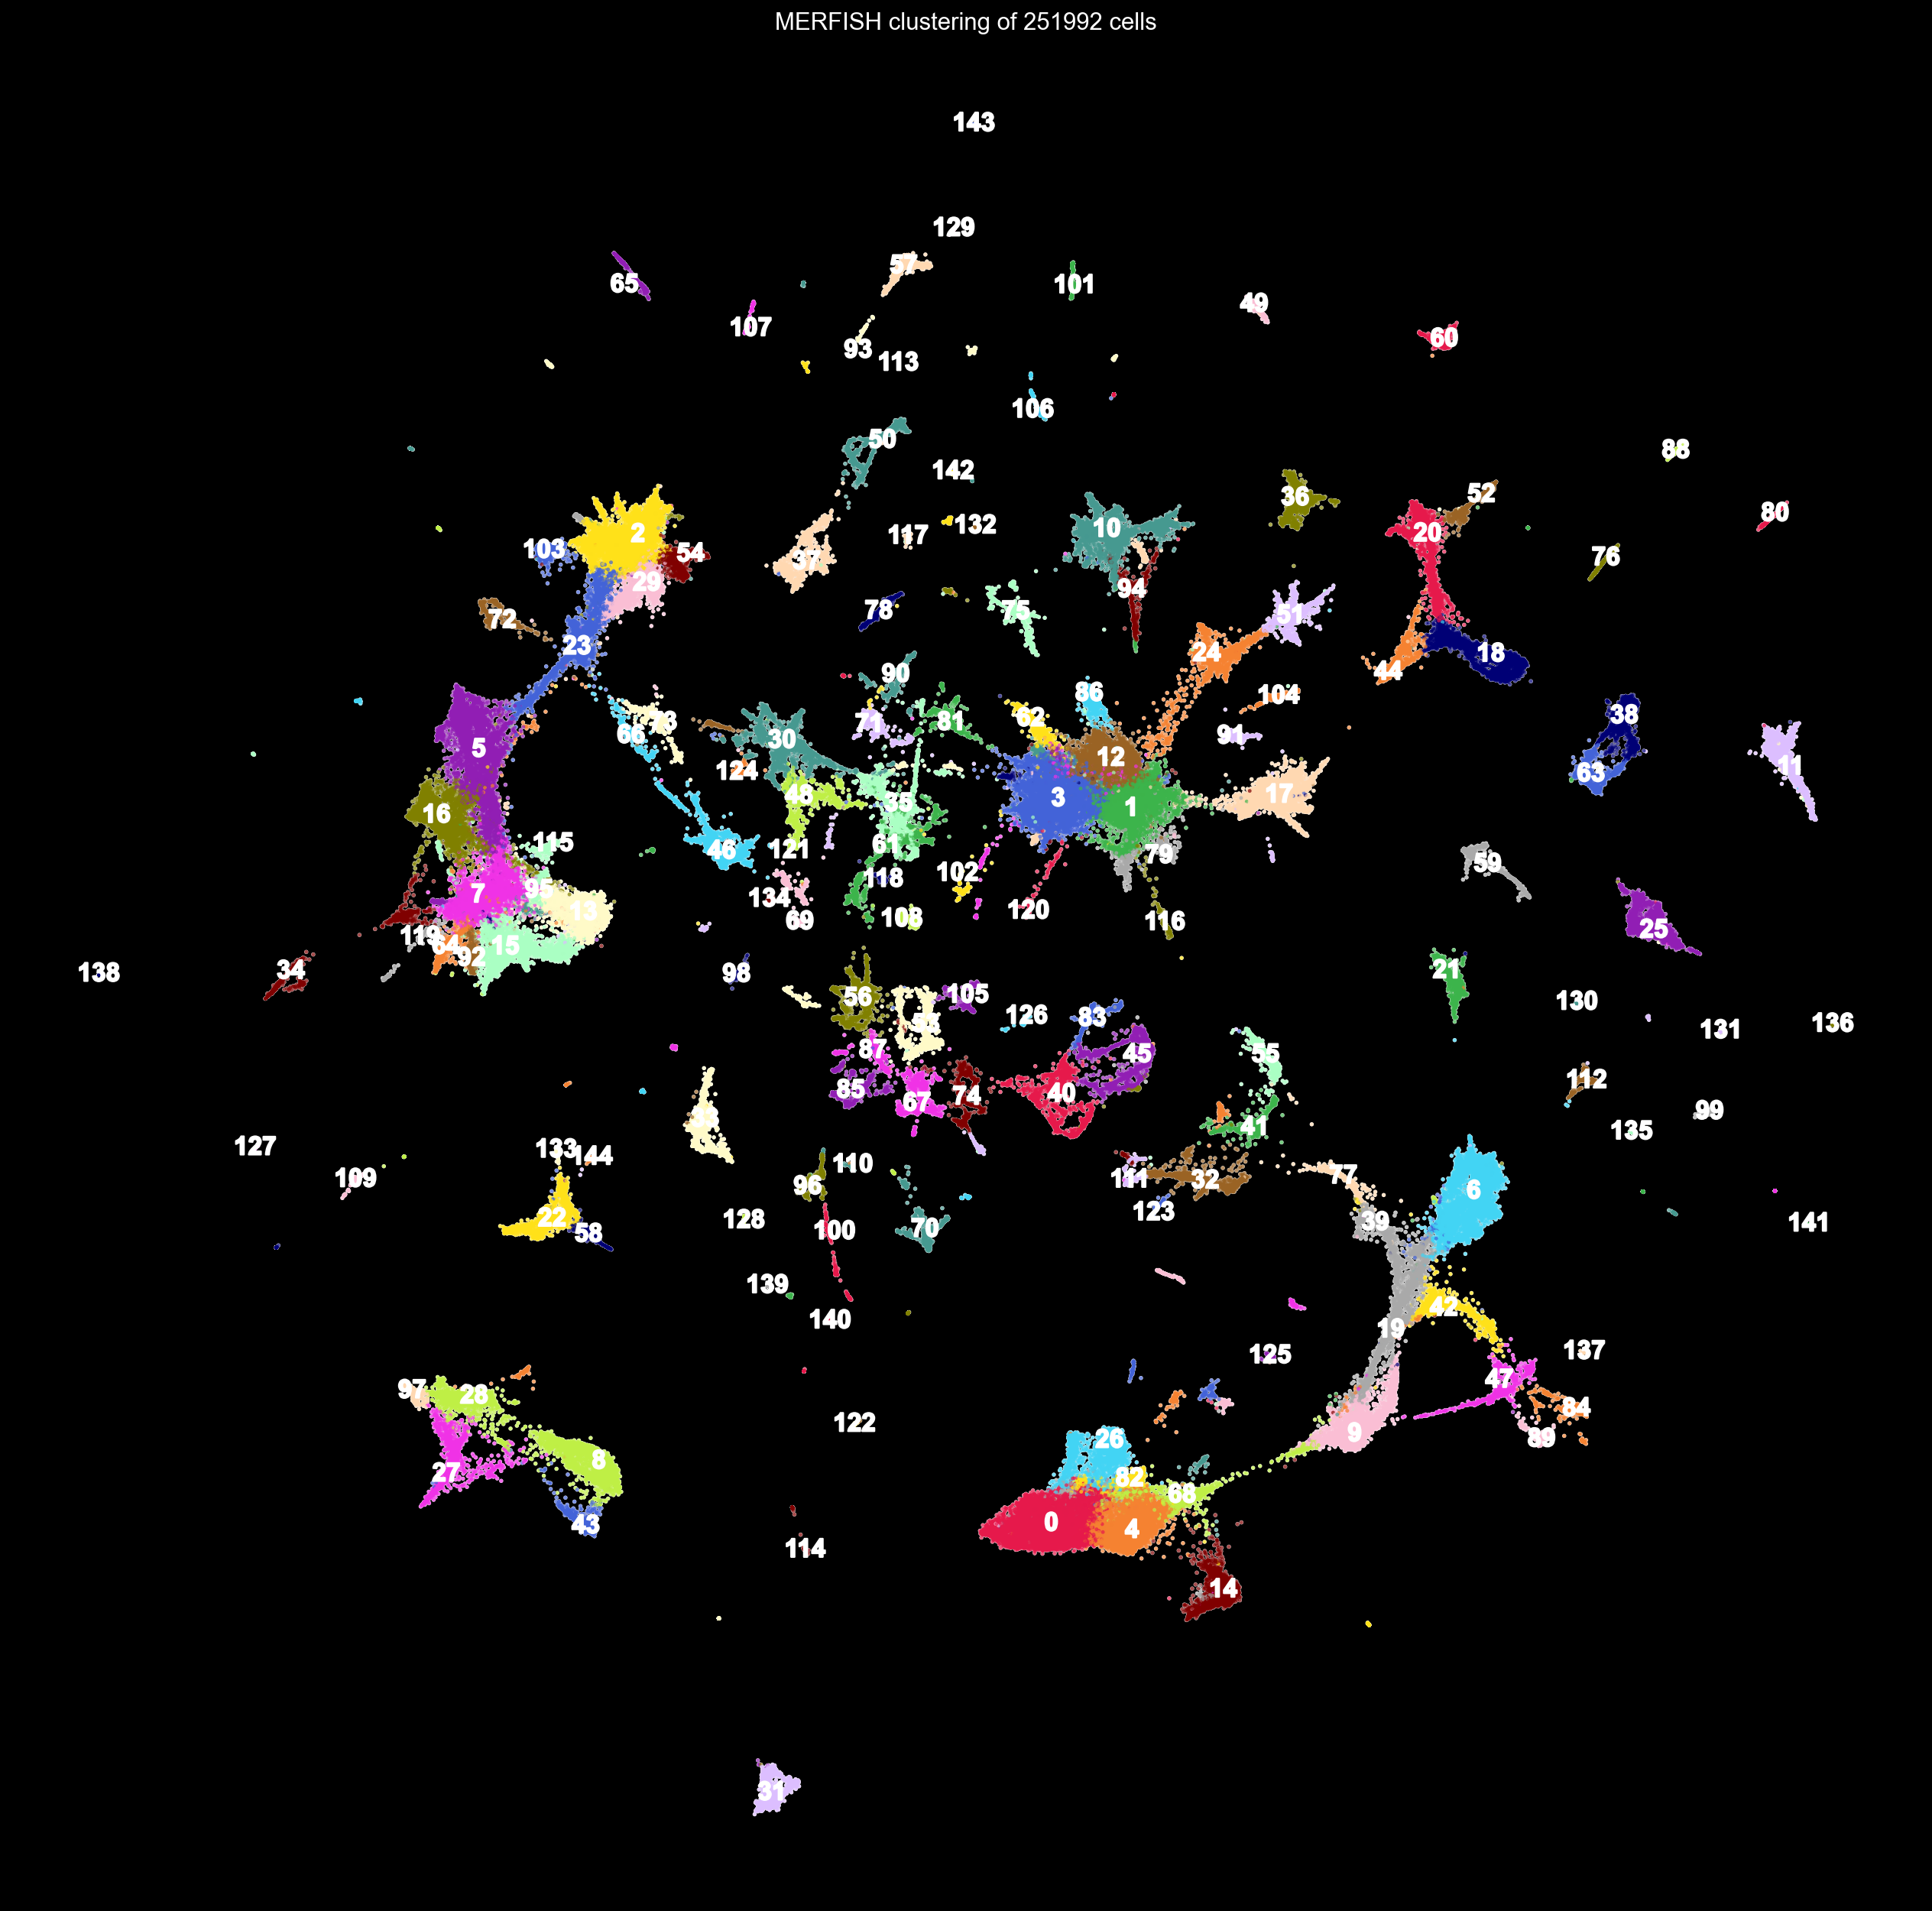

In [247]:
sc.set_figure_params(figsize=(20,20))
sc.pl.umap(
    scdata,
    color="leiden",
    add_outline=True,
    legend_loc="on data",
    legend_fontsize=15,
    legend_fontoutline=1,
    frameon=False,
    title=f"MERFISH clustering of {len(scdata)} cells",
    palette=list(scdata.uns['cmap']),size=20
)

In [318]:
leiden = scdata.obs['leiden'].astype(int)
uleiden = np.unique(leiden)
X = np.array(scdata.X)
X_per_cluster = np.array([np.mean(X[leiden==icl],axis=0) for icl in uleiden])

In [321]:
genes = list(scdata.var.index)
import pandas as pd
df = pd.DataFrame(X_per_cluster,columns=genes,index=uleiden)
scdata_small = sc.AnnData(df)

C:\Users\ClevelandLab\anaconda3\envs\cellpose\lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [325]:
scdata_small.write_h5ad('scdata_small_test.h5ad')

In [329]:
import pandas as pd
df_cell_type = pd.read_csv(r'C:\Users\ClevelandLab\Downloads\scdata_small_test_10xWholeMouseBrain(CCN20230722)_CorrelationMapping_UTC_1739822561948.csv',
           skiprows=4)

In [402]:
classes = np.array([ df_cell_type.loc[i]['class_name'][3:] for i in np.arange(len(df_cell_type))])
subclasses = np.array([ df_cell_type.loc[i]['subclass_name'][4:] for i in np.arange(len(df_cell_type))])
uclasses = np.unique(classes)
usubclasses = np.unique(subclasses)
#len(uclasses)
scdata.obs['class']=classes[leiden]
scdata.obs['subclass']=subclasses[leiden]
uclasses

array(['Astro-Epen', 'CB GABA', 'CB Glut', 'CNU-HYa GABA', 'CNU-HYa Glut',
       'CNU-LGE GABA', 'CNU-MGE GABA', 'CTX-CGE GABA', 'CTX-MGE GABA',
       'DG-IMN Glut', 'HY GABA', 'HY Glut', 'HY MM Glut', 'IT-ET Glut',
       'Immune', 'LSX GABA', 'MB Dopa', 'MB GABA', 'MB Glut',
       'MB-HB Sero', 'MH-LH Glut', 'MY GABA', 'MY Glut', 'NP-CT-L6b Glut',
       'OB-CR Glut', 'OB-IMN GABA', 'OEC', 'OPC-Oligo', 'P GABA',
       'P Glut', 'Pineal Glut', 'TH Glut', 'Vascular'], dtype='<U14')

In [579]:
np.unique([scl for scl,cl in zip(scdata.obs['subclass'],scdata.obs['class']) if 'HY' in cl],return_counts=True)

(array(['ACB-BST-FS D1 Gaba', 'AHN Onecut3 Gaba',
        'AHN-RCH-LHA Otp Fezf1 Glut', 'ARH-PVp Tbx3 Glut',
        'DMH Nkx2-4 Glut', 'DMH-LHA Vgll2 Glut', 'LHA Barhl2 Glut',
        'LHA Pmch Glut', 'MEA-BST Lhx6 Sp9 Gaba', 'MM Foxb1 Glut',
        'MPO-ADP Lhx8 Gaba', 'MS-SF Bsx Glut', 'NDB-SI-ant Prdm12 Gaba',
        'PH Pitx2 Glut', 'PH-LHA Foxb1 Glut', 'PMd-LHA Foxb1 Glut',
        'PVH-SO-PVa Otp Glut', 'PVHd-SBPV Six3 Prox1 Gaba',
        'PVpo-VMPO-MPN Hmx2 Gaba', 'TRS-BAC Sln Glut',
        'TU-ARH Otp Six6 Gaba', 'VMH Nr5a1 Glut', 'ZI Pax6 Gaba'],
       dtype='<U26'),
 array([ 433,  760, 1037,  651,   98,   87,  487,   57, 1142, 1212,  951,
         140,  775, 2057, 1274,  315,  168, 1440,  720, 1015, 1413, 1379,
         501], dtype=int64))

In [3]:
leiden = scdata.obs['leiden'].astype(int)
uleiden = np.unique(leiden)
nm = 'VMH'
plot_cluster_scdata(scdata,clusters=np.where([nm in cl for cl in subclasses])[0],transpose=-1,flipx=1,flipy=-1,sbig=5,small=1,plot_legend = False);
plt.title(nm,color='w')

NameError: name 'scdata' is not defined

In [2]:

leiden = scdata.obs['leiden'].astype(int)
uleiden = np.unique(leiden)
# plot_cluster_scdata(scdata,clusters=np.where(['HY' in cl for cl in classes])[0],transpose=-1,flipx=-1,flipy=-1,sbig=5,small=1,plot_legend = True);
muti_clusters = ['L2/3 IT RSP Glut', 'L4 RSP-ACA Glut', 'L4/5 IT CTX Glut',
       'L5 ET CTX Glut', 'L5 IT CTX Glut', 'L5 NP CTX Glut',
       'L6 CT CTX Glut', 'L6 IT CTX Glut']
plot_cluster_scdata(scdata,clusters=np.where(np.in1d(classes,muti_clusters))[0],transpose=-1,flipx=-1,flipy=-1,sbig=5,small=1,plot_legend = True);

NameError: name 'scdata' is not defined

In [2]:
scdata = sc.read_h5ad(r'scdata_12_11NoT7_BRBB500gn_withCRE.h5ad')

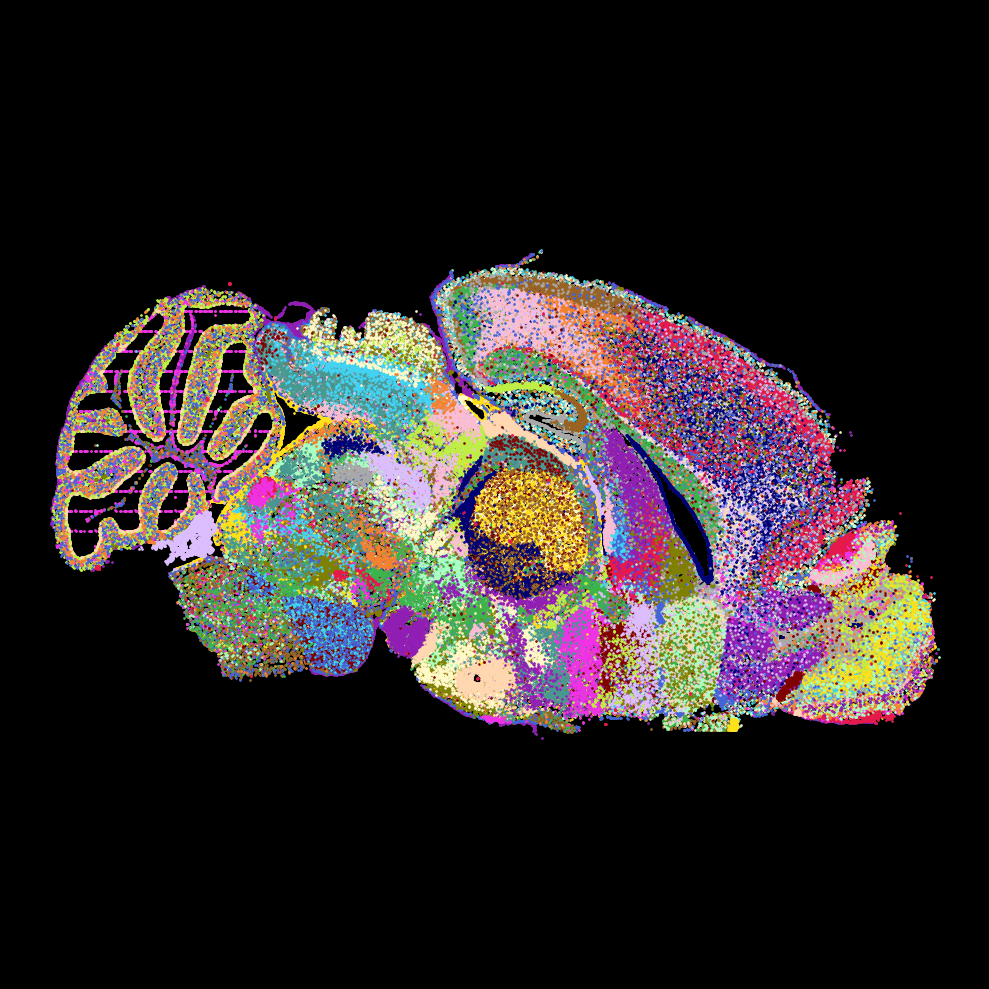

In [15]:


leiden = scdata.obs['leiden'].astype(int)
uleiden = np.unique(leiden)
plot_cluster_scdata(scdata,clusters=uleiden,transpose=-1,flipx=-1,flipy=-1,sbig=3,small=1,plot_legend = False);

In [257]:
len(scdata),

251992

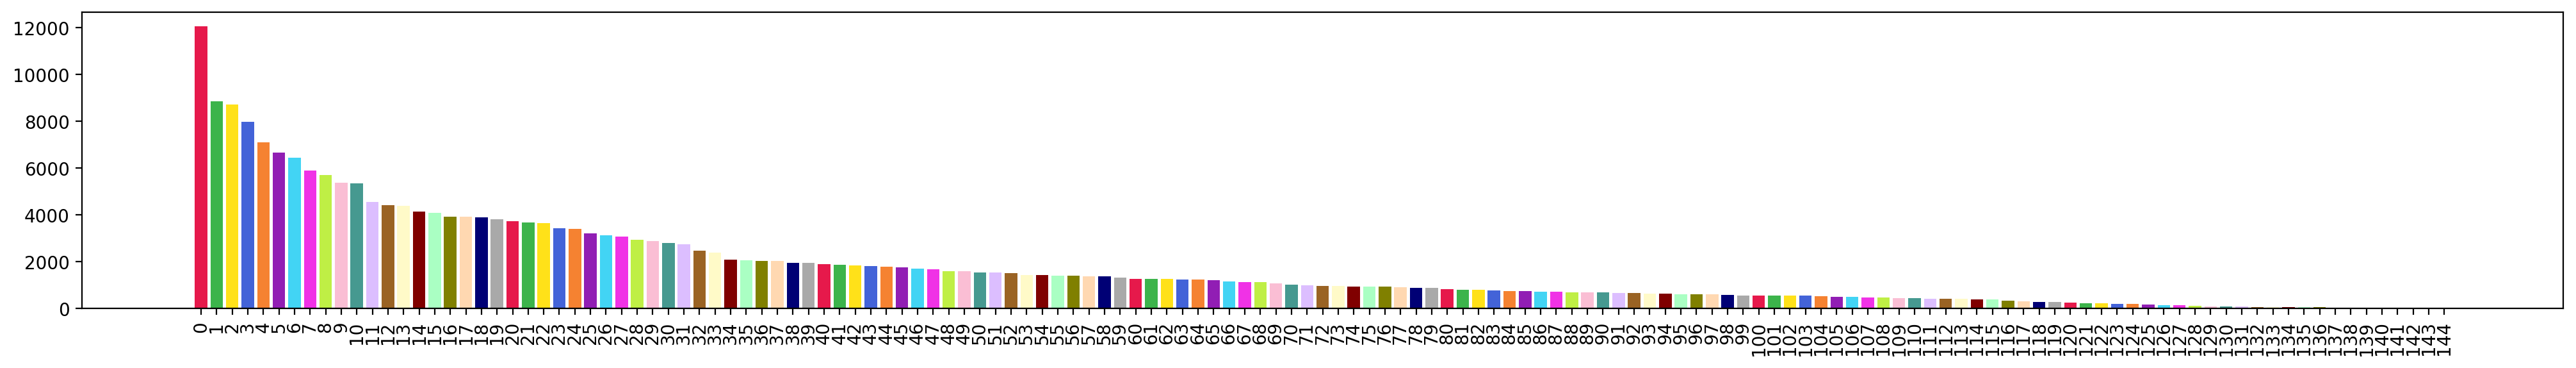

In [272]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Reset to default settings
rcParams.clear()
plt.rcdefaults()
clusters,cts = np.unique(leiden,return_counts=True)
plt.figure(figsize=(25,3))
plt.bar(clusters,cts,color=scdata.uns['cmap'])
plt.xticks(clusters,clusters,rotation='vertical');

In [276]:
cre_df = scdata.obsm['CRE']
creM = np.array(cre_df)
cres = list(cre_df.columns)

Text(0, 0.5, 'Number of counts per CRE\n >20 CRE molecules')

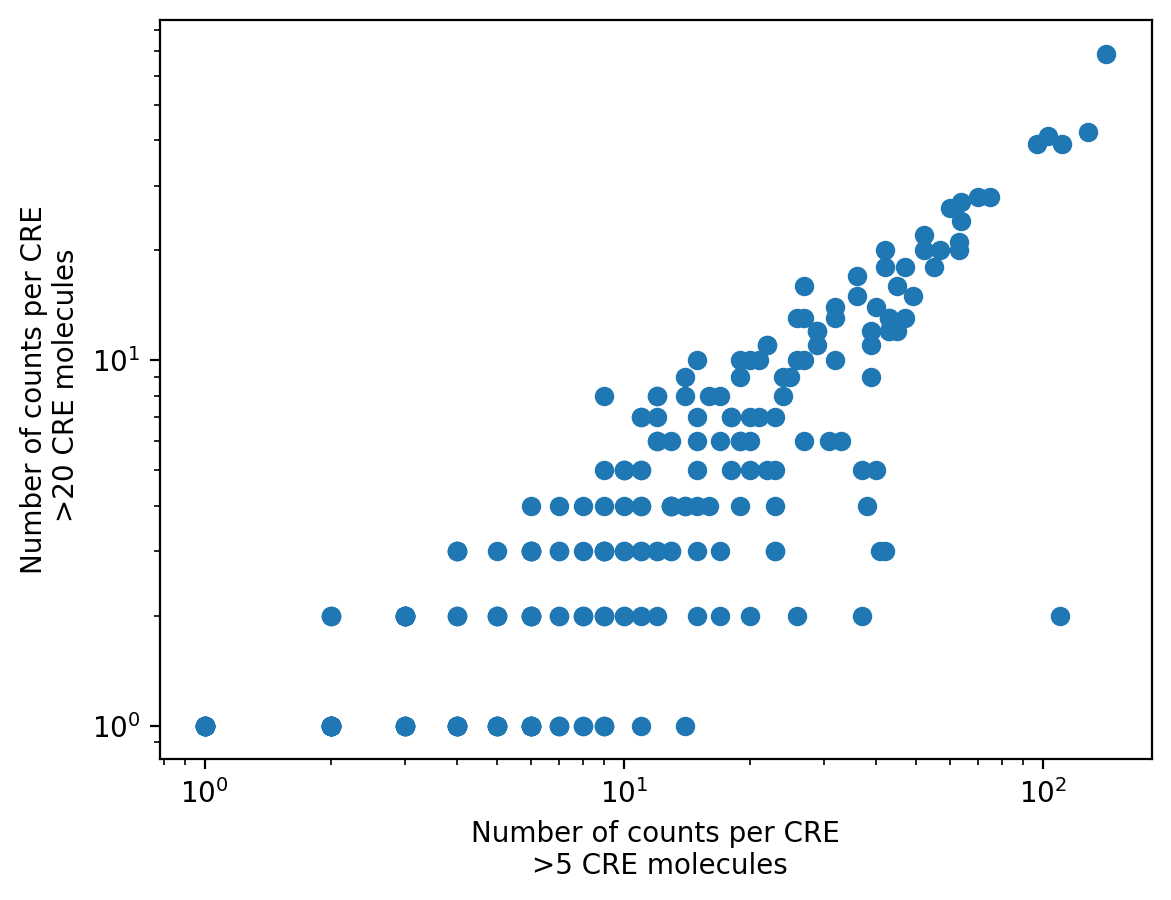

In [294]:
num_cell_per_cre = np.sum(creM>5,axis=0)
num_cell_per_cre_2 = np.sum(creM>20,axis=0)
plt.loglog(num_cell_per_cre,num_cell_per_cre_2,'o')
plt.xlabel("Number of counts per CRE\n >5 CRE molecules")
plt.ylabel("Number of counts per CRE\n >20 CRE molecules")

Number CRE+ cells 4337


C:\Users\ClevelandLab\AppData\Local\Temp\ipykernel_4852\806868614.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_[:,0],X_[:,1],s=0.2,c=[0,1,0])


(-8501.257095696326,
 5381.970428022302,
 -4512.6264520998875,
 3106.1546761407603)

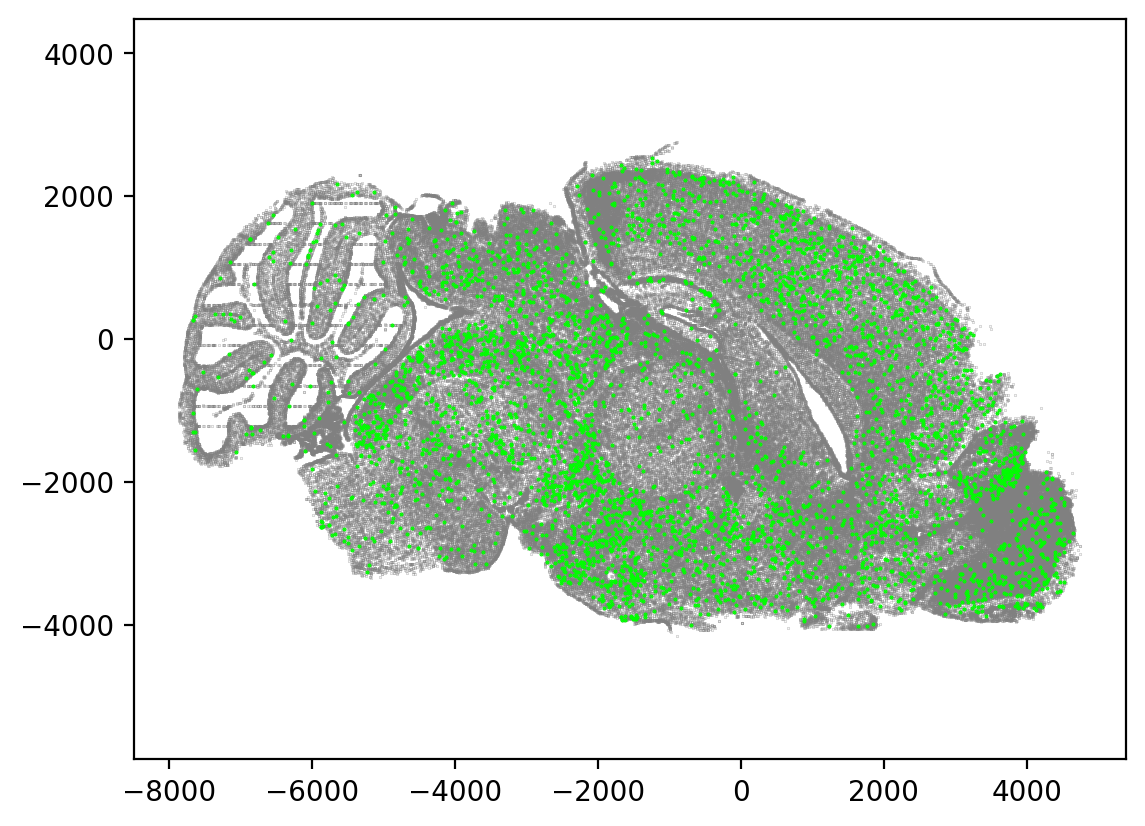

In [306]:
cell_is_positive = np.any(creM>5,axis=-1)
#cell_is_positiv
print("Number CRE+ cells",np.sum(cell_is_positive))
X = scdata.obsm['X_spatial']
X_ = X[cell_is_positive]
plt.figure()
plt.scatter(X[:,0],X[:,1],s=0.01,c='gray')
plt.scatter(X_[:,0],X_[:,1],s=0.2,c=[0,1,0])
plt.axis('equal')

In [461]:
subC,nsubC = np.unique(scdata.obs['subclass'],return_counts=True)
dic_subC = dict(zip(subC,nsubC))
icellP,icreP = np.where(creM>5)
subC,nsubC = np.unique(scdata.obs['subclass'][icellP],return_counts=True)
dic_subCPositive = dict(zip(subC,nsubC))
dic_fr = {cell:(dic_subCPositive.get(cell,0),dic_subC.get(cell,0),dic_subCPositive.get(cell,0)/dic_subC.get(cell,0)) for cell in dic_subC}
cellsNew = np.array(list(dic_fr.keys()))[np.argsort([dic_fr[cell][-1] for icell,cell in enumerate(dic_fr)])[::-1]]
dic_fr = {cell:dic_fr[cell] for cell in cellsNew}

In [494]:
txt = """enh	label	labeling_type	subclass_num	best_subclass	sequence
chr14:36984234-36984733	ABC_NN	subclass	329.0	ABC_NN	ttaatctcagctagcctaactctggaacttttgtgtttatttttatgatgtccaacataagcaagaatcctgctaggttggtttgactagaatcctccatcctccttatgtgaccaccgcctaacagacttctcaccagcaccagcctccaggcgatgtctacactccacacctttcttgagcaagcacc
chr2:75751950-75752449	ABC_NN	subclass	329.0	ABC_NN	TGGCTTTCACGGCCGTTCCCCTCCTTTGGCTTGCTCTCATGAGAAGTTTGATACTTTCCTAGGTGTTTCTAATTCCAGTGTTAAGCACCTAGGACTAGATCTCACAGTGAGACGGGTGGGTGAATGTTACATAGCCCTCCCCTCAGAGGCCAGTCTGAGGGCGGGTGTCCAGTTAATCCTTTTCAGATCA
chr4:115398710-115399209	ABC_NN	subclass	329.0	ABC_NN	GCTTGCCTAATGAAAAATAAATGGGTGTTGCTCTCCGAAGTCATGTTCAGCCAGTGTAAATTTATAAGGTTCTGTTCCCTCAGATTAGGTTCTCTCTGTCTGTTTAGCTATACTCAACTGTCAGAACAACAAAAGTGACCCTGATCTCCTCCCTCCAAGCAAAACAAACTCCAGTGTTTTTTGAGCTTAC
chr18:77340500-77340999	Thalamus	region	151.0	TH_Prkcd_Grin2c_Glut	tttctgaacaccccactgatacctcaattccaccaccaagctcattgctctctatgcatttgtcttctctgccagacttgagcccctggggatagggcagggcggctgtactgattcttttgtctgtctcggtgcccagcaGACTCCCGGGGCTGTGGCCCTGCGCTAATTTGCAGGGCTGCCATGTGGA
chr5:116732027-116732526	Thalamus	region	151.0	TH_Prkcd_Grin2c_Glut	TTCCTTTCAAGGACATCTTGGCAAATTCAAAAGTCGGCCACATCTCTATTGGAACTCTCCTTTTATCCTTTCTTTGTGAATGTCACCAGTTCACAGACTGTCCAAATCAGGTGGCCGGTGCTATAAATGAGGACCAGGCAGAAAAAGTTCTATGCCGGCCCAGCAGGGGGCCAGACAACTTTTTCCTACT
chr8:23523246-23523745	Thalamus	region	149.0	PVT-PT_Ntrk1_Glut	CTTTGATATCATCCCAAAGAAGTCTCCCTCCGACTATCTGCAAGGACATGATACTTATTATCCCCAAGTCACCATGGAGGAGCCACATCAGAGATATTCATGCAAGAACTCCACTCATGGCCTCCATAGTGTGAACCCTCTTGTGTTGTTAGGGTATGAGTCATCCTGTACCCTGTGTTTCTGTTTGAAG
chr15:92512225-92512724	Thalamus	region	149.0	PVT-PT_Ntrk1_Glut	GTGTTATCTAAGTGATGCCTTTTGAAGATTAATGTCAGCATCACAGAGGTGAATCATTTGAGAGTCCCTAACTGGTGCTGTGCTCTGGATGTTGCTATCCCTCAAAGTTCCATATCCCGAAGGCTATGTTCTCCAGCCATACTGCTGGGAATGTGAACATTTAGCAGATGGGGGGTCTCAGGAGAACGCT
chr15:84277539-84278038	Thalamus	region	93.0	RT-ZI_Gnb3_Gaba	AACTTCCCTCTGGTGTCTTAGTGGCCTTTTCTGTCGCCCACTACTTTACGATACATCTTTGCAGTGCTGCGGGCTGCCCTCTGCCTTTTGTCTGAAGTCCCTGGCCCTGGCTGGGCAGGCACTGGAATGAGGTTGACTATTAAAAACTATTTTGAGCATCTGTCGTGCTTATTGGGCTATTAAGGGGCGA
chr7:38318050-38318549	Dentate Gyrus	region	37.0	DG_Glut	TCCACATGATGTCTGAAATGAGATTTACTCCTCTTCTGTCAGCTGTTAAATAATTTGACACAATTGCCAAGATCATGCTTGAAAGTATGCTCCTGGTTGTAGATGGCACAGGGAAAAAACATTGTCCTTCTGTAGCACTGTCAACCCAAGATGAGTATTGCCAGGACTCTGAAATTAAGCAGATTgagag
chr8:47566720-47567219	Lateral Septal Complex	region	71.0	LSX_Prdm12_Zeb2_Gaba	AACATCAACTTACACAACCGTCACTCAAATCTCTTTGTCCTCCCAGGGTGAAACTCAATATAGGCAATTCCTGTGGAGGTAAATGCTTTAAGAGCCTCGACGCCCCCACCCTCAAAATGTGTAGTTTCTCCTTTTTGCTTATTAAAGGCATGCCACTCACTCACTAATTCTTTGGCTTGCAGAACGTTCA
chr6:131301569-131302068	Lateral Septal Complex	region	70.0	LSX_Prdm12_Slit2_Gaba	TTTAAATATGAAAGGAGAATAACACCAATCTCCTGTGACCTGAAAAGCAGCCTCTAAAGCATAACCATGGGGAAACTATGTACAGTAGAGTTGCTCCTGTGGATTGTGTGAACATGCAGAAAGGGTGTTTTGGAGAACAAAGGTAATGTTAGGAGATCCTGAGGTTTAAGCAAAGTAACAAAATGAGGCA
chr1:57983476-57983975	Lateral Septal Complex	region	71.0	LSX_Prdm12_Zeb2_Gaba	tatattttcactaaaaggggaaaTTtaaaaagggaaacaatagtggctttcatacaggatcattgtgagagttcaaaaaacatttaccaggcttggcacagtgtgtccaacatggtgagcacttgagagacattATCTACAGTTGTTATTACTTACCATATAGCAGACACAGCAGGAAATTTTCTATTAG
chr15:87158794-87159293	Lateral Septal Complex	region	72.0	LSX_Sall3_Lmo1_Gaba	TTTCTTACCTTTCTTTCTGTGTATTGTGTTAGCTTCATTTATAGCCCCTAAAGAGAGCTGACTTTTACCACTACAATTCTGAGACCTCTTACTGCTTCAGTTTCCCCCAAAGCAAAGTGCTGCTTTAAAGCTATCATGTGGGAGTTTAATTAAAACCCCTGAAATTTTTCTgtattttccttttcattgt
chr14:22612126-22612625	Lateral Septal Complex	region	69.0	LSX_Nkx2-1_Gaba	GTTTTTAAAGGATTTCATGCATTCATTCCAAATATATATTTCTCCCCGAGTGGTTCTGAACCTATAATCTTTTCCTTGTTACATTTCTTTTGGCAGGAAGGGGGGCCAAGGAGGTGACTTGGTTGGGAGTGGAAGGCTCCTATTAAGAGCTACCTCCTCCTTGTGCGGTGTTATTCACAGTAGCGCTATT
chr3:39309463-39309962	Superior Colliculous	region	207.0	SCs_Dmbx1_Gaba	AATAGAGGTCTCTTTAAAGACCTCATTTTAATTTGCATGTGCCCTAGGGATGAAATATGTTCTGTGTGAGCTTTGATGTTGCAGCTCTATTTGGTCTTACTAAATTCTTTATAAAGGCTATTCAGCAATAAGCCCTGGGAAATGGATATATAAAATCCATTTCCATTTTTATCCTATTACTGAATTCTTT
chr10:129064205-129064704	Superior Colliculous	region	187.0	SCsg_Pde5a_Glut	AGTTTTGTCCTCTGAATGATCCACTTAGTTTAACCAAGGCCAATTGTTTGATGTTGGATTGGAACTATTCATTGGAGACTGGTGAGGGTATCAGAGAGTACACAATAGAAGCATCCTTGTACTTTTGATCTTTTATTATGTTAATTAATTCTGTAATGATGTCTTGCTTATATTACTCACTTGGCTCCAG
chr17:4184302-4184801	Superior Colliculous	region	187.0	SCsg_Pde5a_Glut	TCTTAACTCCACAGAGGACCGATGCTTTCCCAGTTAACTTTCAGCTCCCTTTGAAGTTCCAGACAATTTGAGGCTAATCAACCCCCGGAGGGGATCTTTCTAAGCACTATCCTCTGCCACAAGAAGCATCTCTCTGAGCTGCAGACCTAATTTTTCAGCGTGTTCTTACCCCATTTAAGTAGAGGCAAGC
chr12:107489200-107489699	Superior Colliculous	region	187.0	SCsg_Pde5a_Glut	AATTCCTGCATCTCTTCTTTGGGACACCTCATCTCCCCTTAATACCTCCCTGTGCTGGTACAGCCTCTCCTGCTGATCTCTAAATTAGCACATCCTCCATCCACTCCCCTCCAGAGAATTTCAATTCCTTTAATCCAATGAAATGAGAAGTTCAGGCCATCATCTTCAAAGAATAAGAATAAAATTTGGG
chr3:39712712-39713211	Superior Colliculous	region	207.0	SCs_Dmbx1_Gaba	AATAAAACGTTAAGCTCTCAATGTCTGAGTGGTGTGATAAAGGCCCAAGAAACTCTTTCTTCCTTCCCGCTAATTCTCCTAGCTGCTTCTCAGAGATAGGAAACAGGGGTGATGGTAACAGCCTGAATTCCCGCTCATAAGCCTGGAGCAGCTTTGGAGTTTTAAAAAAGGGCTAGAATCCCAAGGATAA
chr5:138409523-138410022	CA1-3	region	16.0	CA1-ProS_Glut	aaattcaagtgacaacagatgctcccaaggatttgagaaagaggaacactcctccattgcttgtgggattgcaagctgttacaaccactctagaaatcaattttgcggttcctcaaaaaattgggaagtaatatccaattggaagatccagcaataccactcctgggcatatacccaaaagatgctccaa
chr7:13450653-13451152	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	tgggaagaggagggaggagggaggagggaggagaggagagATGACATGACAAGAATGAGACAGAGGCTGTGACTGGATGCCAGGCCTGCAAGATTTTCAGAGTGAGCTACATTTGCCAACCTGACAGCAGGAACATGGCCCAGCCTTTGGATTTTCTATTGGTTTCAATCTGCCTGTTTCACAGCCTTTT
chr6:48951041-48951540	OPC_NN	subclass	326.0	OPC_NN	CTCAGTAGCAAAGTGCTGGGGGGCAGGGATGGGGGGCAGGCAGGGAGTAGGAAGTGACCATCAGGTCCAAGACAAAAAGGGTCTTTcatctgcaccacacacacaccaagggttcagggctcattatggatgagagggtaaaaaaagtttaagagccagtgaatgaacacaaggacatagtgtcttctgg
chr4:18169846-18170345	OPC_NN	subclass	326.0	OPC_NN	AAGTGCTCCTTTTACCACCAGCCCATTGAAGGCCACTTTGATTCTTCCATCAACACTGAGAACTGCCAGAAACGTTTCATTTTTTTTCCTATGCCTATTGGCTGTAGAAAAGAAGTTCTAATGAATTCATTGTCAGCAACCATGGCTTTCCTGGACTGCACAAATCTAAATGACACATCAGTTGCACTTG
chr7:64103170-64103669	DG_Glut	subclass	37.0	DG_Glut	taagtatagctttaagagttttaattctaccgggtaattgggtgttgtgatgggtgaccatggggtgcgtggggggagcaatgcatgaaagtgagaagaactggggatgggggggtggcctgccagagagttggcaggttgagagaagcaggagaatggagagttggctggttcatttttaatattttcg
chr2:57197130-57197629	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	TTAGAGAATTTTCTGCTTTACTCtctagtggctgatgatgcatcaaagaacacagaaatgtcctcacagcactaacattccaatgttggagctgggcagtaaatataacataaccacatttacaaaatgttaaatggtgaaaagAGTGCATTTAAAATAAACCTGATgagctggagagatgactcagtgg
chr2:56831685-56832184	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	tttaaaggggtgagattgtgagatatattctattttggagaaagaAAAAGGGCAGTGTAACTATATAGAGAAAAGggagatgtagagaggagtaaataggagatgagatggactggggccgtgaagaacactaagcacactggctttttcctctgaagtgcagagtgtttaaagtttgtgagcaaaagtg
chr9:92834117-92834616	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	AATTTTACTTTAATACAGTAGTGACAGTCCTCTTGGTGCGTTGGCCTTTGGGTGTCATTTCTCATACAGTCTTGTTCAGCAGCGTGAAAATGAGATGACATTCAGGAGCAGCTCTTGGACGGCTGGGTGGGTGGGTAACGTGTGCTGCCGTCCTGAGATTTCACTTTCTTTTCTTTGCCCTTCATATTCT
chr10:48010737-48011236	DG_Glut	subclass	37.0	DG_Glut	atttcacagcacactaatggaaccagaaaatatcatcctgagtgaggtaaccagaatcaaatgaacacacatggtatgtactcactgataagtggatgtttgcccaaaagctcaaaatacccacaatacaacccacaaacaatatggagcttaggaaaaaggaagaccaaagtatggatgcttcaatcct
chr4:52561110-52561609	DG_Glut	subclass	37.0	DG_Glut	gccaatatccacttatcagtgagttcataccatgtgtgttcttgtgtgtctgggttacctcactcaggatgatattttctagttccatgcatttgcctgccaatttcatgaagtcattgtttttaatagctgagtagtactcaattgtgtaaatgtaccatattttctgtacccattcttctgttgaggg
chr7:38544958-38545457	DG_Glut	subclass	37.0	DG_Glut	AGTTCAGTGTCTGCAAAAGCAAGTTGTACATTAATTTTAACTCTCAGAAAAGCCTGCAAATCATAGATCATCTGGGCATAAGCTTGCCATTATGGCATTGGCATGAAAACAGAAAGTTGCTAAACAGTTCAGAGAAATATTCATATTTTTAGCATGTCTAAATTTGCAAAATCTCTCCTGCCAGTTTGTT
chr1:73793226-73793725	DG_Glut	subclass	37.0	DG_Glut	CCATTGACAGTTATTCAAGTTGACACCACTAAAGAGATTGGAGCTTTTATCTATCCCTCCTCCACACCTGGCACCATGTAGGCATACAAATGCTAGGTGGGTGGGTTTTCAAGTTCAAGGGGATAAGCCAATTCATTACACATATCAGTGAAACAGAATTCCAGGAGACATTGCGGCCTAGTAGAACTTA
chr15:62980860-62981359	DG_Glut	subclass	37.0	DG_Glut	AGTCAGAGTTGCTGGAGCTTATTCAAATCATGATTGTGATATTTGGAGAGGAGCCTCCAGTGTTCTCCCGGCCTACTGTTTCTGCATCCTACCCACCATACACAGCAACAGGGCCACCAAATACCTCCTACATGCCAGGCATGCCAAGTGGAATCTCTGCATATCCATCTGGATACCCTCCCAACCCCAG
chr11:15254033-15254532	DG_Glut	subclass	37.0	DG_Glut	tttaatttattttttacactccatattccattccctgtcccccatccaccatctgtctgttccacatttcacacctcctccctaccccaacctatctccacatggatgctcccacccccaaccaacctgatctctaaactccgtgggactttcagtctcttgagggttagatgtatcatctctgaatgaa
chr2:83152279-83152778	Vip_Gaba	subclass	46.0	Vip_Gaba	TATGCTATTCTGCTTCTAATCTGGAACTCTGGTATTGCCCATTTGCCTGGATGAGAATGCCCATGCAGCTGCTGTTCAAAAACCATGCTGACTCCTCATAGAGAGGTTACATTGTCAAGCTTCATTATCAGGGACATTACCCCCAGATTTGAATGAAAATGTGGGACACAGGTGTCCACAAGCGTAATGT
chr15:68002045-68002544	Vip_Gaba	subclass	46.0	Vip_Gaba	CTTTGAAATAAGCCCAGAGCAAATGGGCCTGGAAAGGCCCCTCACCTGCTGAATGGGTCCAGATGGATCCTTTCAAAAGTTGAGTCCTGACCCATAAGCTCATTCTGCCTTTCATTTGTTTAACACAGCTGCAGTAGCATATAGATGGCGTCCAAGCTTTGTAGAGAACAAATTGTTGAAAACAAATATC
chrX:46900754-46901253	Vip_Gaba	subclass	46.0	Vip_Gaba	GGATTTGAAAAACCTTCTATTATCTCATATGTTATTGTGAAAAACCTTCAGAAATGGATAATACCATGGCTTGCTGGCATCAATGGGGCAATTTCATTCAAGCCAGCTGGTTTTTTCCTAGCAGCACCTGCAAAATTACATTGAATTGACCAAAAGACTATCCCAAATTATTAACAATGCCCCAGGGGAC
chrX:92396189-92396688	Vip_Gaba	subclass	46.0	Vip_Gaba	aaggtccagaaacaggcccagagtgtgattcagctcaagcgtacatcccaaggcctgacactattactgagattatgagcactcacaaaaagagacctagaatgactgcccttgaaagacccaccaagcagctgaaagagtatgcagatatttgcacccaaacaatggacagaagcagctgacatctgtt
chr18:87641214-87641713	Vip_Gaba	subclass	46.0	Vip_Gaba	atgtgattcatttacacagtggaatacaattcagctgttaaatacaaggccattatgaattttgcaggcaaaatggttagaacaagaaaataccatcctcagtgaggtaaccaagctccaaatgaatatgcatggcatgtactcactgataattggatattagtcagtatgttcagaatagccatgctac
chr5:75531274-75531773	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	cttgttttctgactttacaggagcccacagttgagagattggcatttttttttaggggattgtggatattttagagagactgaatattttagagagacttgaactttgaaagagactgaatattttaaagaaactgaacttttgaagtgttggaatgtgtaaagactgtgggacttaaacttttggaatg
chr11:77149098-77149597	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	TAAGGTTTGTAAAGATGCTCTTTTCTTGATGGGGGGGGCCTGTGGGGGAAGATTCGTAGAGGAGTTGTAGTTCAGGGGATACACTGAGAGGCTGGACCTATTGACATTACAGCCGGCATCCACTTAGCTTTGAGTTGTCGTTGCTTTTTATATAGTAACATGACATTCTGTTTTAACTCTCAGTGTAGAG
chr2:57194851-57195350	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	ATTGGAGAGGCAACACAGGGCTGTCTGCTTATAACAAGTATAAGGTCAGTATGCGATGAGCACAAGAGCAACACTAAAAAAAGAAATGATGTAGTAGCCACAAAACTGTTTCCTCCCTCTTCATAACTTCATGTATCCTTTTTGGGGCGTCACTgttagggtttcaattactgtgataaaacaccatgac
chr2:118189445-118189944	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	GTTTAAATTTATGCGAGACTCCAGTGCAAACCGGAGTTTTAAAGCTGTAAGAGTCGGTCAGTAGCTTGAGAGGGCTCTCTGATTTGAGAGAAGCAGACCCAACCATGTAAAGGCACATTCTCAAAAATGGTGTGAAAGCCAACACCATTCCCAAGAAGGCTGCTCGGAGACTGTGAGAAACTGATCTGAA
chr13:72725639-72726138	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	TGCCTTGCTTCCTTTTAGAGGAAAGCAATGCCATCTCCTCATCTCGATGGTGATTTGGAGCAGGAAGCTAGATGAGGAGCTCCTGCAGGCCTGCCGGCTGTCACCTTGAATATGGTGATCGCCTTCCACCTGGCTCTGTAGGAGAACTGGAACAGACTTCTCTAGGGCAGCTACAAAGTCAAGTCCCCTG
chr2:171227355-171227854	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	AAGTATGAAGTCACAGTCACAGATGGGACAGTGAGACAGCAAAGCAGGCACTCTTGCTGTGTGGACAAACCTGTGAAGGATTGCTGTAAGGTATCTCACTGACAGCTCTTGGCATTAAAAGGCAGGATACTCTACACTCAGCTCTTTTGAACTTCCATTTCAGTTGTCAGTGTTGTTATTTTTCCCCAAC
chr14:43029928-43030427	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	cgccgagtgtgtcctgtacaggcaggtgactattttcccagtcagaggatagggacttgcctggcgcgggagtgctttgcctgagcattggcagcagacatcttagttccaggaccctgccgagtgtaccctgcacagacatcttagttccaggatcctgctgagtgtatcctgcacagctccagagaat
chr6:133838231-133838730	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	ccatctggtattccttggagctgtgcaggatatactcggcggggtcctggaactaagatgtctgtgcagtgtacactcagcagggccccggtactaagatgtctgctgccaatgctagggcaaagcgttcccgcgccgggcaggcccctatcttctggccaggaaaatggtcacctgcctatataggata
chr17:55140681-55141180	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	catctccgggaacagccagagaccttacataaggcaggctcccaagaatcactgtgggtgaccttagttgtgactcactacattatggatatggaacctgaggaggccacctcctgtaacctggcaggaaccccagcaaagctatagagactccaacctacccacaaaattttcaacccaaaatttatcc
chr8:56419921-56420420	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	acatctacacaaactcaaattatgctttccatatgcttctgtcccatgctgctatCTTGGTTCCggtccctgtcacctaggggtgacttcataactggattcgaaggcTCGCTTCTGATGCCAACAagagccatatgaactctccttctgggagccaagctcccctttctagctaacacccagcttcaac
chr9:101963227-101963726	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	ggagatggtgagatggggcggctacactggagaggaaagccggaagtctattttgaatgtattatggttccaagagggattgtgtgaaggaagcagtgggatagagattagagctgctcaggatgtggagggggaggctgagagaagatcaggacttagaatggaactggtacttaaagGCCCCTGGAAG
chr19:15028941-15029440	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	TATATTATTAGCAAAAGTATAGCTTTAATCTCTctgttcctgtaaagccgagttaaactcttagcacgaacccacactgcacagcttacaactccctcgaactccagctccaggaaatctgacgccttcttctgacatccttgggcttctgcacatacatggcatacattcacacaggcgcctaacacat
chr14:113519454-113519953	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	CCCTTAAATGCTCTGAGATCATTCATATTTCCAGACTCTACAGAAGTATGGTGCCATCTGCAGAGCTCTTAAACTCTTTCTAATCCCTCTTTTCAcctctagtttgaaagtctttctgtcacttctttcctcatgggttctgagcgttggcagagtgaactgtgatctagatgcttaagaactgagaaat
chr1:73515795-73516294	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	CAGAGTTGACTGTGAGGCAAAGACACAAGACTATGAGCCTGCAATTCCCCAGAGAGAAGTCAGAGCCAAGGAGCTCAGAAACAGGACCATGTGCGAACTGTGCATAGCGTTAAACACTGTCACTCCACCCACTATTAAATGTGGCTCAGTGAAAGTGAGTTAGTTCTTCCCCCTGCTCCAGGGAGCAGTA
chr19:10377455-10377954	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	aggattgggaaGGAGGGCAGCTGGAATGAGAACCTTccaagtcatccactgataatcccaccctccaccactcaggccaaaccctgctggctgcctcacctcctccttttttgtcacaactcagatccaatccatcaggaaatccttttggttctgccttcaaaatagatccacctcccccatggcatcc
chr12:8131155-8131654	L6_CT_CTX_Glut	subclass	30.0	L6_CT_CTX_Glut	AGGATTCTAGAACATAGCAGTTCTCACAATCTACAGTAGCTCAATATGAGTAGAGGTGGGAGGTGTTTCCCCAAGGCTTCTCATTCCATATGTGCTTGCACAGGTTTTCCATTGAGAGATCACGTCCCCAACTTGACACACACACTTGATTCACTGTGTTCCCGTCAAAGCAGCCAATGTGGAAAGTATT
chr7:130304582-130305081	Oligo_NN	subclass	327.0	Oligo_NN	GTCCAGAGCTATCCAGGCACTGTCCTCAGCCTCCCGAGCCTGCCCATAATCCATCAATACCCCTTTTGTGGCTCAGGTACAATCTCAATCCTTCCTCTGTAGGCCCTGTTGTGTCCAGAGGCCTGGCAGCATCTGGTGCCCCAGGGTGGAGTGAAAAACTGAGAGGCAGCTTCTCCTACTGGCACCAGAA
chr2:29856533-29857032	Oligo_NN	subclass	327.0	Oligo_NN	GAAGGGAGGGAGTCAGGAGGAACAAAACGCTTTGAAATGCCTCCTCTCCATCACTGCCAACATTGTCCGCTGCCCGCGGGGGGCCTGGCACCGCCTCGCCGGGGCTCCGGCCCCCAGCCCTGGCCAGGCCTGGCCCAGCCTCTGAAAATGGACAGAAGGTTATTGTCCCTTCCCGCAGCCCTTTGTCTGC
chr3:15112104-15112603	Oligo_NN	subclass	327.0	Oligo_NN	ATTTTTTCCCATCAAAATGAAAAAAAACTTCTGTATTCTGTTGGAGCTCTGATCCTGTCTCCTGGGTGAACTTTTGTCCTCTCTGCCCTTTGTTTGGTTTGTACACAGGCTGCTTGGAGCTTTTGTAACTAGATATGGAAAGTCTAGTGACTAAGATTAACAATAGAGCAAAGACCAGAGTCCAGCAACA
chr7:81304655-81305154	Oligo_NN	subclass	327.0	Oligo_NN	TTGTTTACCATTGGTAAGCACAGTGCCAGCCTTGGGGACAGGACAGCTGGATGACAATGACTTAATTTTATGACAGTGATTGCCAAAGGGGACCACATCAATAGCTGGTATGTAGCTTGTGCCAGAGAGCAGCAGAGTGTGCAGTGGGGAGCTCATGTGGGGACAGGACTGTGCGAAAGCACCCGCACCC
chr9:43520890-43521389	Oligo_NN	subclass	327.0	Oligo_NN	actgtttaaaagagaagggtgggaggaaggaaggagggagggtcaagggaggggagggaggagagaagaggggTATAATTGTCTCATCACATCAATAGGCCATGTGTTTGTTTCTCCACACAAAGGTTATGCTCTGTGCCTGCCTCTTACCTCATAATCCCACATCAACCCTGAAAGCCACCCATCTCCC
chr18:75349450-75349949	Oligo_NN	subclass	327.0	Oligo_NN	TGAAAAACGGTTGTGGCCACTGTGGCTGGCTAGAGGGCTCTGTGCTGGGAGGTTTCTGTGCAAAAAAGAGTGAGCTGGTAGTACCAGGCTGTTTCCCTCCCATTTCAGTGACTCCAACAAGTCATGTGACCAGATTACCTCATTCATTCCTGCATCACACGCTCATTTGATACTCAAGCAAGTGACGTTT
chr19:44184291-44184790	Oligo_NN	subclass	327.0	Oligo_NN	AAAATGTTTCCTAAAACAAACAGCCATTGTTTCTGCACAAAGACGCCAGTGTTTCTCCCATCAACAAAAGGCCACAGCCATCCCTCCAAGAAGACAAAGGGATGGAAGCTCTTTCATAAGTATGGTGGTGGGGGCAGGGAGGTGGAGGGAGGGGTACGGCCATCATTCACTCCCCTGCACTTCTCTGCTG
chr8:89392656-89393155	Microglia_NN	subclass	334.0	Microglia_NN	GTTTGGAAAATGGTGATGCCTAGAGGGCACCCGAATGCAGACTGTGCATGTTTTGGTTCCTGTCTAGACCACTCAACCCAAACTGAAATAGCTGAGCTGACCAAGGAGCTGAATAGGGAGTTAAAGCGGGGAGGGGAAGGGGCCAGGATGCTTAAAAATAGTGGGAAACACGTTGCCCAAGGGCTCAGAG
chr8:19957947-19958446	Microglia_NN	subclass	334.0	Microglia_NN	gattactcccttgacggctgtttaaaaggacttgtcataatgaccaaaatacttgagcctacttcctcatccaagcccaaaatcttgcctgaagcctagttcttctgttacaccccaagactacaattcttgccttcccttacttctctattagagcctaaagttagattcttgctaaaacttacttcct
chr9:61168932-61169431	Microglia_NN	subclass	334.0	Microglia_NN	TCCCACGAGAGCCTGAGTCTGCAGTTCACCCCCTGTGACTGCAGACGCGTAGTCTTCACACGTCCGGTCTGGTCACCACATCTGTAAAATGAGGAAGAGAAAGCAGACAAGGTGTCTAACGGACAGACAGCAAGGAGGTCCAGAGCATGGGTCCACCACCCACGAGGCACCCATAGGGCAGTGGCTTTGG
chr5:113786931-113787430	Microglia_NN	subclass	334.0	Microglia_NN	CCCTAGAGTAGGCCACTCAGCAGTTTCCCTACCATAAGAGGAAGATGGGTACCCGTGCAAGGTGCTAGGCTGCCACACACTCTGCCACATGGGTGCACCCCTGGAGGTTAGAGGCCTGAGGGCAACTGCACCATGTGAGCAGACAGACAGGAAGAGCCTGGTGAGAAGCCAGCTCCGGTCAGAGCCTTTG
chr5:37976984-37977483	VLMC_NN	subclass	330.0	VLMC_NN	AACTTTATCAGCATCAACCCTGCCTGCAATCTTCTCCTGCAGCTGAGTAAACAGATCTGCTCCACAAGCACCTTGGCTCAGCTCTGGCGACCCACTGGGCTTATCTGTGTCTTACCCCTCACCAGGCCAGCCAGCATCCCCTTCTTTGAGGTATACTCCTTCCCCAGAATGTCCCTGTGGCTCCTAAAGg
chr2:134021452-134021951	VLMC_NN	subclass	330.0	VLMC_NN	GCTTCCCTCCAACTCAAAAAAGTAAAAGCGATCAAACACTACACTGTGAGGGAGACGCTTGTCTCAATATTTCCAACTGGGTTGAAACCAGAAAATACTTGGGAGGCAAGTGGGAAGTGCAAGTGACTTGCAGGCCCGAGGTCCCAGATCCAACAGGTCAGGAGGAGTTCAGCTACATTTCCTTTTGGCA
chr7:4353567-4354066	VLMC_NN	subclass	330.0	VLMC_NN	atctatcacccctgctaagactgttattcctttcttagcctgttagtacaagggctttaaaagcccaaaatgaccagggggaagtctgaccttctagtccaatggaatgtttgttgtggctcctggtaggcgcacttccccctctggaATctctcagccttttatttagcttggctaaggttttgtctat
chr12:103735067-103735566	VLMC_NN	subclass	330.0	VLMC_NN	gtcagaggctgacagcaaggcagagatcttcttgtgtccatctccccgggggctggggttgattacaaaagcatgcctccttactcagcttgtgccttggcttctaaggagcaaactctggtcctcagacttgggtgttaagcattggactgactgaactatttcctcatcccAGACATTTGACTTAGTG
chr9:32986766-32987265	VLMC_NN	subclass	330.0	VLMC_NN	GATGTGGGCTCTAGCATGTTATTGCACAAGGGCGAGTGGGGCATTGGGAGGGGAAGGAGGGGGAGGTGGCAGGAACCAAGTGAAGGGACCTTCAGCAGCCCCAGGACTCTCATCACTCGAGGGGGTCTGAACTCCAAATTCCACCAGCCTGCACTCTGAAAATGAACTCCTAACAGAAAACAGATGGGAG
chr7:18788124-18788623	ABC_NN	subclass	329.0	ABC_NN	TGATTTCTGATGCCAACATAAACTAGCTGAAATGGTAGCACTTATGGAGAAACATAAGCACCAATATGATTAGATTGTTGAAGAAAGAGACACAGAATTGGAACGTTATAAAAACAGAACAAGAACAGTCACGAGTGAAGATCGCTTTGGAAACTGAACTATCTAATATCAGAAATGAACTTGTATCCCT
chr3:121560684-121561183	ABC_NN	subclass	329.0	ABC_NN	TATCCCTACAGCTGTTTGTGGAGGAGGAGACCTGTATTAACTTTGGATAGTTTTTCTTTAGGGTGGACAGCTGGGCAGCAGGCCTGAGACAGGCACACCCAAGTTCATCCTGTTCTTCCACACATCAGGGCGCCTTGTTGCCCTGGCACGAGGCTGGTTTGCCTTTGTGGATGACGACTCTTCTTGCAAA
chr3:74225317-74225816	ABC_NN	subclass	329.0	ABC_NN	CTTCGATTATTTTTCTTTCATCGCCTCTCCCTGCCCCTACAATGTTGAGAATTAAATGCAGTGCCAAAGACAGCTTTCTAGAGCAATATTTATCCCATTGAACTGCAACCCTAACCATTTCAACACATATTTTTAAATGAAAAATATTGTTGTTCTCAGCATTGATTCTCAGGTAAATATTGACCTCAGT
chr3:99650629-99651128	L5_ET_CTX_Glut	subclass	22.0	L5_ET_CTX_Glut	TAGAGAAGGATCTGAATCTAATTCTACATACTGGATACCCACCAAATATGATATGGCACAGATATTTATACGTTCAATTTCGTACTTGCTGCCTACACATTAGACATAATGGGATGTTAAAGGCCTGGAAACAGCTTCAAAGTAGAGCTGTATTTAAAGATTTACTAAATAATATAAGCTACAGAAGTGA
chr2:88895085-88895584	L5_ET_CTX_Glut	subclass	22.0	L5_ET_CTX_Glut	TTACTGTCTAACTCCAGTTTATTATTGTACTACGTTTCCAAAACTTGTGGGTGCCTCTCTATTctggggttataaaaaagttgatacatataaggtggcactatgcttaattttagcaatacttattttcatattcctgtgctaaactcagaagctgatatcttgtgcctacttttgtagttctcataaa
chr8:44065920-44066419	L5_ET_CTX_Glut	subclass	22.0	L5_ET_CTX_Glut	AACAAAACTCAAGATCCATTTGCTTCAAAGTTAAGTATGCTATCAATCCAAAGGAAACTTCCAATGAAATGTTCTGTACACAAAACAAATTTATTTTGGGTCTACCGTACATACCCCCTTTTGGCAAGTTATGTGTTAGGATTTGTATGCCATATTCAATTAACATAAACTAATTATGCAAATATGTCAG
chr14:78822036-78822535	L5_ET_CTX_Glut	subclass	22.0	L5_ET_CTX_Glut	TCAAAAAAGCCATGAATGGCTTCCTTGGGATTCAAAGTTGGCCTGGTGTAAGAATAATGACTATAAGATGAatatattcatataatatatgcatatatagttatcatatatgtacatatattaaccaaatatatatCTTTGGTTTCTAACCTCCAGATTTCCTGTATTTGATTTAAAAAAAAAAGTCTGT
chr5:69779509-69780008	CA1-ProS_Glut	subclass	16.0	CA1-ProS_Glut	ggttccaatctccatttgttgggacaccagctgttcagttcagtattgtcaggatacaagacaagaatcagtagcagtgatgccgttcagcagtcattgccaagcatcttcctccttcagcatatcctaccagcatgcatcactacaaccaactgggacccaggatacaaggagaatttctctgttgAAC
chr3:20687337-20687836	CA1-ProS_Glut	subclass	16.0	CA1-ProS_Glut	GAGAAGCCATATCAATGTTGATACTGGTTTCCATGGTAACCTTATGACACTGGGTCATTACTATTCAGCAAACAAGGAAATAGATACAGATCTCTGGAGCTGGTTCACCCAATTTGTATCTTTAGGAAGTGGTAGAACTGGGTTACATTCCCCAGCTCCAGGATCTGATTCTAAATGGCATGCTTCTGTT
chr4:96360053-96360552	CA1-ProS_Glut	subclass	16.0	CA1-ProS_Glut	ATTGATGAGAATAACTGTGCCTTATCTGAGGGACAATTTGAAATTTATATGAACAGATACAATTACAATAACAAATGTTAGAGCTTGTTAGCTGTGTTCCAATATGATAATAGAGCTTGAACAGTTCTGCAGCTAAGAAACTCCAGTTCCTGGAATCCTTTGTCAGTAAACAACCATGTGACTAAGACAT
chr16:65679948-65680447	CA1-ProS_Glut	subclass	16.0	CA1-ProS_Glut	CTTGagacttgaattaaaatctggcatctgccatttactgcttgcaagaatttcagcaattcaaataacttcttgaatatccattttggcattcaaaagctgagaacaatgaGGCTAAGACAAGACAGGACCATTTGTGCAGTTGCCTTTAAAAACAAGAAATGTGATCTGAAACATACATAGCATAATA
chr4:27531493-27531992	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	GATATTTGTGTTTGTTTGCGGATAGGAAAATAATGGTGTGTCAACGGTCTGATAAGTACAGGTCATCCATTACGGTCCCGCTACAGCCTGAGTCCATTAGCGCCAGGGTATGACTGCAGGGCAAGGCTGTTTCATCTTCTAGAGGCCATGGGTCACATACCCTTGACCTTTGAGAAAGTCGCTTTGAAGA
chr2:131693527-131694026	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	GTCTTTAAACTGGACAAAAATGTAGCATTCCCAGCATGCACCAGGCATTGTGTTCAATCCTTAGCACTCCCCCTCAGTGCAGTGACCTTATCCCATTTAGAAGTGGCCTTTTCCAAATGTCCATTATCTATAAATAAGGGGGCAGGTCCACAGCACGACCTCTCAGGTTCTTCTTGGACATAATTGACAA
chr2:22172053-22172552	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	GGTCATGAAAAAGAAGCAAGTACAAGTTCAGGAGTTTTGCTTATTGCAGTTAATTGACACTTTCAGGACCATTGGGTCACATGGGTCATTGCTAAAATTCTCTTACTACTCCACATGACACATTGTTCTGAAGTAACAGTGCAGCCTTCTGCTGCTCAAGCTTCATCCTCCTTTATCAAGGGCAGACGAA
chr5:10330920-10331419	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	TAGGAGAGAAATATGTGAAAGGGCACATTTAACAGTCTGAGAAATGTTGGTGGATTATTTGGAAAACTTCAGTTGTCATTATAAAAGACTAATGGGGTCACCTAGGTGGGTCCAGGTTAAGTTCTTGTTTTTTAAATGACTTTCCAATGGAGTGCAAGGGACTTGCAGAGGATAGCTATTTCAACATTTT
chr2:95667485-95667984	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	ATGAAGTTCACAAACCATAAATAAATGTAGTAATTGTCCAAACCACAGTGACACTAGCAAGTCTTTGATATATTTCTAAATGGTCCCATGCTTTTCttagaatcaaagtacttcagagtgacataaggcctcagaggtcattttcccctgctcTGTGTCTCGCCCTCTAGTGATATTGCAACCAAAATAT
chr2:130076111-130076610	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	ACTATCTTGTTAGGCAAATAATTTTATGACACCACTTGCCCTTCCTGAGTCTGTTTGGGATGATGTGTCAAGGGCCATTAGGAATTAGGTTTTAGTTATTTGTACAAAGCAGTTCAAGTCACTGGGTCAAGCTCCAAACAGCTATGATTTGACTATCAAAGACTGGAGAATTTAGCTTTTAATCTTTGAC
chr7:3177375-3177874	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	GGATATAGGCTCAGGATAAAGGCTTATCTCTGTGTGCTTCTGCAGACTAGGGTAAACTTTGTGCCtaaaataaagtctcatgtagcttgggctggtgtgggactccctatttacctaaaaatgaccttcaattttggtctcaggattatagatcctgaggctaagacaggatgagaccaaatttaagttc
chr10:62029224-62029723	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	agctccactccctggtggctaagcattcaaatatctgagcctgtgggggccgttctcatgcaaaccaccacaGTCTTTGAAATGTGACCTTTAGTTATACAAATGCCACAGGGGCACACTCTCTGTTTTAAAATCTGAAGGAATCACACTGAGGGTGTGGCTTAGCAGATACAGTGCTTGCATAGCACAc
chr6:125797748-125798247	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	tttgtaaagattaaacaggcaacagtgagtttgctttgtaaactggaaagtcctTAAAAGCTAGGGCTCTGGGAAAGGATAATCCCCAGGATTATTGGAAGGTCACAGGAAGCTGGCTGCTTGAACAAATTCTGTTTTCTTTCCCCCTTTTAGTATTTAGTGTGTGTGTTGTCTCAAAGTCAAACATCTT
chr16:67980630-67981129	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	TATGGAGAGAGAATAGCAATATTTGCATTTGCTGGTTTTCTTCAAGGTCGCGTATTATGCACTTCAATACATATTAAAATATTGGTAGTGTCTCAAGTGGATTTCCAGATATATTTCTTAATTCCATGATCAACACCAAACAGTTTCTATACTTAAGAGAATTTTACCTGCTCTTCCTTTTCTACAAGTC
chr14:83011362-83011861	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	AAGGGGAGGATTTAGCAACTGTCCACAAGCAAAAGGTCATAGAGCTTTTCATTGCTGTAAAAATTCTAAAAAGATCAAGTGTAGAAGTTGCTTTACTGTGATACATAATCCATGATCCTTGGCAGTGAGCACTTAAGTCTTCTCATTTACATTTTAGAAATAAGGTAAATACTAGAAACCGTGTGAGATA
chr2:169210097-169210596	L5_NP_CTX_Glut	subclass	32.0	L5_NP_CTX_Glut	ctgcactcaggcggcgcaaagacaagaatgacacagacaccaagatgggttcacgcatcttccgcatcttccacagcttcctttttacttgtagctcactccacagcttttttcacttacagcttttgcagctgttttttttacttagggcaagggctatatttatacagtagcgtcaaatgacctcatc
chr17:9854573-9855072	L5_NP_CTX_Glut	subclass	32.0	L5_NP_CTX_Glut	GAGACTTCCTTTGACTAAAATAAGAAAGGAAGGAAGTATTACAGCAGAGAGCACTTTCCTTGCTGTGCACTGCAGAGGATTTTCTTAGCAGCAATATGGAGAAGGAATTTTTTAAGCATGCtatcttggtctcctctcctgttgctgtgataaaagtaccttaagggaggactggcttctgggtcatagc
chr13:69089429-69089928	L5_NP_CTX_Glut	subclass	32.0	L5_NP_CTX_Glut	tacagtaataggtttccatatggtttttcaaaagatctaaggaagctaaacaagaaggaagacacaggaaagaatgcttgaatcttacttagaagggggaataaaatagtcataagaggcagatggagggaggaaactgggtggtgagagaacggaaagaggaatggaggggttgaggatcaggtgtggg
chr5:81965230-81965729	L5_NP_CTX_Glut	subclass	32.0	L5_NP_CTX_Glut	GGTTACTGTGTAAACTAAAGGGTGAATGCTAAACTCCTGTCTGAGTTATATTTTTATACTTCAGCGACTTCATGACAACACATTCACATTTGCTCTTCCTTCCCCTATACTCTCTGTGCATCTGTCTTAGACAGGCTGTTAAAACTACCAGGTTTTATGGAAATGCAATGGAATAAAGGTTCTATACAGT
chr3:131746045-131746544	L5_NP_CTX_Glut	subclass	32.0	L5_NP_CTX_Glut	AAACAGACTTTTTTTTATAGCCAAGTTATTTTTTTTTCTTTTATGACTTTTTCTCTTTTAGAACAAGCTTCCTTTCTTTCCTCCAACAGATGCACTTCTATATTTCTCAtattttttgctgaagctctatgacttatctggaattctttattcaacatttgagagagaatatactgtatttacctgattt
chr4:52850526-52851025	L5_ET_CTX_Glut	subclass	22.0	L5_ET_CTX_Glut	attcaagcttaaaacaaacttgcacactaatgagatgcaatgttcttgtttatttttacagagagaattacatctcggcttgaacatttggtatagaaggatgtagattcaacatttttcagacttgggtggtagtctgaacttataatcttcaatgtgagagagcactgtattgaaaaatatatacatt
chr6:105095176-105095675	L5_ET_CTX_Glut	subclass	22.0	L5_ET_CTX_Glut	ATTCATTTGCTTTACCACTTTGATAGATAATTTATGGATGGGTTTTCTACTTCCTTCACACCCGAGACTCAATTCACTTCCAAATACATCAACTGTCAGTTCCCCTGCACAGTGGGCATACGCTCCTAATGCAATTCTGTATGTGTTTAAAATGTCTTAAAGATTCATATTTTAAACTTGCTAAGAATAT
chr10:47600156-47600655	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	GTTATTGTTAAATTTCTGGAAGATTGACGAATCTGACACCATGCTCTGAAATAATTTTAGATCTGAGTTGATGGCTCTACTACTGGAGCAAGTACCTCAGGGCATCAATGACACTTTCTCTCCAATTTGAAAGATGTCTCACCATCACTTTCAGAACATATTTTTCTCTCCCAGCTTTCTCCAAATAGAC
chr10:47551986-47552485	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	AAATGACTAGAGAAAGACAGCATTGTACTATATTGGTTGATAACATGTGACTACTGAGCTGTCATCATATTAACAGTGAGGTGCAATGACTGGTGTACTGGAACAGTAATCTGTATCAAATATATCCAGGACATTATGCAATCATAAAGCAATAAAAGACCTTATCTCTGAATGTGACATTCACTACTGC
chr16:84018638-84019137	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	AAATTTCATACAATAAAATTTCGCTAAGAAATCATATATACACCTTGGTGAATAAAAATAAATCCCCGTGAGAATATATAAAATGGTAGTGTCAGCAGTTAGACTCCAGAGTCCTTGTCACTTTCCTGGACTTGTTATTACTGAGATCTCCTAAAGTATTAAGTTGAGCCTCAATAATTCTGACAGAGCT
chr1:78249556-78250055	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	AATTGCTATATATAAAACCTTGATACAGGCACAGCAATAAGAAAATCTGGGGACTTGTGAGGGCTCAGCACACCAAGCTGACAACCCTGGTGGGTGATAGAACCATGCAACCCGTAGATATTTTTATCACCTAATATCCATGTGCTCAATATGTCTTTTTCCATTAACCCAAAAAACTATTAACATGCTT
chr6:41074250-41074749	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	TTTGTATTTTTTTATGGGTCCTTGGGAATGTGCTTAGCCTTCTGCTCTGGCTCTCCTGCATCAGCCTGCACTCCAGTGAATGATTTGTTGAGGAAGACAAGAAAAGCCACCTCTCTGGCTAGATAATAGGACAGGGCTAGACAAGCAGGAAAAATTGCCTACAGCAATGAGCAGAACCCCTCAGTTTGAA
chr10:86510855-86511354	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	AACTGTTCAAGAGAGCCCTGGGGCTGGACTCTTTTCAGCTGAACTCCCTGACAGTGCTCTACACAGACATTTCTGGACATAGAAGATAATCAGATTTTTCTGCCTGCAGCTGTCTCAAGGGATCTGCACTTACTATCATTAGAGTTCATAATTTGGCCAATGTTGGGAACATCATGTCAAGACTCATCAG
chr1:168504752-168505251	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	GCCAGATATAGCAGAGCAAGGCAGATAACGATATGGCCTCAGGCCTAACATGGCTGAAGTCATTCCTTCCTGACAAGACTAACGGCTCTTTTGCCCTTAAGGCCCTCGATTCCACAGAGCTCTGGGCTGTCATCCTCCTCTCCACAGAACACGTGGGGTCATTAGGAGAAATGCTGATGCCAGGCTACAG
chr3:4931381-4931880	IC_Tfap2d_Maf_Glut	subclass	181.0	IC_Tfap2d_Maf_Glut	tctttttctgaggaggccctctctgacaggcactcctcctgagataccacaagctctgcctgggggcaacttagccctggggaagtggcatcttttatagcatcattgaagagcgcccagaggcctagggtaaaattatctacctgagtgatttttaaggcctcaccaactttctccctggttccacaat
chr6:82866799-82867298	CA1-ProS_Glut	subclass	16.0	CA1-ProS_Glut	caatccctcattgagattttcatcccagccgattgattccaggttgtgccaagctgacaatcacagctcagtatcacCgtgtccttgtgtccctttgctgtttcccacgtcatgttcccaggcagtcagcaatcttccttctgtcactctagattagtttgcatttttgagaattttatagaaattcaat
chr6:43776445-43776944	CA1-ProS_Glut	subclass	16.0	CA1-ProS_Glut	GACTCCTTATGAATTGTGATGATGGGTTTGAACAGCTTTATGCTGGGGGAAAGTCAATTATTCAGATTTAATTCATAATTCTAGTCAAAGAGTGATACAAATAGACATTTTGATTGAAATTTAAATGTCATTTGTTATTGCTTAAAAACACCATCAGTAGGAGGGGAGACAGGCAAGTTACAATGAAGAG
chr8:108008621-108009120	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	AAAGATGAAGTAATTTATAAGTCACACTTTTATTAATGCTTTTAACTTTCATGCATTTGGCTTTGTTGCCCTCTCAGTGGCATGAGTGCAGGCCCGGGTTGAATGGTAACCTCTGGCACTTTGAGGGGGATTTGGTACAAATGATCAACTCATAAATAGGTGCTGGGCTCTGCATTATCCTGCCATAAAT
chr4:131740651-131741150	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	taccgttcaagtacattggtgagaacatcaggtcactgggtcgaatctgagtggggaagtctccacactacagtcctcagatgttatctgcaactctcctggcctttgggatggtggaggctagagatctatttgtgcatcccaaaaaggattttacaagaatgttaggtcaggcagaggtgagcaataa
chr13:73589781-73590280	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	GCCATATAGACGAGGGCTTCCATCAGACAGGACATTTTATTTGATTACACTTGGATGGTGTACATATTTACAGAGTATCAGTGAGGCAGAAATGCCCTTTTAAAATCATGCTTTTGGCCTCAATGGGCCCGTCAGCTGCACACTGCATCAACCAAGTCCTGTAGGTCCATGGTTAAGCCCATGTCTGGCT
chr5:109043501-109044000	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	TAATGCAGACCTCTGGAGATTAGCATTACAACATAAAACAACATTGTTCCTCAAAAATGTCAGTAGAAAAATCCGTCTTACCCACCTGTTATCAATGTGTCACTTGACGTCTTCAATTATACATTTCTCCTCTCGCTCTCCAGCATGGAAATAAAAAACAGCTGAAAATGAAAAGCTAAAACATAAAAGA
chr16:88339778-88340277	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	CTAATGGAAGGTGGGTGAGTGTGGAACCCAATTAGGATAAGTGGGGCTGTGTCTGCACATCTGTGAGAGGATGCTGCTGGGTAAGTGAAGAAAAGACCTACAGAGAGCCATTGCTCTTTGTCTCCTCCTCACTCACCTCCCCCTTCCTTCTGTGCAGCAACCACACTAATGGAATGTGCGTAGATTCTTC
chr6:10141608-10142107	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	AATGAACAATACAAGAAAATTGTAAAATAATTAGGAGGTGGTTCAGAGGTTCTCATTTACAACTGAGGAAATTAAAAATGCAAATGCATTATTATCACAAAGGTAGTTAACAGACAAATGAGTGAAAAAGAGCATCACCTCTAATTCATCATTGTTTAAAGACACCTGCAAGTTCTAACTGCAAAAGGCA
chr4:122030291-122030790	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	ctttgtgcctttatcatgaacaccagtgtaattttttttaccagcttctagcaccacttaaaacaaaacagcaatcccttcaaatcttgcaaaatagctctatgctaagtaacccagctacttaacattttattgaaaaaaatgactttattgtgctgaagagtacaactcaaacaatacaatattcttt
chr6:66328314-66328813	Lamp5_Gaba	subclass	49.0	Lamp5_Gaba	aatggattacgttgatagatttccgtatagtaaaccatccctgcatccctggaatgaaacatacttggccaggatggatgattgttttgatgtgttcttggattcagttagcgagaatcttgagtatttttgcatctatattcatgagggaaattggtctgacgttctctatctttgttgggtctttctg
chr7:123790856-123791355	Lamp5_Gaba	subclass	49.0	Lamp5_Gaba	tatggctgcgagggtatgggtgatactgaggcagtgaaccagagctgggaagactgcattcggttgctgcatgggctggctgtggaggcagtggagttggcaggcagagagtatctggatggagttcggaaacttggcggttcaatttaatatttcctgaaacacgacgggctaagatggactttcaaag
chr1:130256563-130257062	Lamp5_Gaba	subclass	49.0	Lamp5_Gaba	ctgatatctaaaccacagaaagatccaagaaagatagagaacttcagaccaatttcccttatgaatatggatgaaaaaatactcaataaaattctcgctaaccgaatccaagaacacatcaaaacattcttcgatcctgtccaagtaggttccattccagggatgcaggaatgatttaatgtatgaaaat
chr4:83762433-83762932	Lamp5_Gaba	subclass	49.0	Lamp5_Gaba	agactgtgagcatccacttctgtgtttgccaggcaccagcaaagcctcacaagagacagctatatcagggtcctttcagcagattcttgctggcgtatacaatagtgtctgcgtttggtggctgattatgggatggaccctcgggtggggcagtctctggatggtccatcctttcgtcttCTCACttgcc
chr16:46083563-46084062	Lamp5_Gaba	subclass	49.0	Lamp5_Gaba	AAGGATGAGTACATATTTTTCATAAGAGATGATTATCTATCTGAGAATACAAGCCGTAAGCATTTCAGCTTCCCCAACTCTAATTGCTGATCTCAGTGAGAGCATTCCAAAATCCATGTCTCAGTATGCCAGCATTCTTTGAATTTTCAGTTATCTTTCACTAAATATCCTGTTTTCCAACAAGTTTGGT
chr5:60519833-60520332	LSX_Prdm12_Slit2_Gaba	subclass	70.0	LSX_Prdm12_Slit2_Gaba	TGCTCACAACCCTTATACCAATTTTTGATTCATATCTATTATTTGTATTCAAATTGACTTTACCTTCTCTATTCTCCTCACTCCTTCAGCCCTACTGAACATGCTTTTTATCCCCAGTTTAGCTGACAGGTCTTAAATTTTCAATGGCATAGGGATTTGTCTTGTGAATTGTATGCCCAATTATTTTAAA
chr17:60242634-60243133	LSX_Prdm12_Slit2_Gaba	subclass	70.0	LSX_Prdm12_Slit2_Gaba	atattaaggctggacaaagGtagacacattttcataattgaggttccacccacctcacataactttaacttatgtcaaaatgacataaaactaTGTGGCAAATGCCCTTTCCTTTCTATTGGGAGGCCTTGACAACATAAGTGTAAGCCTGCCATTCTTCCTGATACCGTTCTTTTAACATTTTAAGAAC
chr19:39814675-39815174	LSX_Prdm12_Slit2_Gaba	subclass	70.0	LSX_Prdm12_Slit2_Gaba	TAGAGGCATACATTTCCAGTACTTAAATTCCAGAAGAATGACATTTATTATTTGAGCAGTAATGGCATTGTTCAAGTAAAGTCTCCTTCTGTAAAGATATAATTATATTGGCTCAGATTAGACTAAGTACGTACACAAAAAATGTGCTCAGTATAAGAAGTTCTCTTTTTAATACTTGCTTACATCACAA
chr16:75934247-75934746	LSX_Prdm12_Slit2_Gaba	subclass	70.0	LSX_Prdm12_Slit2_Gaba	GTTTTTCTAACTTACATTATGAGGGTTTTGTGGTTGAGAAGTGCCAAACTTCAACCCCCCAAATTAGACTGGCTTGATGGCTCTATTGTTATGTCTCAAAAGTTTATGTTAGAATATCTCTATTTACCTTGGACTTTGAGACTATTACTTCAAACAGAGCAATTACCCTTTCTCACTTTATCTGGATTTC
chr6:121586806-121587305	LSX_Prdm12_Slit2_Gaba	subclass	70.0	LSX_Prdm12_Slit2_Gaba	cccattgaaatcctgaatatgtattaatggtataatgtacaagctttagcttttcaaattctgcaaaataaaacacatccatctgacagatttcatttcttttggtacacctgagattgcttgtggcaggaaatgaagttggttatacaaagaaaaacttgaacattttcttataatttccttgatgtgt
chr4:134266161-134266660	Endo_NN	subclass	333.0	Endo_NN	TAGACCCAGGTCACTGACAATGATTCATTGTTACAGAGACCCTTTGAACCCTTTGGAGCCCATGCACTTAAAGGAAATCCTGTCCTCTAAGGCCTGGGCCTAGGCTGAGATGTAGGCCTAGATAAACATATGATTTAGCTCCAAAGATCACACACACACACACACCACTGGAGCACAGCATCACCCACTG
chr5:105146412-105146911	Endo_NN	subclass	333.0	Endo_NN	gagccagaccttgacattgttgccactaaggagattacctagggtggagccttcctccctagatcactctgttgttcagccaatgtcacttttcctcttcaagatactgctacctcctgggaggctgctgagctattcaggagactacaccctatcctgcacttagtcactggcagctggttccaggctc
chr7:24455607-24456106	Endo_NN	subclass	333.0	Endo_NN	gttctgtaaaatgaccttacttccaggaagcttcctgcagctgctcagttgcaagatccctttgaacacacagaggaatacacacacaggaacacacacacaggaacacacacacagtatcctgaatatccggggccacacctagatctctggacatttggacgtggtcctagagggctgcagtaaacag
chr4:119021756-119022255	Endo_NN	subclass	333.0	Endo_NN	GCAGTGGGACCAGGCTAGGTCCCGAAGGAAACCCCCTCCTGGTCTCACCAGAACAAAGTGGTGTTTTGCAAAAATGCCATTGTTCTTGGCTAAGTCTTTCCCATCCCAGCATAAACCAGGAAGCGGGGCTTCCTTTCTCGGGCGAGACCCTTATGTCCCCCACCAGTGGGGGTGGAGGGAGAACAGAGCT
chr13:26404629-26405128	Endo_NN	subclass	333.0	Endo_NN	ACCTAAGTAAGACTTCAAAAGACAGCATGGACTTTGGCAAATGGGGCTCAATCTTCAGTGCTGTGGTCCGTGTGTTGAACTGACAAGCTTCCAGATGGGGTTCCTTAGGTCCTTATCTCTCAGGAAACACATATCCTGTTACTGTCCACTAGCTCCCAAAGTTTCACAGGAAGGCATAACCTGCCATGTC
chr13:8035414-8035913	IT_AON-TT-DP_Glut	subclass	10.0	IT_AON-TT-DP_Glut	GGAAAGTGAGCAAAAACATCTGTCCTTTACAGTGTAGCCTTCAACAGCTCATATGGTGAAGTCCCCAGCGAACATTTGTTGTTCTGAGCGCCATGCCAGAACTCATCAGCTTGAAGAGTGATGTCACTGTCAGTCACGGCAGGCATGTGAACATCTGAAATTATACACTTTCAGATATCTCCAGCAAGTA
chr2:126962502-126963001	IT_AON-TT-DP_Glut	subclass	10.0	IT_AON-TT-DP_Glut	gagcctatgacagttcttggaaggctgtggaaactgtgccaagtcccacagcctggcttacataccttcccatctggctgctcattggtagcctctgtGGTTAAATGGAGAGGTGGGAAtgtggctgtcaatcttgattgttaactgcacagcatctggaatcagtgggtgcaagcctctgggcaggcct
chr2:100011293-100011792	IT_AON-TT-DP_Glut	subclass	10.0	IT_AON-TT-DP_Glut	gcttaatactctcaaaaatgcagaatcttgaacatttttcagttgattgatattgtgacatattttgacattatcatcatcagtactgcgagtgtcactttgaataaatatggcatataaaatggcagaatatgtttggagacatttcaaattaggttttttttggaaattttcataaaattcaagtgag
chr13:80213424-80213923	IT_AON-TT-DP_Glut	subclass	10.0	IT_AON-TT-DP_Glut	AGGAAGAAACATGCATGCATAAAGTAAAATGAGTCTAAAATGTGAAAATACCAGGACACAAATATAAAAATATCTGAAAATGAAACTGTCAACACTTGCTCTCTAGTCTTTGACAATCTTGTCTGACACAGACtaaatataatattaatcaagtgattattatttatataattatCAAAATTCAAACATC
chr11:88768204-88768703	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	CAAGAGGGACCCACAACTCGAGTGAGATCTCACCTTTATAGTCAGCAAGACGATGGGGAGAGGGGTCAAGTCGCCCTCTGCCCTCCCTAGGTCTCTGGGGCCCCATCTGTGTCTTTCTCCAGCGTCTTTCACAGCTGAGGTGTGAGTGATGCTGCGGACGAGTGCATCTGAGCCCCCTTTTGTTCTGTGA
chr7:71802300-71802799	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	GGGCCGTGGGAGTATTTTGTTATTTTCTGTGTGAAATATTATAGTCCCTAGCCGACGTGGAGAGATTGTATTACTGTCCACTGATTCCCTTAGTTGACACAACCCACAGTGCTGATGACCTCAGTGCGCAGGGTTGCATCCAAATGTGGAGCTTTTTTTTTTTTTTTCAGGAGGACCATAGGAAAATACA
chr7:144058786-144059285	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	TTCTTCTCTCCCTCCCTCTCCTCCCAGGATACCCCAGGTCCACTGCTAGCTCCCACATGGCTTCCTGTCACACCTCGAAATTAATATGTGCACAAGATATGGAGGTGTCTTATAAAGTGTGGATCTTGTCTGTCATTTGGGGCAGCCTGGCTGACCTGTCAAGCTGAGGTGGGCCCCACTGGGTACTGAT
chr9:118297908-118298407	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	TGCCTCACTTAGCACTTTTTCTACTTGTGGGACCTCCAAGGACCTGCCGTGGTCAGTGGAGACTTGGCGGTGGGTGGAGAAATGTGTTAGCCTCAGGTGCTCTGCCCGTGCTTCCCACACAGCCAGTCAAATAAGAGAAAGATGATTACATTTCACAGTTTATAGCTCAGTGTCAAGTCTAGAGGCTGAG
chr8:103988119-103988618	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	TGTGTGGAAAGCCAAAGTGAGAAAGGCATGTCTCACAGCAGCCTCTTCCCCACCAGCCTGCCTCACACCCTCCCTGGATTCCAGGGGTGTGCGACATGTGTCTTGATAATCAAGGCTCCATCTGACGGCTGCATCCTGCACAGTGGGATTCACAGCTCTCTACCCACCCCTGGACAGGAGCACTAGAGAA
chr9:38734907-38735406	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	AACACTTGGTGGTCACTTGGGATTTCTGCATTTGCCCAGCAGCCAGGTACCCATCCTCTCTTGGGTGCCATGGCTAAATGCTCAGTTCTTAGCCTGACATACTGTTGATCTGAGGAACTTCCCTAATTCTCACAATTTTCCAGGTTATGTGTCAGTTTTGTCACCCCTGCtgttatgtttataaaaaaga
chrX:79176246-79176745	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	aatcaattcctaaagggaattgccaaaatattaaatacattgttgtaggacaatcaaggccaattgtgctaccgaggcagggtaataagacaagatttttgtgggtgaagtcttggaatgtatctatagcaaaggggcatcctgccagaggactccagtaggctgggtctcctagggcaggatgcacaaa
chr11:61393477-61393976	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	aagttactggcatggagccatggaccaaatatgctccacagcctgtcttagacccaactgtaaaaattaaaggggcatcaggcaatagcactcgagaagtaattcgtggaaaaacaactggatgagttttaatcagctgcaaaatgggatccttagggaaatgattatccatcttccccataaagctaca
chr2:127197866-127198365	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	tctttgtgtggtttaggtttcagagtaattatggcttcatagaatgaattggcattcatttctattttgtttctattttgtggcatagtttgaacaatattgcaattaggttctctttgaaggtcttatagaactctgcactaaactcatcttgtccttggcttttttttgggtaggatactattaatta
chr6:122038464-122038963	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	tagcagaataatagagaccaaagggaacagtaaaaaggtccagagaaaccaacgatgatactgaaatcacaaagacaagtgaaactgattagccctcatctaaacccaaagagagttaaaacccaaattagccaattagaggttactattacagcacacactgtgaaatccatgggtttcttacaaaata
chr6:133094187-133094686	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	CATGGTTTGTTTCTCAGAGAAAAAACACAGGCATATGCTTACGTAAAGTAAAACATGAACATAAATCACTTTGTTGTAGTATTCAATGAAGATACTTACAGTCATGATTTGGTATTCATGGAGATAGAAATTTAAATGAGATTCACAATATAAAATCTACTTTAAAATGATAGTGCTTTTCCTAATGATG
chr13:12688068-12688567	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	tgaggacgtggagtgtctgcagcttccgagcatcactgataggaagcaccagggtgtacttgctttggacgacagttggacagttccttgtaaagttcaacttgcactatttgcacagcccagcagccctcctcctggatatttgctcaagagaaatagaaaattcatatgttcacacagaatgtgtaca
chr18:27441856-27442355	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	GTTGCATTTCTCTTAATGATTCCACTTAAAGCAGCAGGAAGCAAAGTGTTCATCAGCAGCAGGTACTTAGACTTGAGTATGGGTTGGGTGCGCACGGATCTATTAAAACACCGCAATCTCAACAGAGCTTCCTGGAGCTTAAGAGCCCATTGCTGCAGACTCCAGGACCCATCTGCAAATGCAGCAAACC
chr7:143921264-143921763	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	GCAGGAACTCAGGCCTCAAGCAGGGCAGCGCTCTTCCCTTTCCTTCTTGTCAGAGGCAGCTCAAGAGCTCAGATTGTGATGAGCCCTGCTGTGCCTCCTAATAGCTGTCAGCCTCAGTGGCCAGCACCGAGCAAGCACACTCCCAGAAGGGATGCACAGGGCAGCACAGGGTGTGGGGTCTGGGAGATGG
chr12:94414793-94415292	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	CATGATTTCTATCTTTGCCTGATGAGGAAATTGAGAGATCACATGGTACTGCTTTGTTCTGAGCAGCAACAGTTACTGATGTCACAAATATTGTTGCCTAGAACATCCCCAGTTTTAAATTAGTAGTATTGTTTCTATTCTGTCCAAACTTGGCATTGGAAGATACAAGGCTTGAGAACAATGCAAGAAA
chr5:93321039-93321538	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	ACAGCTTGCATAACTGGAAAGATTTGAAGGACAGAACTCTCTATATCCAGTGTCCTCAGCAGGGACACCCCCAGTGTGGAAAGCTTCTTTCTGTTCATTATCATTAGCACTTGCAGCTTACTATCTTTGCCTTTATGGTCGATTCAAAGCAGATCTTAACAGCCTAGCTCCACCGTAGGGACCTCTTTTT
chr18:70562467-70562966	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	TGTCTGGTGCAGTCATAGTGAAGTTTGTGCTCAGTGTCCTCTGATGTTCCTTGATCCGCTCATGGCCTAACTTTGTCATTCCCATGTTATGTTAGCATCTGTTCCTTCTGTCATCCTCACGCAAAGTACCATGGCTTCCTGCTAATTAGGTAGAGCTCGTGCAGTGAAATAAGGTGGTTGCCGTCTACTG
chr13:80078100-80078599	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	taataaaagaactcctggggtaatcaccattcctgacctcaaggtgtactacagagtaatggtgataaaaaccacatggtattgttacagagacagaaaggtagatcaatggaatagaattaaagacccagaaatgaaccaacacataatagggccacttgatctttgaagtcaaaaccatctagtagaa
chr9:40039827-40040326	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	CTGCTTTCAAGACCTCAAGCACAGCATGCTTGTAAAGGAGACTTTCATCATAGATGAGGTTTCAAAAGTCCTAAATGGGCTGCAGGCTATGGTACACAGTGAAGTGCAGTCCGAGCTCATCAATACAGCTTACATCAATGTCCTGCTCCTATGGCAGCTGTTCTCACAAGCTGAGAAGTGGTGTCTAAAG
chr1:174339165-174339664	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	tggttttagctcccttgttaacgatcaagtgatgataggtgtgtggattcatttctgtgtcttctattctattttattgatctaactgtctgtcgctgtaccagcaccatgcagtttttgtcacaattgctctgtagcacagcttgaggtcaggcatagtgattccactagaggttcttttattgttgag
chr1:189945057-189945556	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	TTTAACATTCGAGCTGCCTATTACTGGTGGAAAAGGGGGGCAAAAAAAGAGCCGCTTCCCTGTCTCTTTGCCTTCATCTGCCGTTCACGTGGAAGTGTGTGCGGCTGACCCAAACCTCGCTGACATGTCAGCGTGCAGCCGCAGGACGAGGGGTGTTTGATTTATAAACGGGATGTATAATAGGCACGGA
chr11:55720924-55721423	Thalamus	region	149.0	PVT-PT_Ntrk1_Glut	TTGTTTGAGTTCATTGCTACCTTTGGGGAGCATTTTCTCAAAGACCTTGCCATTTAATCTCCACAGTGGTCCAGCATGTAGGGATGTTTTGATCCCTGGCTTTCAAGGTGTGTCTTTGGAAGAGTTGAGTCATGTGCCCAGGGCCCAAGAGTAGCCAGTGTTCTATCTTTGGATATAATTTTTGTCCTGC
chr11:121906519-121907018	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	ttattttatgcatttggagactgctgtgatgtacaaaggcttcaccatactgaatgccttcatagaggttctctccattacgaattctttcatgCCTTGGAGGATAACTGTGATATGCAAAGGCTTTACCACAGTGAGTATTTCCAGGGGTTTTCTCTCCATTACAACTTCTTTCATGCCTGCAAAGATA
chr6:86303192-86303691	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	TTTGCAAGTTGCATGCTAGGCAAACTATTCTTACGAGCACAAGAGATTGACagcagggccattttgccttacaaaggaccctttgggtaagtacagatcaccctccatccatccaagatattctcaaagccgtcccaccacccaaggctgttcctatgcgattcatttcttccactccctttctttcatt
chr10:44615507-44616006	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	AGCCCAGACTCTAACTGTGTAGAACATGAATTGAACTGAGTACCCCCACAGGGCTCTCTTTGGGAGTGGAAGCCACAGGACTTGTACACAGCTGTGTCACCACAGTGGTTAACCTACCATGGGGGAATTGGTATGTGGTGGGCAACATTAGTCACCATGGGAAATGATTTGGCTCTTTCTGGGCAGGGGA
chr8:103908791-103909290	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	TCAGATTCTTTTTGTAACAAACTTGCCAGCATAGAGTACAGGAGTCAACACTATTATTACCAGACACCATTAAAAGAgtcagagcctgacaaatacagaggcaaatgcttgcagccaaccattggactgagcgtgggtctccaatggaggagttagagaaaggactgaaggggtctccaacagagaaatt
chr7:133143535-133144034	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	ACTGGATGGCTGGGGTGTAAAGTGGTCACAGCCTTTCGGTTCTTGTGAATGGATGAAACCCCCACTTCTCAAAAGAAGTCTCCTTGGGAGGGCTGCTGGGCTGACAGGGAGCCATTTTCTTTCTTTTATCTGTCACCACTGGTGGCTGGGAACAGACTGTCCAACCCTGCCTGCTCCTGAGGGTTCTCAA
chr8:104685868-104686367	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	TCCTTTATTTTTCTGGTGGCTGGAGGCAGGCAACTTTTATTGTCTGCTTTTCACTGCCTTTCTCCCAAGGGCCCAGTCAGGGAACCAACCAGCCTCTTTGCATAGCAGGGGCTCCAAGCCTCTCTTAGCTGAGGTTCTCTGTGGTGGCTGTCTTCCTTTGTTCTAGTTTCACAGCTTGCACGGGGAATCA
chr9:46579372-46579871	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	GGTTAGGTTAGATGTGAGCTATGCTACATTATTCAGGAGAGAGGGATATATGTGAGTCAGGCTATTGTTAGAGGGGGAAAAAACCCCAGAAACCAGGGCAGGCACATGGAAATGAGCTGACACAAAATTATCCTGCAGGTATGCTTTATTAGAATAGAAagggagggagggaggaaaggagggagggagg
chr8:92235830-92236329	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	catctctgacccagttagtgtgaatattcgctcatcttgatgcaggaatggtaatgatttgaatataggtgctacctagagcttgcAGAATGAGGCCCATAGCCCAAATTACCTTATTATGGCATCTAAAAGTACATAAAATGTGTTCAAGATGCACATATAGCCAGACTAAAATAATTCTTCATGAAGT
chr3:158772213-158772712	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	gttgtcaacttaactatatctgaaattaactacaatccagaaatggaggatacacctgtgacccagatcttgaggcaggaaaacatatctttaatcgagatcttgaggcatacctttaatctgggccataacttctgctgggagcctatataaagagatgatggaagaaggaaggactcattctgcctgc
chr8:3935577-3936076	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	acatttacatggcaggacagctccagactcaaatagtaccttttccctcagatggcacacagaccccatcagagttaatttgcatataggataaggatgcacctgtacataagagtggccagagcctgctgctctgtcttctgctgtgtatacctaatcaggaaaactccatccctatttatagggaaga
chr15:77463983-77464482	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	TGAGAGAGTTGGCAGGTGTCACAGTTATATCTCAGCAGAGTCTTGAAATACACCACACCTGGCTTCTGCaaccagtgtggagattcaacccagatatacaaatgtcctgtgtgctccagccaacacacctgactaaatgcataaaaaagtgaaaacagacacaggcagatgtttgttctcccacattcct
chr12:60602332-60602831	NDB-SI-MA-STRv_Lhx8_Gaba	subclass	57.0	NDB-SI-MA-STRv_Lhx8_Gaba	TTTGTATAGTGAAATTATTGCATTAAGTGATTTAGTCATCAAGCACACATTTTTGTTAACACAATATAAATATAAAATTGATTACAAATCATCAAGGTAGAGCTATTTGCAATGGAAATGTAATTGAGATGTTACGATGAGGAAATTAATGTTGGGGTAAATGAGGTTATTTAAAACACTTTAAATTGGG
chr16:48837123-48837622	NDB-SI-MA-STRv_Lhx8_Gaba	subclass	57.0	NDB-SI-MA-STRv_Lhx8_Gaba	tacagagctaaacaaagaattttcaagtgaggaataccgaatgactgagaagcacttgaaaaaatgttcaacatccttaatcatcaaggaaatgcaaatcaaaacaaccttgaaatcactccagtcagaatggttaaaattaaaaattcaggtgtcagtggatgctgctgaagatgtggagaaagaggaa
chr15:20093002-20093501	NDB-SI-MA-STRv_Lhx8_Gaba	subclass	57.0	NDB-SI-MA-STRv_Lhx8_Gaba	ATATAAGCTTTTAATAGTGTATACTCTTTTCTTACATCAGAAGACAAATGGATCATATTGTACCTATGGATGTGGCTTCTTTGCATATTTTATTGTCCCTGGAATATTTTAATTGATGTACTCAAAAGCACTTCAAAGTCTCTCAAGAAAATCATATCATTAATCAAAATTCATTACCATTAAAATTAAT
chr4:4364210-4364709	NDB-SI-MA-STRv_Lhx8_Gaba	subclass	57.0	NDB-SI-MA-STRv_Lhx8_Gaba	CTTTTTATAGTTAAAGTTCTTAAATACACTGTCATCACATTTCGCCTTAATCATTTAGAGGAAATCAAAGAAGCATCTTAATTTGCATTTTAATTATGAGAAATGTGAATATGGAAGATGTAGGTTGTCACGGGTCTTAGAGTTGTTAAGTGTCAATGTGTTTATACACCTCTGCTATTCCCATATATAA
chr1:169393442-169393941	NDB-SI-MA-STRv_Lhx8_Gaba	subclass	57.0	NDB-SI-MA-STRv_Lhx8_Gaba	GACATAGGAATGCATAACATCCTTGAGACTCCTAATCACTTCTATGACACCTAGCCAGGAAACTTTTCCAAATGGTGGCTATATGGCATAATTCTTACTCATCAGACTGATTAACAAAATTTACTTTAAGTACTGTCATCAAAATCATCAGCAGAATGTTTGATTTCTGGAGAAAATACATTGTGTGCTG
chr9:4873742-4874241	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	TCTTCTCACTCCATACTCATCTCATGCACACCTCATGTGCACTTCACTCTCATCATACTTGCTTTCCACTTGCTCCTCCTTTGCTCCTCCTCATGCTCTTCACATGCTCTCTTGCCTTTACTTGTCCCAGACTTTAATTGATACTCCAAAATCAGGTAGAAAAAAGATGTATAATTACTGCCAAACCAAA
chr17:7622645-7623144	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	CCAGTGTAGGCCATCAGCTCTGCTCAGATCTGTGAGGGGGAAGGGAACAAATCTAGGCAGAGCTTGTGGCAACCCACTCTGAGCTCTAACAATTCACCCTGACTAGTTGAATTCCAAGGCACTCCTCAAAGCATACCCAACATTGACAATAGACCTGTCAGCCTCTGGCAAAGCCAACCTGCTAATAGGA
chr7:10443038-10443537	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	AAGCCAGTGCTGTCTTTGCCACTGAAGGTGAAATGTAAATTGCTGTTCTGGAGGGAGGTGAAGTCAGTCACAGACTTCTACCTCAGGTTTAAGCTGGGTTTCTTATGCAACTGCTTATTAATGTGCCTGAATATGCTCAATGAACCCACTGTCCTATATAGGCAAGAAGGCAGATGAGTATTTTGTGTTT
chr3:110743576-110744075	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	AAATTTCTTCCAGATGTTATTTCATTTGCAGCAAGCGCTGAATTATAATGGTTGACATCTTAGGTGGTGTGGGTGGGCAAGGGTGCTGAGCTGGAGGAAAAGGGGGTGCCAGTGGGTGACAAAGTGACTAGTCAGGGGGCCTGCCTGACTGGAGGCTTCAGTGATTAGAATTGCACAATTCATTATGCAA
chr18:30251837-30252336	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	TGTGATTTGAATCTCAGGATGACTTCATAAAACAATTTTGTCTTTCCTTCCAGTACTCCATTAATTCATTAATTAGAGCTTGTATCTGCACACAGATCATCTTCCACATTAAGAATgggggggagggggagggagagtgtggagggagagagtggagggtagagggtagagggagagggtggagggagag
chr5:90845123-90845622	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	tgactccaagtacagagagcagtgataatcacttgctatgaacaggtattaattagtagaagcctgtggctctaggtaaagagcataacagatattataataggtattaattaaataaatgtctgtggctcctggtagagagcacaacagacagGATTGCTGCTCTAGGCAGAGAGCTTTTTAATTAtga
chr7:13163774-13164273	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	gtaaagataaaacatccctgcctagagtcagctaatgacaggtgaggatttcacaccctagtcacaatttgtgctactcctttgagccttgtgaaagccatcaccagggggttctgctctagcagaccttctcatgaataatgcaataccacaacccccctatttcctaggccttggttaattcttgcat
chr5:3127346-3127845	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	TCCTGCAACCCAAAGAGGTCTCATTCCATTGCCCAGTTCTTGGTTTGCACTGTTAGAAATCTGAGTGGCGcttgccagcggagtcgcccgacacccgcaagggctcacacaggattccccacgggatcctaagacctctggtgagtggaacacagtttctgcctcaatccaatctcgcggaacctgagac
chr7:107257599-107258098	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	GGTGACGGGCTTTCAGGAGCATCTGCTTTGGAAGGTACGCTCCCCTCCAGCTTTAAGAAGATCTGGCATTTGTGTCTTTGTGGCTTCATGGCAGACAGATGGAGATAGGTTCTAAACCGACCTGCTGAGCCTGGGTATGAGGCTTTCAGACATGAAATCTTGATTAGCAGTAAATGTTAATTGAAACAGT
chr3:91995656-91996155	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	ATTATAAATGCAAATCCCTCCAGAGCCACAAGGCTACCTTTGCAGCAACATCAAATGTTATATCAGGACTTGCACTGGGCATGGGGGGGGGGCACCAGCAGGGGAGGGGAGCAGAGGCAGAGCAGCCGCATAGGGGGGCAGTCTGCAGGGTGGCAGCCTCCAGGCTCCAGGTAAGGGAAGGACAGTGCTG
chr13:13111930-13112429	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	CTTTGGTAATTTTGTACCAATTATGTGTAACACCTTTTCAATTTTTCAAATTACATTCATTAAAAATTTAATGCAGGAGAACATTTTTTTCAGATTTCTATCACTAGTGGTGAATGGATTTTGCATGCTGAGACATTTGCTGGTCCATCCTGCTGAGTGTATAAATTATTGATATGTTACAGTTTTGTTT
chr19:21193426-21193925	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	agggccctctaagaggcaagtaaatcgtgtgcagagcccacatgaaaggattggtgacctttgaaaagggcaggaggagagcgctgggccctttcatgtatttcgtctgtcgcaggaggacacagcatcaactctgcccttggcgtttccatcctgcggatatatcaaggttttaccagaagccacaggg
chr9:19202113-19202612	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	AAGTCATTTTGAGGCAGGAGTCAATGCCTCAATATTCAAAGATGTGGTTAGTGAAGGCCCAATTCCTTACTCTGGGCTTTCCTTATTAATTATGAAGCAGCTGTGTTTTAGATATACTGCCAACATTTTCTCATTTAGTATTCTGCTAATCTTAGCTAATTCCCACTATAAATATTATATGCTTTCTTTT
chr13:32748450-32748949	MH_Tac2_Glut	subclass	145.0	MH_Tac2_Glut	TAGGCAGCACATTCCCCACCCACGGAGTCAGGACAGGATTTCACAGACCAGACTCTCCTGGGGAGGTCACCAAGGAACAGCAAGGGCTGGTGGTGCAGCCAGTACCTGTTAAAGGTCACATCCTACTTTTAGCCCTAAGCAGAGGCTGTCAAATGTATCCTGAAGTGCCATTCAGTGGGGGATCTGGCTT
chr5:38024755-38025254	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	AAGAAAGGGTTTTACTGATGCCAGACCCCTCCCtccattttcttcaagcttctgcagccggaacagtgcctacacatagtaggggttcagaaacatcttagaatgaatgaCATCTTGTCACGAGCATGTTGCTCAACCATTACTTGTCAATCCACCAACAACCCTGGCATCAAGTGTGATTCTGATCTCA
chr4:6122490-6122989	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	ggcagaaataaagaagaaaattacatacttcatagaattcaatgaaaatgaatgcacagcatatctaaactaatgggacataatgaaagaggaaagttcatagcattaagtgccttcataaagaaattggagagatctcacagtaacaacttaacagcacaatgtaagctctagaacaaaacaaaagcaa
chr7:63836126-63836625	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	tacaaataaagctactatgaatatagttgagctagtgtcttgtggtatggtggatggctacatgcccaggagtagtatagctgcatataggggtagaattatccctaattttctgagaaactaccagattgatttgcaaactggttatacaatttgcactcccaccagcaatggagaagtgctccccatg
chr3:119544279-119544778	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	aggttacaaatgaaaccagactttggggaaatggggagccacagaaggaggtttcccatttttcaaaacttgaggacttttgaatgggcttcatagtggcttcagtgaatgaattttcatgttgtattatgaactctgtcagcatttgagtgatgtgtataactctgaatttacagttccaaattaacaa
chr2:112132917-112133416	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	AGTTCCCAGTGTGCATTATGTCAGACACAGAAATCGTAGGTGCTTAGAAATATTTCTATCATAACACAACTAAAATGCCTCAATTTAAACTCAAGACATTGGTCCATGGAACAGTAGGGGTAAGTTAGAATCACTACGCTGGAGTACACAGTATGTGCCTGGAAAACAACAATCTAAAAGGAACAATGTA
chr10:125866383-125866882	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	ATAACATTTAAATTGCTGCCATGTGCGTTCCCTTGCGTGGAATCCGTCATCATGATTGGTGTATTATAATTTCCCCTGACTAAATTGCTCTCTCCTTTTTGAATTTTCCCCAAGGAACACAATTTACTAACAAAGAGCTTGCCCTTCTGGCTTTTATTTTTTTCAATATTCATTATAACGTGCAGAACAA
chr8:20894213-20894712	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	TGTGCTAACCAATTGAGAAAGAGCTCAAGCTCTTACCATGGTTGGCTCTTGCAGAGCTGGCAAGATACACAGGGCCAGAAGCTGCTTAATACTGATGCTGTCTCAAAGCCATCAGCTTGCAGCTGAATAAATGGATAAGCAGATGAAAGAGAGCAGAGAGGAGACAAAGAAGTGTTAATAGGCTTCATGT
chr3:146373190-146373689	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	tcattaaactttggttggctctaatgcAATGACAGATCTGGGGAGGAGAGAGCCAATGTAACAGGCTCCGCAGTGGTTGAATTGGCTATCTGAACACCCCAACTCATGTTGTTCAAAGTGACTAATAAAAGAGAGACCAGGTGGTGCACTGTGGTACACAGTGTGGGAAAGGGAAGGGAGCTACTACCAA
chr4:67869377-67869876	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	attcaatcatattcaacttcagcccaatggttgggtgtgaatatctgcatctgtctcagttagctgctgatagagcttctcagaagataaccatgccagactcccatctgtgagtgcatcataacatcagtaatagtgtcaggccttggcaacacccccatgagacagatccccagttgggctggtcatt
chr12:51128218-51128717	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	tgggctggctccatctatgactttgccatcagggccagctccactgtgttgcccagaagaggtgcagggcctgctctccctagtgctacagacatgggggtgggagagagctctctggctctcatgcccttggggctagatctccCAGctacaacagatggtgggggggggggataggaataggaagagc
chr12:14033889-14034388	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	atctagtgactggcccaatttggcattcatccccccacacacacaccaaatcctgccactattactgaggccatattgtgcatccagattggggcctggcatggctgtcctctgagaggataccagcaactggctgagacaaatgtagaaatttacagccaaccattgtattgcagtcagggaccaatgt
chrX:160365483-160365982	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	TGGCTACACATTGGAACTGACTTGTTGGCACTGACCCTTCCCCAGTAAAAGCTGTTCCAGTCCCACCAGCTGTACTATCTTGGACTGCCATCAATCACAACCCTCTTAATTCAGCAAAGGCCTTGTGACAGCCCTTCCCTGGCAGGGCTGTTGGGGAACATTGCCACTGCTCCTGTCTCCATTGGTCCCA
chr1:31307852-31308351	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	CATTTTAATTTAACAATGTTTTCCAAAAAAAAAAGTATTAAGTAAACTAAAACAAAGCACAGCACAGCTGATGTTTACTTTTGTTTAAAAACAAAAAGAGTAGggggctgtcaagatggctcagcagttacaatcgccagctgctcttccagaggacgaaggttcaattcccaacaccaacatggcagct
chr18:81216053-81216552	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	CAAAAGTAAGATTTATTTTCTTGGCCTTTGGGTTATTATGGCTTCCTTTGCAGCAGTGCTTAGCAGCCGACAGCATAACTGTTAATTTTAACAGTTAAATTTACAGTTTTAAACAGTTTTTATGATGCCCAGCTCCATCAACTTGACAAGTCTACTGTTAAAATAACTGTTTAAACACTGTATTTACAGT
chr8:37170705-37171204	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	acagaaactttaactaacacaGAGTCTAACATACAACTACCTATCATTATAGGcacatgcacgcgcgcgcgcacgcacacacacacacacacacacccacacacacacCCCTATATATATTACAGACTGCAACATTGTATGCAGGCAATGCTACTGTACTAGTATTCATCTGTGACAATCATTTAGACca
chr13:102273898-102274397	DG-PIR_Ex_IMN	subclass	38.0	DG-PIR_Ex_IMN	AGTTGGTTGTATAATCACACCTGCATATGGTGAGGAATTTATTTTTTTAATAGGCAACAGTTAGAGCATGAAAATTATTGCATGGTGTGCCTTTACTGAGAACCCAGGCTtcaacatgtttgcacgtgtgaacaattatattacacttttaacgctctctgttaacaagcttttgttctttattgcctac
chr8:103742574-103743073	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	GTGAGACACTGGAAATGCACAAGACAAACCTCCATTGGCTCTAAACGTTATTTCTCCTCAAGAAAGTGAAATATGATAACTTTCCCTTCCCTAGACCAAAGGCATCTGATATGGATGTTCCACGTTCACATCAATATACCCCGCAGGATATTTGAAAGTTCTGATTTCATCTTTAATTTCCCCCGCAACA
chr5:87602389-87602888	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	atacagtcctgttgatgagtctttatgagtgtaggctctcatgagtgtaatatccttaggagacaatttctcatagcaaactcctgatcctctggctcttaacactccttcttgagaagatgttagagagatacagaggatcaggaaattaaagaaaaatatgtagcagggggatgaggaactggggata
chr5:151303328-151303827	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	TGACATTATGAAATGGAGACAGTGGTAAAGCGAGAGCATGGGGGGAGGGGATGTATTTAATAAGAAGAGCTGTtcacacagctctgtgaggcagacaagcatctcttcttatccagtgttatttaagaggaaattaagAGATTGGACTTGAGATTGCTCGAATCCAGGCAGTGGTTTAGGGACCGACACT
chr11:77089076-77089575	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	CTGAAAATGCTTCCCTCCAAATACGAAGTGGCCAAGAGTGGAAACGCTGGTCATGAGTTCATCTGAGACAAGACAGCTGCTAATGACACTGGTGTCTTATCAGGAAAGGGTACAGGCTGCCAATCTCCACTTATAAGACACTCAGGACACATCACAGTCTGTCACCTAATAAAGAAAGTAAAGTTTAATT
chr12:73432006-73432505	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	TTTGGGTCATGCATCTTGATAAAGGAGTTTGCATGGACTTTAATTTCCTGTTGGTTTGAGGTTTGAGTCTTATATTTGAAAATATTTCTAAGCAACTCAGCTCTCTCCAGCCAACTGAATTCTGCTTGGACAGATTCTGACCTGGCGGTGTGACTCAGTCACTACTTTTGAGCCTTGGAATGAGATAACC
chr10:63416297-63416796	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	ATGACTAATGTGGTTATTGAGAAGGATTTTTTAATTTCCTGGAAGGCAAACGCCATTACTTCCCATCCCCGCACGTCTCAGACCGGCGATGCAGGAACGACTGGGGAGTCGGTGATGGGAGTTATTATAAAACTGATGAATTATTGGAAAAAGGACGAACTGCTGGGCAAGGAGAACTGCACTTCCCTTC
chr7:26682961-26683460	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	ttggatccaaggttgtcttgctgctgattggtggtaataaagagctgacagatccttattcctgataagatgggaagtattgggcagaactttcagtcataaagaatgaaacagggaaagaaagcagaacaggaaattaagagggtagacacacaaaggagatgacatggggtggagagaaaggtataga
chr8:118254781-118255280	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	TCACGTTTATGTGTGGTATGTCTCAGGTGGAGGAACATAGAGACAACACACTGTGTGGATTATCACTCTGGCCACTCTCGGCTGCTTCTGCTTAGGAGGCACCAGGCACAGGCTGGGTCGAGGATTCTAATTGTTCATTTTTCTTATCAGGTGTGTTCATCATGTTTCATTTCCTTTTCTTCCTGAGCGC
chr14:6574701-6575200	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	CACAAAAGACTACCGCTTGCTTTCTTCCTGCTTCATTCTGAATATTGTCCAAAGATAAAGAGTGAATCACCGGGCTTGTCCACTGGGAATGTAGCAAGGAAATTGGGTGAGATATGGTCTGAGCAGACAGCCCAAGATAGACCACCATGTGAAGAGAAGGCAGCTGAACTAAAGGAAGAATGAGATACAG
chr4:73199441-73199940	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	tgggtaaggataactaacacaaactgtgaaaacttgaatacagaagcttcctctactatctgcaaagtcatttgtctctcaccagttattttgcatccgtcttgagaacatcaaacaaaggcttaattcctcctgtggtgagatgaagttgaggtcttagccaattaacacctctttgaaacttttgaaa
chr9:33637430-33637929	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	ccgaatccccacatcatagccagaactggtgttgtcatttctttctgtggtgcttctcagggtggttcaatttgcacttctctggtgacaaaagacgttgagcatcaagcatcttttcatctactcatttgccaactttgtattttctttgatgagatgtcagttcagatcatttgcccatgttttaata
chr6:9525433-9525932	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	TCACTTGACATGAAAAGATCCCACTTTAAACAAATTTTAGAACCATTTCATATATCAAACACTTTTTTTTGTCATATGCCTTTCTTATTTCAATGGGTATTAGCAGCAGACTCATTTATCGGCATACCCCCAGCTGCTTCTCATTTCCACTCAGGTCTTTACCTCTGGGCAGATGCTTTCACTCTTTAAA
chr13:56644960-56645459	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	TCTTCTGCTGTGGGAGACACAGAGTCTCAGGGAGCTGAGTCCACCTTCAACTGTGTCCTTGTGCCATAAAGTCCTCACCAGCTCCCCACCCTCTGCTGTCCTACCTCTCCTAGCAGCCTGTCTCCTCATCCCTTTGATCTGCGTAGCTGTGGGTACATCTATAGCACACCACTTAAGTTGGTGTTAATTT
chr9:25839896-25840395	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	CTTGTTGGATGCAGCACACTACCTAAGTGATAATTAGAAACCATTCATTTGCTGATTGGGGCCACACTGTGGTCACTGTGTGTTTGAAGAGAACCTGGTCTGAACCACATTTCCTGTGAAGCATGGAGCTGAAGATGAGCTCCAGGGACCTCAGCCCTGCCATGAGGCGCTGCTGGAATAGCATCAGGGA
chr1:145388243-145388742	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	AATGACATTTTCACATACAGGAATTCAGGAAAACCGGAAGAGGATTACCGGATTTTCTAGTCATATACTTCAACTGATTCGAGACTTCAGGCATGAGGCGTCACAAAGCTTAGGGAGGGACGGGAAAGGGATTAGAACTCTAACAAAGAAATTTTGTATTTCAGTGTCAGAATCATGCTAGGAAATGTAA
chrX:129613441-129613940	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	AGGAGGACCTCGCCGCTGATACAGAAAATGGCGACGAGGATAAAAAAACAAGCGATAGTTTAACTGAAAACGCTACCAAGGCAGCAGCTCCCGAGGCCCCGCCGTGAGAGATGACTGAGTATAAAAGATTAAAGTTTAAGCCTCTTaaggatcttaataccgcagtcaaaaattatgatcctaatgcacc
chr3:134065932-134066431	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	TAATCTACTTTTGTGATTAAAAAAATCATCTTCACTTTTGGGTAAGATGTGGATTAGGAGCAGCTTCCATGTGATACAGAGAAGAGTGAGGATAACATAAATAGATACTTAACAAGAAAAAGAGGAAGGACACTGTAAATCACAGTGGAGAAAGAGGAGAACTGGGCAGAAAGAATCAAGTAGTCAGGGC
chr10:14161428-14161927	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	GCTTCTCAAAAAAAAAAAAAAACCTAAGCTACTTACAATTTGAAATTTTACACTAAATCCTTTAATTCCttagagacctatattccatccacctcatggctctcctgtcatcacaggaagtgggtagtgtccagatccatcttcatagcagacaggttgaattttacagaaaacacaaaatagcacatga
chr9:87378967-87379466	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	TCTCTATATAAGTATTCTAGAATTCACAAAATGCTAGGAAAGTATGCAGTGTTCAGATTCGGCAGTGTGACTGTCCATCTGAGACTTTACAGAATGAGCAGTAAGCCTTGTGCAGTGCAAGAATTTGCAGCCCTGTCATTAGTGTGGGTGCCTATGATGAAAAGAAGCTTATACAGAAATGGAAGATTCA
chr2:149044130-149044629	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	ACTGACACTGGAAATGGAATCTGAAGGCTGAGTTTTGTGAACTTCAAGGCCATAAAGACAGGTTTGTAGCAAAGATATTAGAGGTTCCTGTTTAATCGGCTTAGCAAGGATTATTTCTCATGAAGTAAGTCTAAAAAATGACTAGTGTTATACTAAATCCACAACTAATAGAACTTAATCCTGATCCATA
chrX:56313504-56314003	SCsg_Gabrr2_Gaba	subclass	213.0	SCsg_Gabrr2_Gaba	CACAAGTATAAGGATATGCAAATGACTGGTAATGACTTCAAGCAGCGGAATGTCACTCATGTGGGTCAGACAATAGCTGGCTTCCCTCATGCTGGCTTCCTCAGTCTAATCCTTCTAATCTCTTGCACTGACAGTAGCATTCTTCCTCCATCTTTTCCCAACTAAGTTCCCAGTGTAAGAAGGTGATAAT
chr2:59519699-59520198	Ependymal_NN	subclass	323.0	Ependymal_NN	gtgtgcaagaatctaattggaaagctcctgtggcctttaacaccattggctggggctgggagtcatcataaacttcacttctggttgcctctgctttggtggttgttaggaaggaggtgggcttgtaacctggggtgcaggtttgttgggggaataacctggagacactggtcttgttgagggtgtaacc
chr15:93377761-93378260	Ependymal_NN	subclass	323.0	Ependymal_NN	aactaacaaactggcacctagcaccagtttccaggttattccccaacaaatctgcacctccaagttacaagcccgcccctgtcacttcacttcctaacaaccaccaatcaggaggagaacagaagttacgtttatggtctggttcccagcaccagccaattatgcttaaggccgtaatgtttccccaatc
chr11:20770727-20771226	Ependymal_NN	subclass	323.0	Ependymal_NN	gtgctgagagttaaaccataaacttaacttctgttttcctcctgactggtggttgttaggaagtgaagtgccagggcagggttgtaacctggaggcgtaggtttgttgaggagtaacctggaaactgttgctagagagttcaaccttaggtgaagttctctaagatggagtctgaacccaagatctggtc
chr7:7153653-7154152	Ependymal_NN	subclass	323.0	Ependymal_NN	AGGGAAGAAGGTAACCTAGACACTGCAGAACACTAGCATGCTGAAGGTCAAGAACTTGGCTTCACTGAATGTGTCAGGCAGATTCTTGACCAAGAAAGCCACAGTGAAGCTTCCAAGTGCCAGGCAGGCCAAGTATCCCAGGACACAGTAGAAAGCAGTAACTGAGCCCTTGTTGCACACAATGATGATG
chr9:61689391-61689890	Ependymal_NN	subclass	323.0	Ependymal_NN	CACACTCTCGACCTGGGTGACGTGGGTGGGCCTGGAGCCCTGGGTGGGACTCCTTTCAACTGGAGCTCTTTTCCATTCCTCCCTACAAACGGGTTTCCATCCCAGCAGGCCCACGTCACCAGCTAATGTTTTCCTGTTGCCAACCCAACTCAGGACAGGAGTGGGGGGAAGGGCAGGAATGAAAACCATT
chr14:30379445-30379944	Ependymal_NN	subclass	323.0	Ependymal_NN	gattccgtctgcaccccagagctgaccctgtgccacagctctccatacccaaattcttccctaagacaactggtctcccaggagtactgactcacaggcttgcaggagggacaaggcacaaacagagccagcaagaccagctaacaccacagataaccagatggcaaaaggcaagggcaagaacctaagc
chr6:39425536-39426035	Ependymal_NN	subclass	323.0	Ependymal_NN	ccaaaccataaatttaacttctgctttcctcctgattggtggttgttaggcaggggcaggcttgtaacctggaggtgcagatttgttggggaataacctggagactggtgctagacactggatttgtttcgggggtggggtggggaggtggggtgtaacctggagacacagttcttggagggtagcctgg
chr17:88216796-88217295	Ependymal_NN	subclass	323.0	Ependymal_NN	GACACAGTTTGAATTTCCTGACCCTGTGTGCTTTGTAGCGTGGTTGGGGTCATGAAGAACTCCTTTCACAAAAAGTAATTGCCCTGTTGAGATAGGTCTGTTGTGCCCTGTGTTTTGTTTCCATCACTATGGATCTGGTTTTTTGCTCTTGGTGGGTTTAGGTGCCAGAAAACTCAGCAGCCACCAAAGT
chr15:82635015-82635514	Ependymal_NN	subclass	323.0	Ependymal_NN	GGAGACCACCATGTCATGTCTCCAGGAAGGAGCTATGCTGACTCTGAGCCAAGGTGTTACATCTGTGCCAGAGACCCATGGAGATGTGGCTTGTGTCTGCAGTTTGTCATCAAGATGGTCACCACTGATTGGTCTTTATGGATGTCATTTGGTCAGCTGTCAGCCCTGAACATCAGTGCCTTCCGtcctt
chr14:33712432-33712931	Ependymal_NN	subclass	323.0	Ependymal_NN	agacagactaataggattccatggcaggcttcaaactgacagttcaagagactaggcctaaatctgtttccaagaactgggcaagtccaggcaagttcaggcctcagaaggctccctgccacctggcctgaggcaaggacaatgggtccgcagcagtttccagacttccccaataacagtttccagactg
chr19:32400166-32400665	Ependymal_NN	subclass	323.0	Ependymal_NN	aagtgaagagtcaggggtgggcttgtatcctggggatacagatttgttagggaatagctggaaactggtgctagacaaaggttttgttgggggaggtaatctggaaactggtgctagacaaaggttttgttgggggaggtaacctggaaactggtgttagacacgggtcttgttgtggggtagcctggta
chr19:43332641-43333140	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	gaaccacaggaaactttgaagctcagatgcagaagagcacacgtcttctgaagcctcCCTCCCTCTTGATAGTTTTTTGATGCTGACCAAGATCTAAAAGCATGGAGATGAGCCCTTCAATTCAGATATAAGTGCTCTTTGCCCTTCCTGCAATAAAAGACAATGATTCAAACATCACTCACTACCCGCT
chr8:112390844-112391343	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	catcaggatctttgaggtaggaagaagatacacctttaatctagatcttttgaagtaggaagatacaccttttatctggcagcctatataaagggcacagaggaaggaagctctttttctttgtctgcttgctgtcaatctctctagcaagtccattctatcactgacagtagagcctacttctttctga
chr18:57498772-57499271	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	taggaaatgacttcaaagcaaacaccaagcttacagaagccccagaacaagggccaaggctggggtggatgggggttgcaaaatcagtccttaactcctcagaaaaatcaaaaggtgtgcatcagacagctctttagtcatagcaaagaccctttgagatcaaaggtgtTCAAAAGGATAGACAGGAAAA
chr2:53905489-53905988	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	gagagcatagaatactctgaactactggatgtcagtacatgagatagcctagatggggcagtcaaattcctagagtcctgaaaacttccaaaatttactcaataggacatatgaaaagacccacatcaaagacggtgaatcaaaaaccttccaaaaaagacttaaagttcttccagaaatttgagactac
chr1:137574944-137575443	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	TGTTAAGAAATATTTTCAAAAGATAGGATTAGCATTTGAAATGGACAGttttataaaaaaaaaaaattaCCCAGAAGAAGACAAATGGATCAATGAAAAGTAGAACAAAGGCTAAGGTCTGAGGGAGCAGCCACTGGCTCAGGTCTCATAAGTATTACAGGTCTCATAATATtacatatataatatatca
chr19:40177012-40177511	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	aaaaggcagcagactcgtgcctttaagtgatagtaaaagcatagggatccagaactgactctgggttaaaagcattagcactctcaccagagggctggatatatagatcggacggagatgtttttaacacaatcaagaagtacttttatgtctcttcttagaagacaaccaaagaaaatattaaaccttg
chr12:42117327-42117826	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	AAAGTGAAGACAACTTAAAAGACAGCACATGTTAAAAGTAGATTCCTTTGATTCCCTAATTGTGTCAGAACAGAGTTTGACATGAAATGGCAGATTGAGATTTCAAAGCTATTTGGGCTTTATTCAGAGAGACATCAGTGCTTTGGGATGAAAGTGACCATCCTTTATTCTGTGACCAGGATGACATTGA
chr17:40516675-40517174	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	CTGGTGTCCTAACTGTTGTACCTTTTATTAAGCTCCCTTTCACATCTTCAAAATCTCAGACACAGTGGCTGGCAAAGCACCTGCTCTTCATAGCAGGCCTTTGAAAATAGAGCAGCCTTCACTCTTACATCTCAAAGGGCTGCTTCTGCTCCTCCAGCAAATTCTGGAGGCCTGGTAGGGTTATACCCCT
chr8:21901866-21902365	CHOR_NN	subclass	325.0	CHOR_NN	ttggacaaagaagtgggctcaggtatttttgtcattctggcaagcccttggaaacaactgcaacaggaatttgcttattgccttgccagttccttattgtactgcttgcccttaatacttgcatgtaattaaaatggtataaaagcagcttaggaaaaattaaccctgccttcagtctcagaattgacac
chr17:45203764-45204263	CHOR_NN	subclass	325.0	CHOR_NN	tgggtaatgcctttttaagcttctgctgaataaaactcatggtcatttccctgggaacccaggggtggacctggccagactccatcctgctgacttgtatgtaattaaagctttcatcaaatttggatcaagattgTGGGATTAAAAATTGAAAGAATTCCCTCAGGCAAGCACTCACCCTCATGATACT
chr13:51949791-51950290	CHOR_NN	subclass	325.0	CHOR_NN	CTCATTTCAAATAAGCATGCTTAGTGATGCTGGCTCCTGAGGACCACAGGTGACCCTGGACCAGGAGCATTCCTGACTCTCAGGACACTGTTGCTTTGGGGGAGGGGGTTATTTTCACTGCTCGTGgctgcttaaccaccctaatcctagggggatcaaaataggaacacttagcaccactaagtccctg
chr13:120179390-120179889	CHOR_NN	subclass	325.0	CHOR_NN	ttgccctgacaagttcaaaaacagttttctttggctggacagcagcttcatggtcccataagctgcttactgtgggtatttcagggcctggggctggcccctcctctcgtttcctggcaatggatggcctggaatgtctgacttggatttacacaccctagcccaaaggttgcccttactgtatcgagga
chr7:102812872-102813371	CHOR_NN	subclass	325.0	CHOR_NN	tcataaagagttaatgagttctgagcctctagcctggccagtgagaggtccttgagccagatagaaaagaaccctagcaattaagcctcccccccccccccttactgctaccagcaggagtttatatccagaaaccaatggctttaaggcctcaaaatagcagagttaaagaaagaaagaatttagcaaa
chr16:48831342-48831841	BAM_NN	subclass	335.0	BAM_NN	TAAAAATAAAATAGCTTTCACTGAAGTTTACAAGATACTAAAAAGGATTCTGTAAAACAAAATTTGTTTGGGTCAACTGTTTTCATTTCCTCAAGTTGTAATATTGAGACCAGAGATGGGTGTTTAAATGGTACTTCTCCTCTGAGAGCAGAGGTTTGGAGGCAGGACCTAGGAAAATAATCATAACAGG
chr7:33857778-33858277	BAM_NN	subclass	335.0	BAM_NN	GAAGGGTCTTGTTTATAGACTTGAGAGAATTGAGGAAGCCCTTTAGCCAGTCTAACCAGCATTTGTGAAGACTTCTATGTGTGTTGACTCTGGGAGAGAGGAAGGCCTTGCTCTCCGGAGCCTTCAGATATCTTAAAAAAACACCAAAGACAGCAAAGGAAAGAGGAACTAAGGAAGAGGAAGGGGAATT
chr3:20422849-20423348	BAM_NN	subclass	335.0	BAM_NN	GGGAACTGAGAAAGGGCACTTGAAGGAAGTTGGTAGACTCACTTCTTTGCTGCTGGTTTTTTTGCTGAACCAAGGTTTTAAGGGGAATTGCCCCTGTGCAGCTGAATTTAGATATTTCATAAGCCACCCAGACAGGGAAGCTAAAGCTGTGACATTTCTTGAGTTCCGTGGACTAAAGTTCATCTGAATG
chr4:75315371-75315870	BAM_NN	subclass	335.0	BAM_NN	AAAATAACTCTCTCATCTTTGTAAATATCCATGGCTCAGCTATAGTTTCAACTCTTGCTGACAGTTAGTTTTTCCTTAAATGCAGTTCCTCTTTGTGGTGATCAAGTAACTGTCAGCTTAGAAACTTGCTAATTATGACATTTTCACTTCATTCACACTCAGTAAAACTTTAAAACGGGGAAGGTTTCTC
chr1:107496764-107497263	BAM_NN	subclass	335.0	BAM_NN	TGCCACATAGTGTGTCAGCTGCACGATATGCTGTCATGACAGAGGGAGGAAGCAGGGTGTGCGTGTGGAGTGGTCCTCCTGCCTGCCCTCATGATTATAGTGTTAGGGAGGAATGCTGGTACAGCAGTTATGATCTGATGTGGCAATGACTGCATGCTCTACTCTTCCTTCCTGGAGTAGGAGTAGAAGC
chr7:69452265-69452764	MEA-COA-BMA_Ccdc42_Glut	subclass	113.0	MEA-COA-BMA_Ccdc42_Glut	TGTGTTTGCagagaaagtcggatcctctagaaatgaagttacagatagtttgaagtcactgtgtgggttgaaaaaattaaacttggagtctctgaaagagcagtaaggttttttttcttaaacactgagacctttttTTTCCACATCCCACATATGTACAACAATTTTTTTCTGAGGGCAAATTCAAAAC
chr3:12105749-12106248	MEA-COA-BMA_Ccdc42_Glut	subclass	113.0	MEA-COA-BMA_Ccdc42_Glut	TTTATCAGAGAAATTTATATCATAGGTCTGGATGTCTGAAGACTTTCTGTGCTAGGAATCTTGGCATACACCCACATGTTGGACAGGTTCTAAGAACTAGGAAAGCATGAGCATTCTCATTGTCACATTCAGAGAACACAGCAAGTAAACAGAAGTTCTAATACACCCACTTTTCTTGACCTCAGTGATA
chr10:35149287-35149786	MEA-COA-BMA_Ccdc42_Glut	subclass	113.0	MEA-COA-BMA_Ccdc42_Glut	gagccaaacagctccttttaaagtgaactgctatctcttctgctgctaggttactggggaggagtttagcctgaaggtcagaagcttggaacattgcctaggcaacctagccatgctttttttgtgtgggctgaggagggtggtaacttagacagaagccagagttctaggagacatgagagaacttctt
chr2:88561225-88561724	MEA-COA-BMA_Ccdc42_Glut	subclass	113.0	MEA-COA-BMA_Ccdc42_Glut	aatgctgtactataattttgtgCTTTGGAGAAGCATGTCtccatgggaaacaaggaggcagttaggttaaaagaaactcaagagctggtgttagttcaaaattgacctctaagtttattttagttctgtttaagcaaaacaaaacttggtgaaaatttattctggtaaaaattaactcaggtccacactc
chr9:11565070-11565569	MEA-COA-BMA_Ccdc42_Glut	subclass	113.0	MEA-COA-BMA_Ccdc42_Glut	GATCTGTTGACTATTTCATAAGAGCTCTATGCAACCCAAGATGTTCACAGTTTTCTAGATAGAAACACAGCTTGTCTATTCCTGAACATCTGGGTCAAAGTTGGCCCTTTGCCTTCTAAAATGAAAGATGTGTTGATATTCAGAATTTTTAAAGATAAATTTTAGGTTAAAATTTTCTCTGCCTATTATT
chr14:32379689-32380188	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	GTGTCCACTCCCTCATCCTTCAATCAGTTCAAGCACATCCGGCCCCAGCTGGGAGCCTTTTAATTGCATAATTTGGATTTCACTTCTGGAAAGAAACTTGAGAAAGACTCCGTGAGGGTCTCCATTAACACAATCAGCTCCCCAGGCACCCGGGGCTGGCCCTAATTGACCCATCTCAGCTAATGCCTCT
chr8:61958584-61959083	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	GGAAACACATTATGAACACAAATGAAAAGTGTTGAGGATGAATAGTCATTAAGGCATTCAGATGTGTGACACGGAGAAGGTTAACAGGGAATTATCACTTTGATTCTTGGTGGTTGGTTATTCATATGGAACTTGTAGGTGTCTTAGGGAGAAGAATGCGTATGTGATCTTTGGTTCATGAGCTTATCAC
chrX:119221709-119222208	STR_D1_Sema5a_Gaba	subclass	63.0	STR_D1_Sema5a_Gaba	ATTAGAAAACATAGTATAAGGCAATTAATATAATTACTTTGAACTCTATTCTTACCTGTTCACTCTCAAAGTACATTTTATTCCTCTGTCAGTTTAAGAAAATCATTTTACAAATTGCAGTGCAAACTGTTATACTGTCTTTCTATTAATGAGTCCTTTCTCTGTACACCCAGTCACAAATACCCAGGAA
chr3:12622547-12623046	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	agagcacacattagcagcttgactacacacctaaaagctctagaacaaaggaagtaaattcacccaagaggagtagaaggcaggaaataaacaaactcaggggtgaaatcaaccaagtggaaacaagaactattcaaagaataaaccaaacaaggagctggttctttgagaaaatcaacaagatagataa
chr6:90010989-90011488	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	tagctctgagtgcctccaaatagaaactagagagagcacacactagcagcttgacaacacacctaaaagctctagaataaaaggaaggaaattcacccaagaggagcagacggcaggaaataatcaaactcaggtgcgaaatcaaccaagtggaaacaagaagaactattcaaagaatcaacaaaacgag
chr12:87563430-87563929	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	actcatagctctgagtgcctccaaaaagaaaccagagagagcacacattagcatcttgacaacgcacctaaaagctcaagaacaaaaggaagcaaatttacccaagaggagtagacagcaggaaataattaaactcactggtgaaatcaaccacgtagaaacaagaactattcaacgaatcaaccaaacg
chr8:86997386-86997885	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	aactcatagctctgagtgcctccaaaaagaaactagagagagcacacaccagcagcttgacaacacacctaaaagctctagaacaaaaggaggcaaattcacccaagaggaatagacagcaggaaataatcaactcaggggcgaaatcaatcaagtggaaacaagaagaactattcaaagaatcaaccaa
chr6:89751856-89752355	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	ttgatttcatccctgagtttaattatttcctgctgtctactcctcttggatgaatttgcttctttttgtactagcgctttcaggtgtgctgtcaagctgctagtgtatgctttctccagtttcttttggttggcactcagggctatgagttttccttgtaggactgctctcattgtgtcccataaatttg
chr11:31309231-31309730	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	ctttgtatagttctttttgcttccacttggttgatttcagccctacatttgattatttcctgctgcctatttctcttgggtgaaattgcttccttttgttctagagttttcaggtgtgctgtcaagctgctagtgtatgctctctctagcttctctttggaggcactcagagctatgtgttttcctttta
chrX:115546657-115547156	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	CTTTGTGTCCTTCCATCAAATCCACCAATGAAGTGGAAGTTGCAAATATGAAAAAACAATAGTCACTGAGCAGCTACCTCCATCACTATTCCCagagagtcaattaggcactttggaagctgaatgacttctttcaagccattgaagcagtaacttacttaatggaaccccagtgacagggaagagttca
chr12:103460710-103461209	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	agtctggctaagggtttatctatcttgttgattttctcaaagagtcagctcctcgtttggttaattctttgaatagttcttgtttccacttggttaatttcgcccctgagtttgattatttcctgctgtctacaccttttgggcaaatttgcttccttttgttctagagcttttaggtgtgttgtcaagc
chr9:54105320-54105819	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	caaggttgttggtatgtcagcagtggccccttttataaatttagaaactcaattccttctgtgtttgggcaatgagcacagcttgtgactgttctcaaacacctacatcaatacctttcccaggagcatctaccatatcacccctaattttctcatttgctattcctggaatttcagacaaaattcatgg
chr1:110455542-110456041	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	gagaatcgcagattgattttccttgtgaaATATAATcagaagcattgtaacaaccagagaggatgtagagaaccaaggaaggacacaatggtttctaaacatagcaagaccttcagatatataaattcatagagacagactatggtagccttcccagggctagcacaggttggtaaaacatcaagtaaca
chr1:8248027-8248526	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	ACAATaagattataagagccagaggtgatggacagctccaaggaaacagtgtttttcagacacaataagactgatatacatatgaactcaaaacctgtcagtatgcacaggacctgcTCTGTTTCAAGGCTGCTTCTGAAAAATCCTTACTGTAAAGGTTGTGACCAGCTCTGTTTCAAGGCTGCTTCTG
chr16:47056584-47057083	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	GCACGATGTATTCCAAAAGTATAAAACATGGTTTTGTTCTGTGGCTTTTACTGTTTTTCTCTCAGAAAACAATGATGCAGCCCACACTGAAAGTATAAATTATAATGCAGAGTATCTCAAACTATTATGTACACTCCAGAAGCATGTGTATTAGGATAAAAACAGAAGAAATATAAGAGTCTTTTTAAAT
chr10:47166187-47166686	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	gctactgatatttcatgattttagcacatttaagcatattttgatAGCAGAGATAAATagaggtagcactgtaggttcaatgccgatcttgattctcagtttcactagattcaaagttacgtacttcttgttctcttattttctccgacttttgtctgccaagcctttgtactatcatagctaatatttt
chr9:24554896-24555395	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	TGTGATATTGAAATAGATGTTACAATAAGattggtgtgtatgcaggaaattgcctcctgtaccaatgcattcaaggctgtttctactttcttgtttatgagatttagagtatctagttttatgatgatgtccttgatccactaggacttgagttttgtgccaggtaataaatatgcatctatttgtattc
chr14:39660222-39660721	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	tccattctgtaaatgaatagtacattctgtatctattcttcatatgaaggacatcttggttacttccaattttaagctattacaaataaaaagactatgaacatagtgaagcatgtgtccttggggtatttagaagcatcttttgggtatattcccaTGTGCTGcagatgcagatacccacagccaaaca
chr19:52131260-52131759	VMH_Nr5a1_Glut	subclass	129.0	VMH_Nr5a1_Glut	catttgtcaattctttatgttagagtataagccattggtgttctattcgggaaattttgccttgtgttgacatgcttgagactcttccccactttcttttctttgtttcagtgtatcttgttttatgtggaggtccttgatccacttgaacttgagctgtgaaaaaggagataaaaatgaatcaatttgc
chr18:78628088-78628587	SCs_Lef1_Gli3_Gaba	subclass	212.0	SCs_Lef1_Gli3_Gaba	TTTGAGAAATAGGGAAAAAAAATCTAACTagcataatgaagcggaaagaacactggctcaagcattggcagatcaaagccttctgtgactttagctgCCTTTCTTCATCAGTAAATGAAGAGCAAGATTACTGTTAATATTTCTTTGAACATTAATTGTCCATGAACTTTTATAAAGATCATATCTACCT
chr7:103733456-103733955	SCs_Lef1_Gli3_Gaba	subclass	212.0	SCs_Lef1_Gli3_Gaba	TTTAAAAATGAACACTTCAAAAAAGTAACTGAATATTAAACATTTTTGTTCTATTAAAAATATAAAATGGTTTTGATACCACTATGAGTGTGCTTCATTTTAATGTACTTGTTATCACTTGTTTTCAATTTTTTAATCACACTCAGCATCACTATTAGAATAGTGAAATGCAGCTCATTCATTTTATCTT
chr3:151681461-151681960	SCs_Lef1_Gli3_Gaba	subclass	212.0	SCs_Lef1_Gli3_Gaba	TTTAAGTCATTCATGACTAATTTATAAAGTTTTATAAGATAAAAATGAAACATTCAAAGTGTCTTCATCAAAAAAAAAGCTAAGGATCTTAATTTCATAACAGTGCATGAAATTGAAACGTCTTTCCAAGAGATAAGAATATTCATTAATACTTCTCCATAGACACAGCCCTAGAATTTGCTTTTAGCAA
chr7:131793176-131793675	SCs_Lef1_Gli3_Gaba	subclass	212.0	SCs_Lef1_Gli3_Gaba	GTGTGACTCGGCAGGCAGATATATTTCTTGCTACTATAGCAAGGCTGATTTGTGTGAAGGCTCCCGTCACCAAATCACTCCGAAGGTTGGGAGATAAAATGTCGCTTAGGATAATGTAATTGGCCTTAAGGTACAGGAGTTGAATTATTTTCGGTGATTTATAATCTGGAAATTAAAGACTCACTCATTT
chr5:128654162-128654661	SCs_Lef1_Gli3_Gaba	subclass	212.0	SCs_Lef1_Gli3_Gaba	AACGGATATTTGTCTAAAAGCATTAATTTAAATCCTGGCCCAGTTTCCCCCTTATCAGCGCTGTAACTCTAACAGTGCCCCTGGCAAAATCAGAAGCCAGAGAGGAAGAAGGAACAGCAACTCGAGCGGGTCCTTGCGTAGTACCCAAGAGCGCAGGGAAAACCCCACGGGGAATTTTTTTTCTGATCCA
chr19:45271187-45271686	SCs_Lef1_Gli3_Gaba	subclass	212.0	SCs_Lef1_Gli3_Gaba	ATTGCTCTTTGTAACTAATGACTGTGTCAGAACTTAGAAATCACCAAAGCTTTGGAAAGTAGAAACCAAGATAAGGACGAGGTGGGGGTGCCGCTCTCCGAAGAACCCAATCACCAATTGGAAAAGTGGCCCAGAATCCATTTGCACACCGTGGTGCCCTGCTTTCCCCTGTGGCCAGCCAGCACCCCCA
chr2:100896933-100897432	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	CTCGTATTTAGACCTAACAGTCCAATGTGCCTGTGTATAAAGTAAAAATGAGTGCCCACAGCAATCGTTCACGGAAGCAATGGGAGACCATATACTTACCTTCCTTATGACTAATGACCTCAGTAGGAAAGCACAATTAGCCAGTCCATTAATCAGTGCTCTGTGGTCTGTAGCCATGGGTAGTATCAGA
chr3:54519592-54520091	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	cattagatggcctgtaggcaaatacgtgaggcaatttcttgattaatggactcttgattaatggattctcattagggaaggtcccagcccactgtgggtggtctcttcatcagaaaacatctacccaaactcctagtgggtacttgccagctcagactgtaataaactatgtatggactatttttcctag
chr7:71829588-71830087	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	TCATAGAACACTTGTATATGACTTAGAGAAATAATTAATCACTTTGGCAATTATCTCCATCTCAAATCAGCCTCCCACGGAGCTGCCCAGCACAGCTTCTCTTAATTTCCTGGGACTAGCACTTCCACATCGCAGCTTCGGGCGGCCACCAACCAGGGAAGCAAATTAAAGATCTCGTTCTACTGCCTTT
chr3:31379625-31380124	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	AATAAAGCTAAGGATAGACTTTTGATTGCAATTTAGCCCACTTGAGGTAGAAAGCTGCATCTAATTGGACCACCAAGGGTTTATTTGTCCTCTGGAAAGAGCCTCCAAATAGAACACCATGTGACTTGTATCATTTTGGTGGTGAGAAGTGTACCATAGATGAACTCAGGTGGTATGCTGGAATATTGGT
chr10:47246582-47247081	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	subclass	306.0	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	AATGGATCCTTTAACAGCTTATTTGTTCCATGACCACCTGTTCTGTTCTGCCGCGTTGCCTCTTAACACCGAGAGTGGTCGTGTTAAATTATCCGTAGAATCTTTTAGAATGGAATATATGTTAGAAGAAAACAAATCTTGGGACAGCAAATGGTCTAATTGCTGCTTTGGGGGTGTTAGATTAACTTTC
chr10:48134820-48135319	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	subclass	306.0	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	TATCACTACTGCTCTTGTGAGAAAATTGGTTGAATGACTTTCTCATTTCAAGTTTCATTAAAAAGACATTTACTCAGGTGAATTTAATCAAAGGAAACAAACTCATCTTAGAACATTTACTTTACAGAGAACAGAACAAAAACCTAAATGTTTTACTTCTAAGACTCTATGCTTTAGTATTACAACTGCT
chr6:60055109-60055608	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	subclass	306.0	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	gtatcttgggttgtgctcacccaacctcctctgtgctcattaaacttccccaaagcttgggctctgaggttgatacaatttcctggtccattaatttgaaaacataaagaaccttgctctagtaaagagcaattttctcctaatggttctcgaatgggatcatagggtaattatagcaaatccactgttt
chr13:43338672-43339171	OPC_NN	subclass	326.0	OPC_NN	TAAACAGAAGGGTTCTGGGCCTGACCCCTCCCGGGCAGTGGTTTAGCTAAAGCCACCATTGAACACTGACTGCTTATTCAGCAGAGCTGACTGATTTGCATAAACTGCATACTAAAGAGAGGGTCAATATTTCCTGCATTTCTTTTCCCTGAGGCTTTACAGTGTTCCTCTTCTTGGAGCAAGTGTCTTC
chr19:58651996-58652495	OPC_NN	subclass	326.0	OPC_NN	GATTCACACATCCCATAGAGAAGATGAATAGTAACAGTTCTAGCCAAGTACTCGGCTGAAGCAAGAATCTGGGGTGATTTAGATGCAGAAGTAGAAGGAGATTGCTTCTTCCGCCCCCCCCCCTTCAATAAAACAAGGCTCCTTTCTGGATGTTGGTACTATGCACAAAAACTACTTCTTTAGAAATATT
chr6:20397493-20397992	OPC_NN	subclass	326.0	OPC_NN	ATACTGAATTTCAGTCATTCTCCCACCCAACCAACCTTAAGTAAGAAAGTGTGTGTAACAGGAAGCCCTTTGTACTCTTCCCAGAACTGACTTGAAATGCAAGCCTGTTAGGGGGAGTAATTGAATTCAGCTACTATTTCCATGTAAGAGATTAGCAGTATTCTTAATGAGGATTCAATGTTTGATGAGA
chr6:95456502-95457001	Microglia_NN	subclass	334.0	Microglia_NN	agtgtggtacaaatgcccgatttagactcaagtgctcctaaaaatacttattctctagactttgatcagttgggattgtactaaccactgctcacagcaaaaaagaagtttcttttctgatagaggctgggtgttgtactcatccatgggtacagagtatttaaaaggcagtttcacaccatgtcaattc
chr5:29936412-29936911	Microglia_NN	subclass	334.0	Microglia_NN	CATTGGAGGTAAAGTGGGATCCTtgtttgtctgtctgactgtttctgtctggatctgtctgtctgtctgtctgtcttgtccgctgtctgtGTCTGTTAGGTCCCAGGAAGGGACAACTGGTTCTGGTTTCTggtttctggtttcaggtccttgtgggtaagggccttttgacaaactccaacaGGGCCTG
chr7:27115994-27116493	ABC_NN	subclass	329.0	ABC_NN	tctcaaaataagaaaaAAGAAAAAAGAAAAACGGCAGGAGAGGCACAAAGCCAAGTATGGTcatcagaataacagctgatgattcagatcaaatttcaaagttcaggacagcttagaaggatgtatttcaagttttaaaagaaaacaactaccaatccaaactagcaaggtttctgccataactgaggac
chr8:83462648-83463147	ABC_NN	subclass	329.0	ABC_NN	agaaggaaaaggcagatgcaagaaggagaaggggagtttttgccatgctttagagggagaagaagccagcagccacatgaggtctcgggaggagctggggcctgagcccactactgcaggcaggtggtcagggatatttggcaggggctaggtggatctagccactgaagcttaggccaggtgggaggag
chr17:13308683-13309182	ABC_NN	subclass	329.0	ABC_NN	TACAGGCAAACTCTAAAGTCATAAAAAAAAACATACTTATTTCCTGACACACCCTGAACCTTGACCAGGCCACTCTCTCCCTCCTTAGCCTCATTAAATCCTGGCCTGTTGCCACACCTTCCTCGGAGTGCCTTGCTTGGGTGGCCCCCGCCCAGCCCTCTAATCCCTCCTGTGTGCATACCAACACATG
chr15:10827728-10828227	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	tctctgtgtagccctggctgttctgaaactcacattgtagcccatactggctggccttgaattcacagggatccatctgcttctgcctcttgagtgcaggattaaaggctaatgtcaccaccacAGCTCTAGAAGATACATTTTAAATGGTACATCTCCTTCTTGACATATCAAGTTTCTTCTATGTGTG
chr1:99212484-99212983	CLA-EPd-CTX_Car3_Glut	subclass	1.0	CLA-EPd-CTX_Car3_Glut	ACATTCTCTGGATTTTAGTTAAGTCAGCTTTACCTTTAGGAAACAGAACTTGACACCCAAGTGGATATTTCTGGTTGTCATTTCTAGGAGAAGGGTAGCCAGTGTTACCCTTTTCAGAGAAACAGTGAGGGCCAAGATTTGCTTAGCAAGTAGGAGTTCACAGCTCAGCTGTCGTTCTGCTGTTTCAGTT
chr18:6844487-6844986	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	cattggtaacattttaaaaacctaaaggactgcaaacaattctaccagctgggcagagaaatatggggactgcactgaaataacctgatcttgtataacataagcagctttgcctgttgaggaaccatctgtaaacaccatggtgccttcaaggagtagagtcttggaggtgacttggggaaaaccaagg
chrX:72234034-72234533	PG-TRN-LRN_Fat2_Glut	subclass	235.0	PG-TRN-LRN_Fat2_Glut	CAGAGAAGGGTTGGCTATGCACATCTTTGAAAAATTGCTCCAATGGTGTCTCTGCTTCATACTGTTTCCTGAGGCTTCTGAGGTCTTGGCTGGAGACAGCCATCCTGTGGCTATGGCAGCTGGCCTATATTGCTCACAGATACTTGTCTAAGATACAGAGTTGCCCCAAAGTACTGACATTTGCACAGTT
chr6:140282995-140283494	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	TTGCATGCGCCCTTTTAGACACTGCTCCCTGAATAACCTGCCTTGACCTTTCCCCTCAGGGCTTAGAGTTAATGAATATTTCCCCATTGTTTCCCTTCACAAACCTCTCAGACTTGTTAAAAAGGGCCCTCAGATGTAGTCTTGCTGCCCTCAGAGCCCCACATTCGGGGAGAACTGCATCAAAAGCATC
chr6:111649590-111650089	RT-ZI_Gnb3_Gaba	subclass	93.0	RT-ZI_Gnb3_Gaba	AGGCAAGGGAGGAGAAAACAAACTCTGATGGTCACTAAAATGAGGACCGTACAGATAAAGTTGGAAGGAGACATAGCTGCACATTAGCGGTTATCCATTATGTCATCAAGAGAAAATAGGACTGTGACCCAGAGTCAATAGGTTGCACAGAAGGGACAGAAAAGAGGATTTGATTCATTCTTTTGTTGAT
chr3:111060645-111061144	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	GCATTTTAATAGTCAGAGGTCTCTAAGTACCTCCCATTGCAGAAGTTAGTGTGACGAGACATTCTCCATTAATGGTGGTAGGCTGTGTCATTTCAGGTGAACCTTCCTTTCCAAGAATAAGAATGCCTCACTAAAATAGCATTTAAAAAATTACATATTTAGCATTTTCTTTGTCTTCCTTGAAAGCTAA
chr12:92123805-92124304	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	CATGAAAGATTTTCTAGATTATATTggctggtgggcaagtttgttaggaattgacttgattatgttaattgaggtgagaaaaactttccatagtgggtggcaccatcctttcatgaggggtttttgtacagtataaaatacagtgagtgttaattagcatacttctattaattctttgctctctgctcat
chr1:121887780-121888279	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	AGGACCATCTTACTTTAGGTAGATATAATACATTTGAGATACTTTCATCTCTTTCAAAGGGAAGCACAACAGGGACAGGGAAACTGAGGAGGGGACAGCCTTACCTGTCTGATAGAAGCTGCACATAAGAGAAGTTGCAAAGGAACTTTCTCTTGATGACCCACAGGAGAGCAAAGAGCAAGAACACCTG
chr1:71435938-71436437	PVT-PT_Ntrk1_Glut	subclass	149.0	PVT-PT_Ntrk1_Glut	aacctgtaagccagccccaattaaatgttgcccttaaaagagttgctttggtcatggtgtctgttcacagcagtaaaaccctgctaaTGaagatgtagatctctcagctcctcttgcactatgcctgcctgaacactatgcttccaccttgatgataatagactgaacctctgaacctgtaagccagccc
chr10:38164312-38164811	L5_NP_CTX_Glut	subclass	32.0	L5_NP_CTX_Glut	TTTAAGTATTTCTTCATCACAGACTTTCCCCACCAAACCTTCCCCTTCCTCCATCTGTACAACCAACTATATTAAAGAAAAAGTGAGTTCTAAGTATAACTTTGTCCATGCAGAAAGGAAGTACCCTGCTCCTGGTAGGAAGAACAATCTAACATGACTTACATTCATCCTCAGAACACCAAAAAAGTCC
chr9:87364047-87364546	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	ttccttacacggttattaggattatgggtttaggggagaaaggtcactgaattaaaatccttcttatatcattgtatccagggtgtacacagtcaacctgagttttgatctcccgtgcagtgctagctgtcaaggatcttcactgtaaagtaaaccctgcccagcctttgacattggattcttcagaaag
chr1:9492835-9493334	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	cttttatcatagaatatcttggtttctccatctatggtaattgagagatttgctgggtatagtagcctgggctggcatttatgctctcttatggtctgtttgacatttgtccaggatcttcaaactttcatagtctctggggagaagtcagatgtaattctggtaggtctgcctttatatgttacttgac
chr1:43017631-43018130	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	accatgacccctgcaggcatcctgtggaagaaagatcttgttttgacttacatttgcagaaggtcagaacccataatggtgaggaacacagggctgccaggggatggaagggggaaccgggagctcatatcccctactacaagcacaaaacagagagcaaactggaagtgaccggcaacttgtttttcac
chr15:54525421-54525920	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	atactggagacagagcccagaggtctacatccagatctgcagggagtgaactggctggagctcctgagacctcaaagctcaccccttagtcacacacttctttccacaaagcaacacctgctccaataatgtcacacctcctaatagtgccactccctatgggcctacaggggccattttctttcaaaca
chrX:98454237-98454736	STN-PSTN_Pitx2_Glut	subclass	135.0	STN-PSTN_Pitx2_Glut	agttattcttataatgtttgtacttcgattgcattgtcatgccaagccactcactattgtagctctcagagttcatagctgattacttttcttctttgggagcttgcatagtaccttatcctggataagtaaatcttgatttcaccatgttctatgactcaagtatctgtcatttccagaaatgagatct
chr18:31361721-31362220	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	ctgatttccagagtggttgtaccagcttgcagtcccaccaaaaatggaagagtgctccactttctccacatcctggccagcatctgctgtcacctgagttttttattttagccactctgactggtgtgaggtataatcttagggttgttttgatttgtatttccctgatgactaagaatgttgaatgttt
chr2:149073621-149074120	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	gacttgctgtgttggcagtactaggttctcatgttgccaattggtcttggtttctgttagtaagattcttatgtttgcctttaaccatgtggtaatcactggatttagatgtcctagttggagcttgttcctcctgtgattctttagactttgtcagcactcctgggaatcctactctgtcctgagtccc
chr11:13394770-13395269	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	subclass	306.0	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	aaacagtggatttgctatatttaccctacgatcccacctaagcaccattaggagaaaattgctctttactagaacagggttctttatgttttcaaattaatggaccaggaaattgtattaacctcacagctttggggaagtttaatgagcaccaaggaggttgggtgagcacaacccaagatacttccaa
chr1:113943184-113943683	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	subclass	306.0	SPVI-SPVC_Sall3_Lhx1_Gly-Gaba	CATTTTTTAAGTGGCCATGGTGTAGCTTATTTATTCTCTTACTTAACACACAAATGGCTTCTAAAAAGAGGACTTTAATTTTGCAGATCACTGGCTCATCCTGTGCATCAGGTACTCTGCTGGCTGTAGCATGCTGTCTCTTGTCATTGCTATCTGACCAGGGCTGCCATTTCACTTGCAGGAGTGGGAT
chr8:27897170-27897669	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	ACTCGGATTCCATGGTCCAAGCTCTCAGAGGATTGAGGAGGATAGAGAAAGATCATTTGTAAGAATCAAGCAGCCTCTTAAGCAACCAAGGTCAGTGAAGACGGGCAGGGAATTAAATATGTGATTTTCAGAAATTCTGAGTGTGAAAGATAGGATGAGAGTCAGAGACTTTACAATTATATTGGTTGTA
chr15:16080008-16080507	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	CATTTTATCTCATTGATAATACATTGGTCATATCTTATACTGTCTCCTGCATTTTAAGAGAAACAGAATAGTATATGGATTCTTTTTTGCTTCTGTTATGCAAGAAGTGATTTCTGAGGGGAACTGACCTATAACTCTCTATGTCCTTGGgagaagagaaagagaagggaaggggaagggggaggggagg
chr7:85988847-85989346	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	taccacagcttaagttcagcagctacatattgctcattttgttaatgatattcataggaatatttccatagctttgtcagagctgcatattatagataaaaattggaggcaaaggttaatgctttagaagaagcagttttagcaatagaacaggatataacaaatattaaggctagaaaggcagaaattt
chr3:103456401-103456900	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	ATATTCTAaagacttaagactttcaaacttctagaatatcacaaagaagaaagtctttgtgaccttgggttgggcaaagattgctttagctctgacaaaatgagataggaagaaaatgtacgctttgcaaaggacagtatttaaaaattagatttcatccatattaaaactttCTATActcagcatgctc
chr11:7535776-7536275	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	gccaaagcccacaatgacacactttcttcaacaaggtcacacctcctaataatatcactccctgggttaatcatattcaaaccatcacaAAGatgcagctagtcttctctgttgcactgtaccaaagatcaattttagatagagagtcttaatatgaatcctcaaactttgggaatattaagggagaact
chr10:65718775-65719274	Lamp5_Lhx6_Gaba	subclass	50.0	Lamp5_Lhx6_Gaba	ACAAATGGTCAATGTGTTAACACAGCTGAGACTTGGATAGGGAGGGAAATCTTGTGAACAATGACAAGTTACCCTAAATCCTTGGTACTGTGCAGTTGGCAGAACTTATGGTTCTATTCTTCAGAACCTCACAGCCCCCATCCAGCTAATTTTAACCCTTCTTTTAAAGAGAAACTTCATTGTTCCTGAT
chr6:141078637-141079136	LSX_Prdm12_Zeb2_Gaba	subclass	71.0	LSX_Prdm12_Zeb2_Gaba	CCAAGAGTGCAGAACATTAGCAGATGAATTGTGTTTTATTCTTTTGTACAGTGAATGGGCACTTGATTGTCATTTCACATTGATCAGCCCTTCAGGGGCTCGCACTGTATGCCACATATACTATGCCAATATCTTTCCAAGAACAATGAAACACTCTACTCATAAGGACAATTTAGAACTCAGCGAGCTA
chr13:72910501-72911000	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	AGTTTTAATCACTTCCCCAATCAGACATCCTTATAGTTCAAGCCCCACTCAAGGCAGCCCAGAGATGGTGTCCCCCACCCAGGATGAGATGCTGAGCAGCTAGCCAGGAAATTGAACTGTTCTCCTTCAGGAAATAACAGCACTCTGTCAACATCTACAGGAGAAACACGTGTTCGGGTCTCCTGTCAAT
chr9:17219991-17220490	MB-MY_Tph2_Glut-Sero	subclass	216.0	MB-MY_Tph2_Glut-Sero	catgagcaccagggataatttcctgaacagaacagcaatggcttatcctctaagatcaagcatagataaatgggacctcataaaattgctaagcttctgtaaggcaaaggacactgtcaacaggacaaaatggtaacaaacagattgcaaacagatctttaataaccctgaacctgatagagaactaata
c:SLEA_hg18:chr2:210861483-210861650|113:V_AHRARNT_02:GGGGATCGCGTGCCAGCCC		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAATTACTGTCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTACAGGCATTTCACACATGGTAATTTAATAAGGGGATCGCGTGCCAGCCCGTACTAGATATTATCCCATTGAGGGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|36:V_HNF6_Q6:CAAAATCAATAA;48:V_HNF6_Q6:CAAAATCAATAA;60:V_HNF6_Q6:CAAAATCAATAA;72:V_HNF6_Q6:CAAAATCAATAA;84:V_HNF6_Q6:CAAAATCAATAA;96:V_HNF6_Q6:CAAAATCAATAA;108:V_HNF6_Q6:CAAAATCAATAA;120:V_HNF6_Q6:CAAAATCAATAA		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAATTACTGTCAAAATCAATAACAAAATCAATAACAAAATCAATAACAAAATCAATAACAAAATCAATAACAAAATCAATAACAAAATCAATAACAAAATCAATAAGTACTAGATATTATCCCATTGAGGGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|103:V_HNF6_Q6:CAAAATCAATAA;155:V_HNF6_Q6:CAAAATCAATAA		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAATTACTGTCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTACAGGCATTTCACACATGGTCAAAATCAATAATTAGTTCCCATGACAATGTACTAGATATTATCCCATTGAGCAAAATCAATAATTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|27:V_HNF6_Q6:CAAAATCAATAA;144:V_HNF6_Q6:CAAAATCAATAA		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAACAAAATCAATAATCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTACAGGCATTTCACACATGGTAATTTAATAAGGTTAGTTCCCATGACAATGTACTAGATATTCAAAATCAATAAGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|103:V_HNF4_Q6:AAGGTCCAG;155:V_HNF4_Q6:AAGGTCCAG		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAATTACTGTCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTACAGGCATTTCACACATGGTAAGGTCCAGAGGTTAGTTCCCATGACAATGTACTAGATATTATCCCATTGAGAAGGTCCAGGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|27:V_HNF4_Q6:AAGGTCCAG;144:V_HNF4_Q6:AAGGTCCAG		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAAGGTCCAGCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTACAGGCATTTCACACATGGTAATTTAATAAGGTTAGTTCCCATGACAATGTACTAGATATTAAGGTCCAGAGGGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|71:V_HNF4_Q6:AAGGTCCAG;85:V_HNF3ALPHA_Q6:TGTTTGCTTTG		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAATTACTGTCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTAAGGTCCAGGTTACTGTTTGCTTTGACATGGTAATTTAATAAGGTTAGTTCCCATGACAATGTACTAGATATTATCCCATTGAGGGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|18:V_GATA4_Q3:AGATAACAGGGA;83:V_GATA4_Q3:AGATAACAGGGA		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAAGATAACAGGGATACTGTCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTAGATAACAGGGACACATGGTAATTTAATAAGGTTAGTTCCCATGACAATGTACTAGATATTATCCCATTGAGGGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|6:V_AP2GAMMA_01:GCCCGGGGG;105:V_AP2GAMMA_01:GCCCGGGGG;118:V_AP2GAMMA_01:GCCCGGGGG;146:V_AP2GAMMA_01:GCCCGGGGG		negative control			GCACCTGTCATTTTTGGCCCGGGGGGTAGATGTTAAAAATTACTGTCACTCTTCCGCCTGCTACTTTATTTTGCACCTGCTGTTACTTGAGTTACAGGCATTTCACACATGGTAAGCCCGGGGGGTTAGCCCGGGGGACAATGTACTAGATATTATGCCCGGGGGGGTTAAAGTGGTTTTATAAGGTCTT
c:SLEA_hg18:chr2:210861483-210861650|46:V_PPARA_02:CCGGGTCATTGGGGTCAGG;70:V_HNF6_Q6:CAAAATCAATAA;87:V_PPARA_02:CCGGGTCATTGGGGTCAGG;111:V_HNF6_Q6:CAAAATCAATAA		negative control			GCACCTGTCATTTTTGCCAGCTGGTGTAGATGTTAAAAATTACTGTCACTCTTCCGCCGGGTCATTGGGGTCAGGCCTGCCAAAATCAATAATACAGCCGGGTCATTGGGGTCAGGTTAATCAAAATCAATAACATGACAATGTACTAGATATTATCCCATTGAGGGTTAAAGTGGTTTTATAAGGTCTT
chr1:145833741-145834240	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	ttcatttccattgatttctactggttttgaagtttctattaatctttttgctttgtgcctatattactttcttttccttgtctccccagtttcctgaggtgaggtttcactagtttaagatcttcccttcattctactctctgtatttaatgccagacatttaactctctcctttgctttctctacaatg
chr4:127760685-127761184	PF_Fzd5_Glut	subclass	154.0	PF_Fzd5_Glut	TCAAAATCAGGAAACTCCACACTTTAAAGATGAGAAGGGAAAAGTATGGAAGCAAGAGAGGCCTCGTGCCGAGACTGGACAGAGAGCGGGGAGAGGCAGAAGGAGTGGATCAATCATCAAGGTGAAAACTTAAAAGACGATTGATTTCCCACCTTGATGTCTGCCTTTCAAGGGCCTTGTTGGGCTTCCC
chr16:97250371-97250870	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	TGGGCCCATTCAGGAACCTTCCTCTGCTGTTATTAAGTGTGGAGGACTTCGAGAGGCCTCACGCAGAGGTCTGAACTTATCCTTACCCTGTTGGGCACCTGCTGAACTGGGAGGCTGACTCCAAACTCAGAGAGCCCAATTAAGCCCTGATTGCAACCCCAACCTTTGCCTCCTCTGAGGTAATCAAACC
chr19:52125630-52126129	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	CCTCCTTTCCCATGCATTCCCAGCTGTCTATAGTTGGCTCCTTCACATAAAAGGGAGCCCCGTGGTTTCATCATTATGACTCCTCAGCCTCCTAATCACTTCTCTCCTCATCAGCTGATAATTCCTACCTGCAGTGGTGCTTGAGGGGCCTACTGGGGAGGCCTTGACTTAATAAATGATTCATGAATGC
chr17:22919533-22920032	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	CAGTTGGCTGCAAGATGATAATCAATTTGAAGAACTTATCCCTGTAGGAAATACTCACTTGTCTCATTAGAAATTTCATTTTCTGGGCAGGGACTGCAATCAAAACAGTAGGCTGGCATTCCATTCTTCCTGAATTTTCTAAACCCTGGACCACAATCAGCACTGCACACAGAGGTCAGCATCTAAGGAA
chr11:42202823-42203322	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	TCCCAACCTTTGATGAAAAGTTGTAAAGAGTCTCTGAATGGGATTTCCAGCTGAGGATCCACACTTCACTGGGCTCTTCCTATGCTGAGGGCTGAAGGTAATTATCTTGTTTATCATGATTGTGGGTTTTGCCATAATGGGTACACTACACCTCTTACAATCATCATCCTGCCAAATGAGCTTCCGGGAG
chrX:92676162-92676661	PAL-STR_Gaba-Chol	subclass	58.0	PAL-STR_Gaba-Chol	CCAATTAACTTTGCCACTTAACTCTGATTGCTGTGTTACTCTTAGTGAACTCAGTGTTTATTAGTAAATAGGGGTGAAGATCTCAAAGATTAATGATGGCACTGATTGCAGCTACACAATGAGACCCAGATGTTTCTATACTTACTATTTCCTCTCCTTGACCCTCTTTCCTACAATTACTACAGAGATA
chr7:88211334-88211833	STN-PSTN_Pitx2_Glut	subclass	135.0	STN-PSTN_Pitx2_Glut	ATCCCATGAATTAAGAGAATATCATTTTCTGTGAAGAACTTAATGCTGGTGGTATTGCTAATGAAAAATGAAGAGATTCTTCCTAGGACTTCATCACCAATATACAGGGAGATTTGACCATCAGCACATGGCATATATTTTCACAACCTTCAAAATGTGAGTAGAAACATTTTTAGAAATGATAAAGTCT
chr13:93118480-93118979	STN-PSTN_Pitx2_Glut	subclass	135.0	STN-PSTN_Pitx2_Glut	atggcaatatcgtatattggttttgcggagaaaggggatactctcttactcaacaacccataggaaaatatcccacacctgatgcagggatttttctaataatccaaggcttctgggaggagcattatctattcttggagggcatatccattcaaattcctttttattgtatttttaataagattgtgaa
chr5:26720830-26721329	STN-PSTN_Pitx2_Glut	subclass	135.0	STN-PSTN_Pitx2_Glut	agtattccacaaaatagaaacagccaatattgtctatgaggccacaatcactctggtacctaaagcacacaaagacccaacaaagaaagagaacttcagacaaattttccttatgaatatcagtgtaaaaatactcacattctcacaaatcaaatccaagaactcatcaaaaaaaaaatccatcataatc
chr9:16903589-16904088	STN-PSTN_Pitx2_Glut	subclass	135.0	STN-PSTN_Pitx2_Glut	AGTATCAGTAAGGATCCTGTTCTGTTCATCAGCCCCTAAATCTTCAGAAAATGAAAATGGATTAAGTCAAAAGTTTAGATTCCTGTGGAAGATGGAAAGGTAAGTCTATCCTTAATAACCCGACTACACATTGTTCTTCAAGACTTTGATTATGCACTGAGGAAGGGATTATCATAGAATACTGTGAAAT
chr15:28442051-28442550	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	ctaaaagagagcacgtggatccatacaacagactaatgcgggaatggaatattaatgtatgggttaaagagaacgccagactccaggaggggagtttccgtgaaactctttgcctcctgagtagcttccaagcctctcggcctgtcaagctgactcgaccagagtgcatggcaGAAAGGGAGAAAGGTCT
chr10:115004979-115005478	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	ACACTAACGCTCATTAGCATGCAACCCATGCACTTCTGGCTAAAATCACTGGATTATTACATTTTTCTTTCTGTTTCTTGGAGACATCATTCATTTTCTACACTCACAATTTTTTTATGTGCCTTCACTACTTTGTAGTACATTTGGCCTTCTCATAATTACTTTTTAATCTTCTGTTATCATCTGTGAC
chr11:63198457-63198956	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	ctgtctgcacgtagcccattgtcccacaAGAAGCAAATGTCAGTTGCTCACCAGCCAACAAGATGGAAGGAGTTTTTAATAAGATGTAGATCTTTAGTAATAGGCAGAGGGAAGTAGCACGTACTTATCAGGGAAGGCAGTTTTTATGGCAATAGGAATAATATGAACAATGCAAATTAGAAAGGGATTA
chr19:27138441-27138940	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	AAATGTGAAAGATGTTTTATTCAAACAGATCGAGTGCAGCCATTCCCTTTGTATGCCTGCCTTTGCATCCTAGGCTGTACCCTTTGCTGATAACCCCAGCATCTGTGATAACCTCAGAGCACTGCTTTCCTTATCTGAATCTCCTTGGGTTCCTTGCATTTCCCTTACTTCTATTTCATATCCAATCTAT
chr3:47251100-47251599	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	TTCTGACCTCTTGAATTTTAAACTTTCTTTCAAGCATTTGATTAAACTTGGCTTTTTAAAGGCTGATGATAACCTTTAAACTTTCCCAAAGTCTCTTTAATCCTCTTTCCCCATTCTAATTTATAGAGCAGCCTACACTTATAGTTTCTGATTTATCTAGCCCTTACTTCTCTCTGTGTGTGACATAGAT
chr11:91295585-91296084	SNr_Six3_Gaba	subclass	197.0	SNr_Six3_Gaba	ttctgggtcttcaattctattccattggtctacttgtctgttgctataacagtaccatgcagtttttaatcacaattgctctgtagtccagctttaggtctatcttgccaaaagcaatctacagattcaatgcaatgcccatcaaaattccaactcaattctttaacgaattagaaagggcaatctgcaa
chr12:61163795-61164294	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	TTAAATGACAAATCTATAAAGCTGGATAATCACAGCATATTTTAAGGAATATAAATTTCATATGCATATTTTATAATTCTTGATTATATCTTCCAGCTACTTAGTAATATTAAAGTCATAGAAACATTTGCTACATATGTAACCAGACACAATGAATACAAGATGATTAAATACTGGTATAATTAATGCC
chr12:63137096-63137595	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	TTTTTAAAGATTAAAATTACAGGAAAACTTAATGTCATCTATGACATTTCTTCCATTTGTGAACATATGTGTTGAGAAGATGCAAATATTTTATTCATTTATGCAAGACATATATATTAATTGTTCTCAGAAATGGGATCAAAATTTATGCTAGGAATATTTTTCTTTAAAAAAACAAGacccagtcaga
chr3:113952357−113952953	CLA-EPd-CTX_Car3_Glut	Positive control			AAAAGGACGTGACATTTTGTGGTACATTCCTTAAATTCTCATGCCAAAATTTTTAATTGCTCATTCTGTACTGTTAGACATCATGCTCACTCTGTCTACGTCTGAGGCACAGAGAAGAGCACACAGTGAACCAGTCTATAACATTTCAACCCAGAAACCTAAATGTCAAAATGGCATATGTGGCTGGGGA
chr3:36321587−36322288	L5_ET_CTX_Glut	Positive control			ATGTGCGTCTATGAATAGTTACAAGTGAGAAAGAGAAATGGAGATTTTACCATTTAATCATCTCCGAAGAGAAGGTGAGAAGAAATTGAGAAAGGTAATTTGCATACCATGCATAGGCATTAGAGAAAGCATTTTTTTTCTTAACTCTCCATTTGTTTACAGATATTTCCATATGGCCTTTTAAAAACTT
chr16:88203161−88203758	L5_NP_CTX_Glut	Positive control			CTTCATGTATGCAAGCCTTCTCTTATGTAACCTTTTGGCTTTCTGTGGCCAGATGGCTTCCTCTTTCATTCATCCCTATGTGAACCAACTATGACTCCAAAATATCTGGCCTTTGTGTAtcacatatactccagctttctggtcttttttaggttccttgaaatatgccaggctgtttcctcttcctggg
chr4:4249327−4249932	L5_IT_CTX_Glut	Positive control			acggcgagagaaataatggaggccaacatatgtttctgttcaagatccccaaagtttactaagagtctgtgcttataaagggggaggcccatcccccgccaatccattcttggtgcctgttgccagcctgtaggcatatctgctggatgctgtctcaggaatatctcaagggcctctcagcaggttgcag
chr16:24084776−24085241	L5_ET_CTX_Glut	Positive control			CTGTTATTCTTAAGAGCACACTGATATTACTCATTGTGTGAGGCACACAAAAAAGATCAGAACACAAAGGCATATTTGTGCTGTGTGTCCAACACTGAGGGGCGGGAGGAGGTAATACTTTTTTGGAAAAGACAGGAAAGAATGAAAATAGATGGTTTGTAAAGATAGTAAGCTTGTGGGTGGCTTTTTA
chr13:89638732−89640312	LAMP5_Gaba	Positive control			AATTCAAATGTAGTATTGAAATGTATTTTCAGTGGCGAAAAGTGAGATATCATCTTACAATGAGCATCATGTTCATTCCTAGAAATATCTCAGTGCTGCAGATATTGAGTTCATACTTCTCAGATTCAAAATTACATACCTTTTATGAAAATGAGAACTAACTATTCAAACACTATCCCATCTGAGGTCA
chr14:31916858−31917442	Sst_Gaba	Positive control			TAGGTTTCTGCCCCTCCTCACTACCCTGCCAAGGACCTTGTCTGAAGTTAGTTCATCTGTTTGACTGTCTCTTGTTTGTCTCATCCTTCTGACCTGCTTGATCCAACCATGCCGATCATGGACTTCTGAATCTTGGGCTTGCCCATGGTGCTTGGTGGCCATAGTCCCTTATGCTTTCTTTTTCTACATT
chr4:114636191−114636562	ODC_NN	Positive control			CCAGTATTTGAGTACTTTTGTTATTCTCTTTAAAAAGTCAGTATTAGGCACTACTGGTTACTACCAGCTGAAGCCTTACACAGCTGTGTATTTAGCATTTAATCATGCTAAGAATTGCTAATTAGAAAATCAAACCGGACAAAGCATACCCAGTGGAGTTGATACAATACCATTTCTGTTTGAGAACCAT
chr9:54073497−54074013 	LAMP5_Gaba	Positive control			CAAATTTCCCttttaattttattataattatatGACAAATAATGCTTACTTGCTAATTATTATACAGAACAAATGTTGCTTGCCAAGTGTTGAGTGGAACCTTTTATTCTTCTCTTCAAAACAATTTATCCTTAGGAAAGCTAAATACGTGTTCCAGCCTGGAAGGCTTCATTTACGTAAGTCTCCGATT
chr7:129707447−129707750 	Pvalb_Gaba	Positive control			GAAGATTAAGCCCTTTCTTGCTCTATGTATTTGAGCCTAGAAAAAGACACACTCCCAAGAAATTAGAATAAAGGGAAAAATGACTTTGAGATGTACTTTCTTAAAATAACTGAAGTAATGACCGCATGAGCCAGCTGATGGGTTTTTAAATGGATACGTTTCTATCAGCCTGCTGCTTGATGCCAGAGCC
chr7:42152698−42153331	pan Astro	Positive control			CTCATTCACCTCTCTCCAACCAGCTAGCCGCTCAGCTCAATTCACCCCACACAAAGGCTGGAGCCTAGACCTCAATGGACCGAGTGAAACATGTTCAAAACTAGGCTCTCTATTGTGACTGAATTTCTTAACATCTTTTCAAAAAGCGGAGAATGCCTTGAGGCTAAAGGAAGAAACAGGCTAATGGTGA
chr2:29394576−29395269	CLA-EPd-CTX_Car3_Glut	Positive control			GCCCAGTCTCCTGCCCCACTCCTGCCTCTGCCTATAAGAGTTTGGCACAGTTGGAGATTTGTATACACAAATGCATGCGTGGAAATACTGCGCTCTGATGACATTCCTCAGGGGGCGACCTTTGATGATGAATTTTCTTGCCCTTTTTAGGGGAGGAGAAGAGGAGGCGGGTGGTACTTCACAAGACTAA
chr13:80315816-80316315	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	attaagataaacatttgagaaggtacatatgcttaatctgatataatcattacacaatgcaaatatgtatcaaaataccacatggtagcccatttatatgtacattttaattatCACTTTAAAAATTCTCCATTTAATCAGTACAGTAAAACAGCTAAAACTACAGAAATCTTTTCATCTAAAAGACCTT
chr3:8122419-8122918	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	TGCAATTCATTTAACTGTCTGTTCAGCCACCTACACATTTTGTCATTTAGATGAAAATTAAATGTGAATTGATGAGTAAAACTTTATGTATACATTTTTTCACTAAGTAGGAGACACAAAATCTTAAAGATCAATTCTACCACACATTAAAATATTCAGACATCTTTTTTTAATTCAAGGAAAATGTCAT
chr12:36987658-36988157	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	AAAGGAGTTTTAGAAAGAAGATGGTAGGAGAGAAATTGGACAGATGACAAGACAGGATAATGTGATTATGAATTTAATTAAAGTACATTATATATGTATATGAAATGCCTCATTTGAATATTATCTTGCAAAATTTATGCAGATTAATTTAAAAAGCACATCTTTTCAAAGAGATATGATATTTTGTTCA
chr2:87437137-87437636	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	GACACATGGTGACTTATCAATGAGATTTATGTATCCGACATATGGTGAAACTTGTATGTGCTTTGAAAAGGTTTTGTCAGTCCAGGAAATCAGCCAGTTCGAAACCTATTTATTCATAGATTCCTAAGTTAGACTAGAGAACACAATGTGTTACTGCTTTTCTGAATAAAGACAGCAGAAATATGGGTGA
chr5:87654131-87654630	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	CTATGAACTGTAGAGTAGTTTCATGTTTGCATAGCTACTTTCAACTAAAGGAAGATACTAGCACTGAACACTATGTATCATGGAAATTTTCCTTGTAAAGAAGTTCTTGGTAGACTCAAAATAATTGCAATTGATTCAGAACATGTCCAGGAAGTACACAATGTTGATTTGGAAGACTTTATCTGTGATA
chr3:10210145-10210644	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	gaattcatcaatctaaattttttaactataatttttgtgaactttaaataatgaacaagtatttcaaaaaaaagagtctgactcaagatgactgttagtgtacagtatgtatcacagttgaagttaatataaaatgcaatgcatcgtgaaaatttcttacattgaatatatgttggaataaccataatta
chr1:27695016-27695515	SUB-ProS_Glut	subclass	23.0	SUB-ProS_Glut	ATATAGAAAGACATTTATATAGTCACCATTTGCTACTTATCAATACAGTTATGCTTAATTTTACCATTGGGCAATCATCCTAGAGTATTCAAGCACACAAAACAAAGTGGTTCTGACAGAAGATGGTAACTCACAGAATCTCCATATATTTTGCATCTTTGACTAATTGTAGCATATAGATGAAAAGCCC
chr8:97529320-97529819	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	ACCACTATGTAACAAAATAATTTTAAACCAGATCTTTGAAGATTCAGCATCATTATCACTTCTGATCCAGGGCTACCTATGTAATTTTAGAGTAAAGCATGCAGCTACTTCCTAATTGGCTTTCCACACCCAGATTAAAGTACTTTAATTAAAGAAAGTTCTATATTCATTATCACCATCAAAAGCTGAC
chr4:6668639-6669138	SI-MA-LPO-LHA_Skor1_Glut	subclass	119.0	SI-MA-LPO-LHA_Skor1_Glut	tcaggtcattgtgattaaaagcactttaccaactgagctatctccttaattccTGTGATTTCTTTTGTTCCTTCCACATCTTCATAGAAGGTTTTTACTCCATGGAATCAGCAGGATTTTCCAAATAATCAAGTGGGTGATGACAATAAATGCCCCCTCTTTTCCCAAGATAATTAACACCTTGTCAGAT
chr3:128048702-128049201	TRS-BAC_Sln_Glut	subclass	111.0	TRS-BAC_Sln_Glut	CTCAATGCTGACACACAACACCTCTTCTATTTCAGTGTTGTGACGGGAATAAAGCTGGCCCTGAGCAGCCACTGCACTCAGAGAAGCATGTGAGATTGTATTTCATCCCTGTGGGGACCCCAAGCTTTAGAGCATCTACCACATTAGATAATTATGTGCAAGATATAGAAAGGAGGCCAGCACTTGTCTA
chr12:107418396-107418895	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	CCTTCGTTTCAAGGACATCACTTAAAGCAGAGATCTGCTCAACAGAGGGACGCCTCTGCACCCATAAGATCACAGACAGTATCTCTGTAACTATGCCCCTTTACAGCTGTGCCTTTTCACATATGGTAATTTTTACAGCACCTGTGCTCTTCCTGGGGGCTGGGCACTAATCTATGGCATTTTGTTGATT
chr17:26333424-26333923	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	cgtgcacaccaatgcacagctgtctacctagagacgtgctcacccaggataaagcttagtgtcaaccacctactgtaattgataatgctttgttaatgtagCCCATTGTACTTGTCACAGGGGTGTGGGCTGCTCACCAGTGGGAAGTGGAGCACCTGTGTTCTTACCACTTTATTTGTTGTGAAACCAA
chr9:33317702-33318201	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	GAATTCAAGTATCTTACAAGGGTCTGTGGCAGTATTAAATACGAATAATAAAAACACCTGGATAACACAGCATTTCAATATTATCTGTGCCCACCCCCAGTCTCCCCAGATTCAAAAAGCCCCGATTCTATTTAGCAGGTGCACTTTCAGGAAGTGAATATTAACAAGCAAGCCTCTTGGGAATCTTATT
chr9:46368969-46369468	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	TTTTCCATTATTAAAAAAATATAttattttatgtgtctgtgtctccgtgtgtgggtgtgtgcattgtgtgcaggtgcttttggaagccagaagagggtggtgagtttcccagagttccagttggttgtgctcctgatgtaactcaggtcctctgtaagagcagcaggtgctctcaactgctgagccatct
chr1:5572750-5573249	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	ctggaatatattcataatagctatttttaggttcttgccttatgattttgttctattgtatgtctcagggcctattgtagtacagttgctggatcctgtgggaggcatattgtcttgtacaattgggtctgtgaccaattatcttggcatctgcatttgagataatagtaattttaaatatgtgatcttt
chr11:91793909-91794408	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	TTTGTGTCTGAGGGTCAATATGAGCTTGTCTTCCTTTTGAACCAAGAAAATAGAAGTAGCATATGAGAAGACTAAGGAAAAGTAATTAACACTTTGATTTATCTAAAAATTAATATTCATTATTTTAGCTCTGTATGCATGTGGAAAATAGCTGTAAGCAAATTGCTTTGAAGTATGaaaaataatatca
chrX:52903738-52904237	OT_D3_Folh1_Gaba	subclass	60.0	OT_D3_Folh1_Gaba	CACAATACACCACTATTCAGACGGAAGCAGAGTTGATTGACAGTTGAGTGTGACTTACACCTGGATCATCTACTTTCTATTCATAATAATGTCTTCTCTTGGGGCCTGGAGGAAGACAATCTAAGTGGTAGATTAACATATGAATCGATTAGAAAATAACAAGCAACCTGCGTGCTGTATACAATTATAT
chr1:145466490-145466989	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	tagacaggatatagcctacattcatttgTTGGTCCCGGATTTGGCAACATATGGGTGCTGGCATGAGCATAATGCCCTGTGTAGGCTAATTGTAACGTGTCTGTTCTAACATTCAACTCCTTCCTCAGTTAAACCCTCTCCAAACTATTTCCTATTCTACTTTCATATTGCCTGTGTTCTATATTCCTTC
chr2:95871298-95871797	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	gatatagatctatttgcatttttttacatacagatgtccagttggaccagcaccatttgttgaagttgctttctgtttttcattgtatgcttttggcttcttcatcaaaaatcatgtgtctgtaggtgtatgggtttactttgggttctttgattcaattccacttatcaacctgtctggttttgtgcaa
chr6:93549316-93549815	L4_RSP-ACA_Glut	subclass	21.0	L4_RSP-ACA_Glut	gtaatatggtatctctatctttaatttttttttgagaagcttccacactaatttccataatgactgttctagtctaacctgctgtctgtggttgtgtgggttcctataACAGTGGAGAGTGGGAGCTCTGGTCACTGGAGCCAGAGTACCTTGGCTTGACTCCTAGCTGTTACAGGACATTCTGTGCTGC
chr3:35468548-35469047	LSX_Sall3_Lmo1_Gaba	subclass	72.0	LSX_Sall3_Lmo1_Gaba	AGTGATACCAACCAACTGGAACCTGCCGGGATAACCACTAAACAAAAGAGCTCTCTGTCCTGCCCCCTCCCCTGGGTTCCCTTCAGCTAGCATAATGTTCTAGTTCTGTATTCTAAGACATTTCCCCCAGAGCTTCTCCTCTGAGGTCCTTTCCCACAGAGCTACTCATTCTCTCAACCTTTCTCCCATA
chrX:79052375-79052874	LSX_Sall3_Pax6_Gaba	subclass	67.0	LSX_Sall3_Pax6_Gaba	aaagcatttctaagaggaaaactcatagatctgagtgcctccaaaagaaactagtgagagcacacactagcagcttgacaacacacctaaatgctctagaacaaaaggaagcaaattcacccaagtggaatagttggcaggaaataatcaaactcaggggcgaaatcaacaaagtggaaacaagaactat
chr2:48603353-48603852	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	AAACCCCAGCCTAATCCCAAGGTATGTTTTATTATTTAAATTCATTGGCTAAACACTGTGGTTCCTGCTGAAGCTGTGATGGGCCTTTGATCTCTTCTGCTCGAGAGAGGCTGAAGACTTTAATTAGAAGTTGAGTTTTGAATAACTTTTTCTTCATAAAGGTAAAGTAACTTCAAAAGCTGAAACCTGT
chr2:52836475-52836974	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	TCATATATGTAGGACAGACAACGTTTCTTTTTAAGATAGACACATCAAAGCAAAACCGGCGTATTAGTTCAAAGAAAACACTCGCAGATAAAGTATGCACAGCCCACAACTGTCACTGCCCCTGTGACTCGGATCCACACTAAGTGAAACTTGGAAACATCAACTTGATCTTGACGATTCCTTTGGCATA
chr15:63027140-63027639	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	CCTGGAAGATCAAACACATCCAGAGACAAACTCTATTTTGAACTCTCTTTGAAGTGACATTTCCCACAAGTGCTCTGCTTATAAATATGAAAATCACTGGTGTCACTCAGTCATACCCCCTTACAATTCTTTGGCATTCTCAAGTACACTTAGCAGAGGTAAATTTCATAGCAGAAAGTCATAAACTCTT
chrX:91001882-91002381	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	TGAATAAAGATAAGGAAGTCATATGAAAATAAATTGCTTGTTTTACTTCTTTCTTTATTATGACATTTCACATTTTTAACTAAAAGCCAGGGGTAATTTTAGATGGTACAGAATGTGTCTAATCATTGTCAGTCTTATGATAGCATGATTTCTTTGATCTTGCAAGTGATCAGCTTTGACTATAGTTTTG
chr3:110335386-110335885	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	tcaaaaggataaaaattgaaaaggaagaagtaaaaatgtcattatttgtagatgatatgatagaatacataagtgacccaaaatttcacaaaagaacttctacagctgataaacaacttcagcaacatgactagatacaaaattaactcaaacaaaacagtagctttcctccactcaaaggataaaaagg
chr9:103770131-103770630	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	AATAATTAGGACAACAAAAAAGACTCCAGGTGCACCTTGCAAGTGTCTCCAATGCCTATGAAAGAGATTGTTTTAACAAGCCAAAAGAATGACGGCAAGAGCATCCTTTGATCTAGGATGAAGGGGTTTGTTCAAGACTGGAAAAGAGCATCCTTCACAGGCTGGAATTATTTGCCCCCAATTAAAATAT
chr11:27934810-27935309	SCop_Sln_Glut	subclass	188.0	SCop_Sln_Glut	TGAATACAGAAAAAAATACTCATAAAAAATTAACAAGTAGCAGACAAAACAATGTCATAGATAGACTCAAATGACTGCTGCTTTGATCAACCTAGTGTGTTTCCTGGAGTCATTATTCTCTTGAATGATTTCAGCATTGCTGTTTTCTCAGACGCTCTGACTTAAACTTGCAAAACTCCCTTAAAGAACT
chr3:50840419-50840918	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	CCCAGGAAGTTAGTGTAATTCCCAAGGGACATTGTGGTGTTGAGAACTAAACACAACATTATGAAGATAGTGATATTTGCTGACCTTGTGTGGGTCAATATTTAGACACTGCAGCACAAGGCTGACTTTCACCTAACTTAATGTCAAACAAAATGTCATATTTTCTTTGCTTTGTTTTGGGAGGTGTTTC
chr16:68948682-68949181	SNc-VTA-RAmb_Foxa1_Dopa	subclass	215.0	SNc-VTA-RAmb_Foxa1_Dopa	TGGTCAGAGTCACAAAGCAAGTGTATGAGAATTCTAGGGCGCAGTAGAATTCTGCCTATCAAAATCAGTTTGTCAGACAAGAAGCAATACTTATTCTCTGCGTTTGTTTCTATTTCAGGATTCATCTTTGAATAAATATTGGTTTATTCAATGCTGACATTTGCTCCTAAATCCTATGCATATATGTTTC
chr2:46180784-46181283	IT_AON-TT-DP_Glut	subclass	10.0	IT_AON-TT-DP_Glut	TAATCTGTCATCAAATATAGTCATATTCTGGCAGTTAGGATGTACACAATTGCTGTAGGCAGACTCTATTCATTGCTTGTGGGTAGGTGGTTTTGGATAAAAATTAATTTGTCCTGAGGGTCTCTGCAGATGGGATTTAGCTAGTGGTAAGCCATCAAATTCAATTTCTTGTTGCTATTATTTAATGTGT""".split('\n')
lines = [ln.split('\t')for ln in txt]
dfcre_virus = pd.DataFrame(lines[1:],columns = lines[0])

In [606]:
dfcre_virus

,enh,label,labeling_type,subclass_num,best_subclass,sequence
0,chr14:36984234-36984733,ABC_NN,subclass,329.0,ABC_NN,ttaatctcagctagcctaactctggaacttttgtgtttatttttat...
1,chr2:75751950-75752449,ABC_NN,subclass,329.0,ABC_NN,TGGCTTTCACGGCCGTTCCCCTCCTTTGGCTTGCTCTCATGAGAAG...
2,chr4:115398710-115399209,ABC_NN,subclass,329.0,ABC_NN,GCTTGCCTAATGAAAAATAAATGGGTGTTGCTCTCCGAAGTCATGT...
3,chr18:77340500-77340999,Thalamus,region,151.0,TH_Prkcd_Grin2c_Glut,tttctgaacaccccactgatacctcaattccaccaccaagctcatt...
4,chr5:116732027-116732526,Thalamus,region,151.0,TH_Prkcd_Grin2c_Glut,TTCCTTTCAAGGACATCTTGGCAAATTCAAAAGTCGGCCACATCTC...
...,...,...,...,...,...,...
395,chr9:103770131-103770630,SCop_Sln_Glut,subclass,188.0,SCop_Sln_Glut,AATAATTAGGACAACAAAAAAGACTCCAGGTGCACCTTGCAAGTGT...
396,chr11:27934810-27935309,SCop_Sln_Glut,subclass,188.0,SCop_Sln_Glut,TGAATACAGAAAAAAATACTCATAAAAAATTAACAAGTAGCAGACA...
397,chr3:50840419-50840918,SNc-VTA-RAmb_Foxa1_Dopa,subclass,215.0,SNc-VTA-RAmb_Foxa1_Dopa,CCCAGGAAGTTAGTGTAATTCCCAAGGGACATTGTGGTGTTGAGAA...
398,chr16:68948682-68949181,SNc-VTA-RAmb_Foxa1_Dopa,subclass,215.0,SNc-VTA-RAmb_Foxa1_Dopa,TGGTCAGAGTCACAAAGCAAGTGTATGAGAATTCTAGGGCGCAGTA...


In [607]:
scdata.uns['CRE_info']=dfcre_virus

In [608]:
scdata.write_h5ad('scdata_12_11NoT7_BRBB500gn_withCRE_info.h5ad')

In [604]:
for icre in np.arange(400):
#np.unique(scdata.obs['subclass'][icellP[icreP==0]],return_counts=True)
    print(icre,[(cell,dic_allquant[cell][icre_]) for cell in dic_allquant for icre_ in dic_allquant[cell] if icre_==icre],dfcre_virus.iloc[icre])
    print()

0 [('SCop Sln Glut', (1, 0.018518518518518517)), ('SNc-VTA-RAmb Foxa1 Dopa', (1, 0.0018484288354898336)), ('NI-RPO Gata3 Nr4a2 Gaba', (3, 0.0054446460980036296)), ('PH Pitx2 Glut', (3, 0.0014584346135148275)), ('AHN Onecut3 Gaba', (1, 0.0013157894736842105)), ('CBX Purkinje Gaba', (1, 0.0016366612111292963)), ('PAG-ND-PCG Onecut1 Gaba', (3, 0.001955671447196871)), ('VMH Nr5a1 Glut', (2, 0.0014503263234227702)), ('MB-MY Tph2 Glut-Sero', (2, 0.002109704641350211)), ('PH-LHA Foxb1 Glut', (3, 0.002354788069073783)), ('MPO-ADP Lhx8 Gaba', (1, 0.0010515247108307045)), ('PRC-PAG Tcf7l2 Irx2 Glut', (2, 0.0012406947890818859)), ('CS-PRNr-DR En1 Sox2 Gaba', (1, 0.0014492753623188406)), ('TU-ARH Otp Six6 Gaba', (1, 0.0007077140835102619)), ('TH Prkcd Grin2c Glut', (1, 0.0003026634382566586)), ('IT AON-TT-DP Glut', (1, 0.0002764722145424385)), ('L5 IT CTX Glut', (1, 0.0005561735261401557)), ('PAG Pou4f2 Mesi2 Glut', (2, 0.0007147962830593281)), ('L6 IT CTX Glut', (1, 0.00025581990278843696)), ('OB

In [1]:
X = scdata.obsm['X_spatial']
X_ = X[scdata.obs['subclass']=='IT_AON TT DP Glut']
plt.figure()
plt.scatter(X[:,0],X[:,1],s=0.01,c='gray')
plt.scatter(X_[:,0],X_[:,1],s=0.1,c=[0,1,0])
plt.axis('equal');

NameError: name 'scdata' is not defined

In [605]:
scdata.uns['']

{'cmap': array(['#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4',
        '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990', '#dcbeff',
        '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1',
        '#000075', '#a9a9a9'], dtype=object),
 'leiden': {'params': {'n_iterations': -1,
   'random_state': 0,
   'resolution': 3}},
 'leiden_colors': ['#e6194b',
  '#3cb44b',
  '#ffe119',
  '#4363d8',
  '#f58231',
  '#911eb4',
  '#42d4f4',
  '#f032e6',
  '#bfef45',
  '#fabed4',
  '#469990',
  '#dcbeff',
  '#9a6324',
  '#fffac8',
  '#800000',
  '#aaffc3',
  '#808000',
  '#ffd8b1',
  '#000075',
  '#a9a9a9',
  '#e6194b',
  '#3cb44b',
  '#ffe119',
  '#4363d8',
  '#f58231',
  '#911eb4',
  '#42d4f4',
  '#f032e6',
  '#bfef45',
  '#fabed4',
  '#469990',
  '#dcbeff',
  '#9a6324',
  '#fffac8',
  '#800000',
  '#aaffc3',
  '#808000',
  '#ffd8b1',
  '#000075',
  '#a9a9a9',
  '#e6194b',
  '#3cb44b',
  '#ffe119',
  '#4363d8',
  '#f58231',
  '#911eb4',
  '#42d4f4',
  '#f032e

In [475]:
dic_allquant = {}
for type_ in dic_fr:
#type_ = 'SNc-VTA-RAmb Foxa1 Dopa'
    icrePP,icts = np.unique(icreP[scdata[icellP].obs['subclass']==type_],return_counts=True)
    icrePP,icts =icrePP[np.argsort(icts)[::-1]],icts[np.argsort(icts)[::-1]]
    dic_allquant[type_]=dict(zip(icrePP,zip(icts,icts/dic_subC[type_])))
keys = np.array([key for key in dic_allquant if len(dic_allquant[key])])
best_frs = [list(dic_allquant[key].values())[0][-1]for key in keys]
keys = keys[np.argsort(best_frs)[::-1]]
dic_allquant = {key:dic_allquant[key] for key in keys}
{key:{cre:dic_allquant[key][cre] for cre in dic_allquant[key] if dic_allquant[key][cre][0]>1} for key in dic_allquant}

{'PAG Tcf24 Glut': {189: (4, 0.05128205128205128)},
 'SCop Sln Glut': {},
 'LHA Pmch Glut': {},
 'IC Six3 En2 Gaba': {},
 'PRP-NI-PRNc-GRN Otp Glut': {},
 'STR Prox1 Lhx6 Gaba': {},
 'PVH-SO-PVa Otp Glut': {356: (2, 0.011904761904761904),
  107: (2, 0.011904761904761904),
  208: (2, 0.011904761904761904),
  362: (2, 0.011904761904761904)},
 'DMH-LHA Vgll2 Glut': {},
 'HPF CR Glut': {},
 'DMH Nkx2-4 Glut': {},
 'CA3 Glut': {107: (4, 0.00963855421686747), 56: (2, 0.004819277108433735)},
 'SNc-VTA-RAmb Foxa1 Dopa': {154: (5, 0.009242144177449169),
  258: (4, 0.0073937153419593345),
  317: (4, 0.0073937153419593345),
  352: (3, 0.005545286506469501),
  397: (2, 0.0036968576709796672),
  56: (2, 0.0036968576709796672),
  189: (2, 0.0036968576709796672),
  104: (2, 0.0036968576709796672),
  193: (2, 0.0036968576709796672),
  12: (2, 0.0036968576709796672),
  363: (2, 0.0036968576709796672)},
 'SCs Lef1 Gli3 Gaba': {},
 'NI-RPO Gata3 Nr4a2 Gaba': {154: (4, 0.007259528130671506),
  367: (4, 0.

In [ ]:
X = scdata.obsm['X_spatial']
X_ = X[scdata.obs['subclass']=='SNc-VTA-RAmb Foxa1 Dopa']
plt.figure()
plt.scatter(X[:,0],X[:,1],s=0.01,c='gray')
plt.scatter(X_[:,0],X_[:,1],s=0.1,c=[0,1,0])
plt.axis('equal');

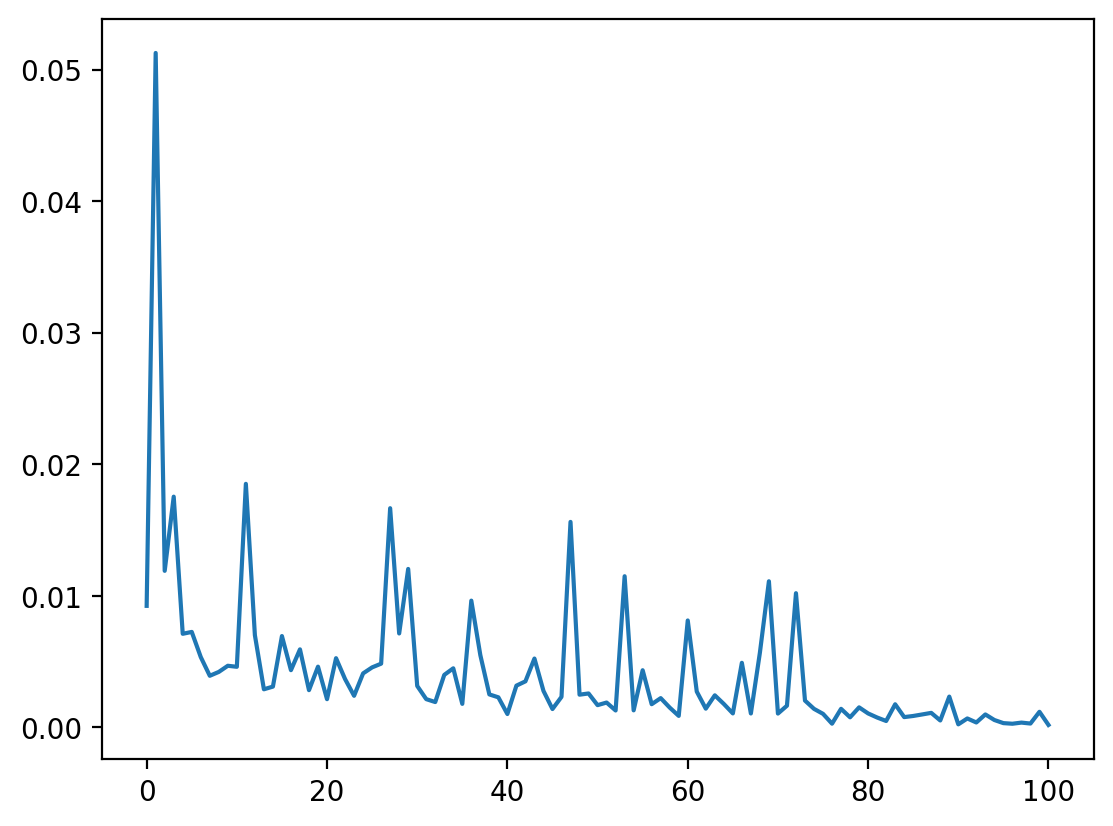

In [468]:
keys = np.array([key for key in dic_allquant if len(dic_allquant[key])])
best_frs = [list(dic_allquant[key].values())[0][-1]for key in keys]
keys = keys[best_frs]
dic_allquant = {key:dic_allquant[key] for key in keys}
#plt.plot()

{'SNc-VTA-RAmb Foxa1 Dopa': (78, 541, 0.14417744916820702),
 'PAG Tcf24 Glut': (11, 78, 0.14102564102564102),
 'PVH-SO-PVa Otp Glut': (22, 168, 0.13095238095238096),
 'LHA Pmch Glut': (7, 57, 0.12280701754385964),
 'HB Calcb Chol': (32, 281, 0.11387900355871886),
 'NI-RPO Gata3 Nr4a2 Gaba': (61, 551, 0.11070780399274047),
 'PH Pitx2 Glut': (212, 2057, 0.10306271268838113),
 'PH-LHA Foxb1 Glut': (128, 1274, 0.10047095761381476),
 'MB-MY Tph2 Glut-Sero': (92, 948, 0.0970464135021097),
 'PRT Tcf7l2 Gaba': (102, 1067, 0.09559512652296158),
 'ARH-PVp Tbx3 Glut': (61, 651, 0.09370199692780339),
 'SCop Sln Glut': (5, 54, 0.09259259259259259),
 'PAG-MRN Pou3f1 Glut': (25, 285, 0.08771929824561403),
 'CS-PRNr-DR En1 Sox2 Gaba': (59, 690, 0.08550724637681159),
 'PRC-PAG Tcf7l2 Irx2 Glut': (127, 1612, 0.07878411910669975),
 'PVpo-VMPO-MPN Hmx2 Gaba': (54, 720, 0.075),
 'VMH Nr5a1 Glut': (99, 1379, 0.07179115300942712),
 'NDB-SI-MA-STRv Lhx8 Gaba': (48, 674, 0.0712166172106825),
 'TU-ARH Otp Six6 

Text(0, 0.5, 'Number of cells')

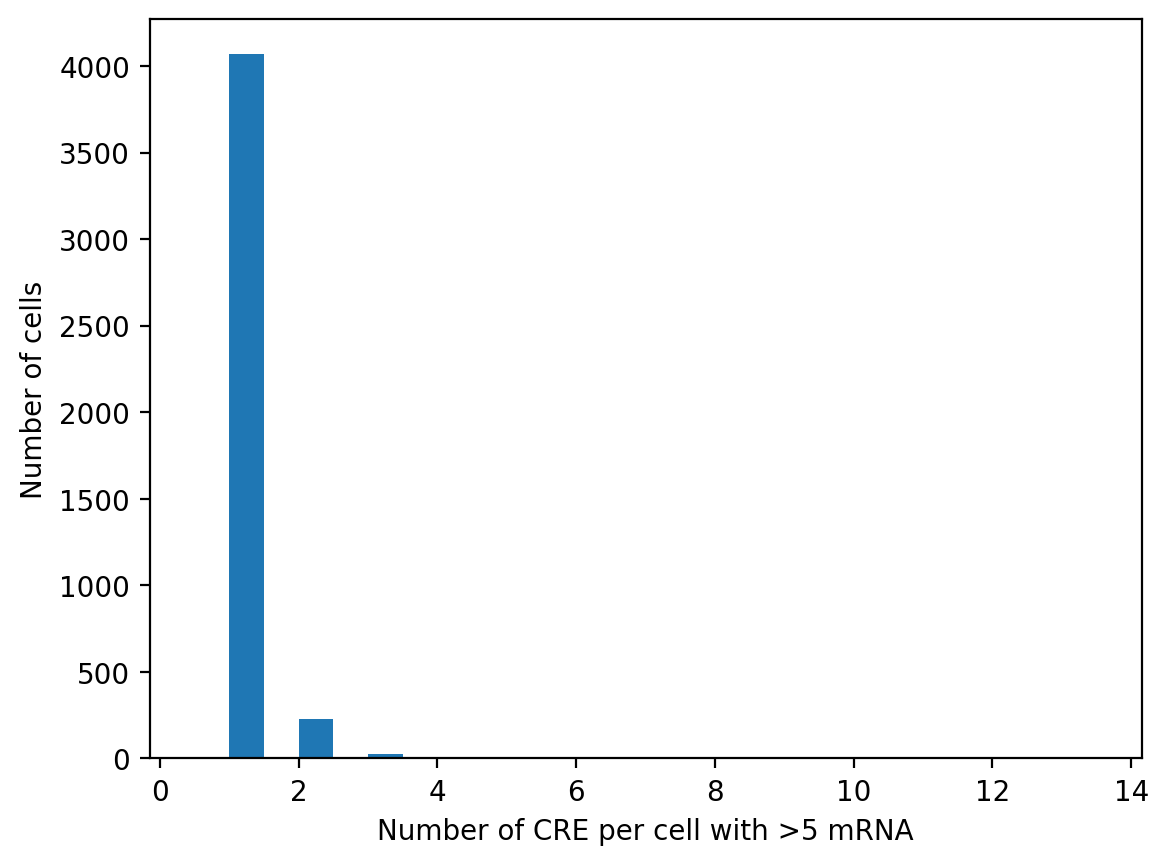

In [426]:
icell,icts = np.unique(icellP,return_counts=True)
plt.hist(icts,log=False,bins=np.arange(0.5,14,0.5))
plt.xlabel("Number of CRE per cell with >5 mRNA")
plt.ylabel('Number of cells')

In [308]:
4337/250000

0.017348

In [36]:
leiden = np.array(scdata.obs['leiden']).astype(np.int64)
uleiden = np.unique(leiden)

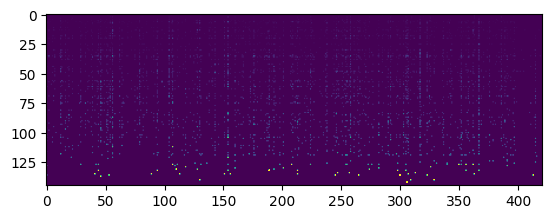

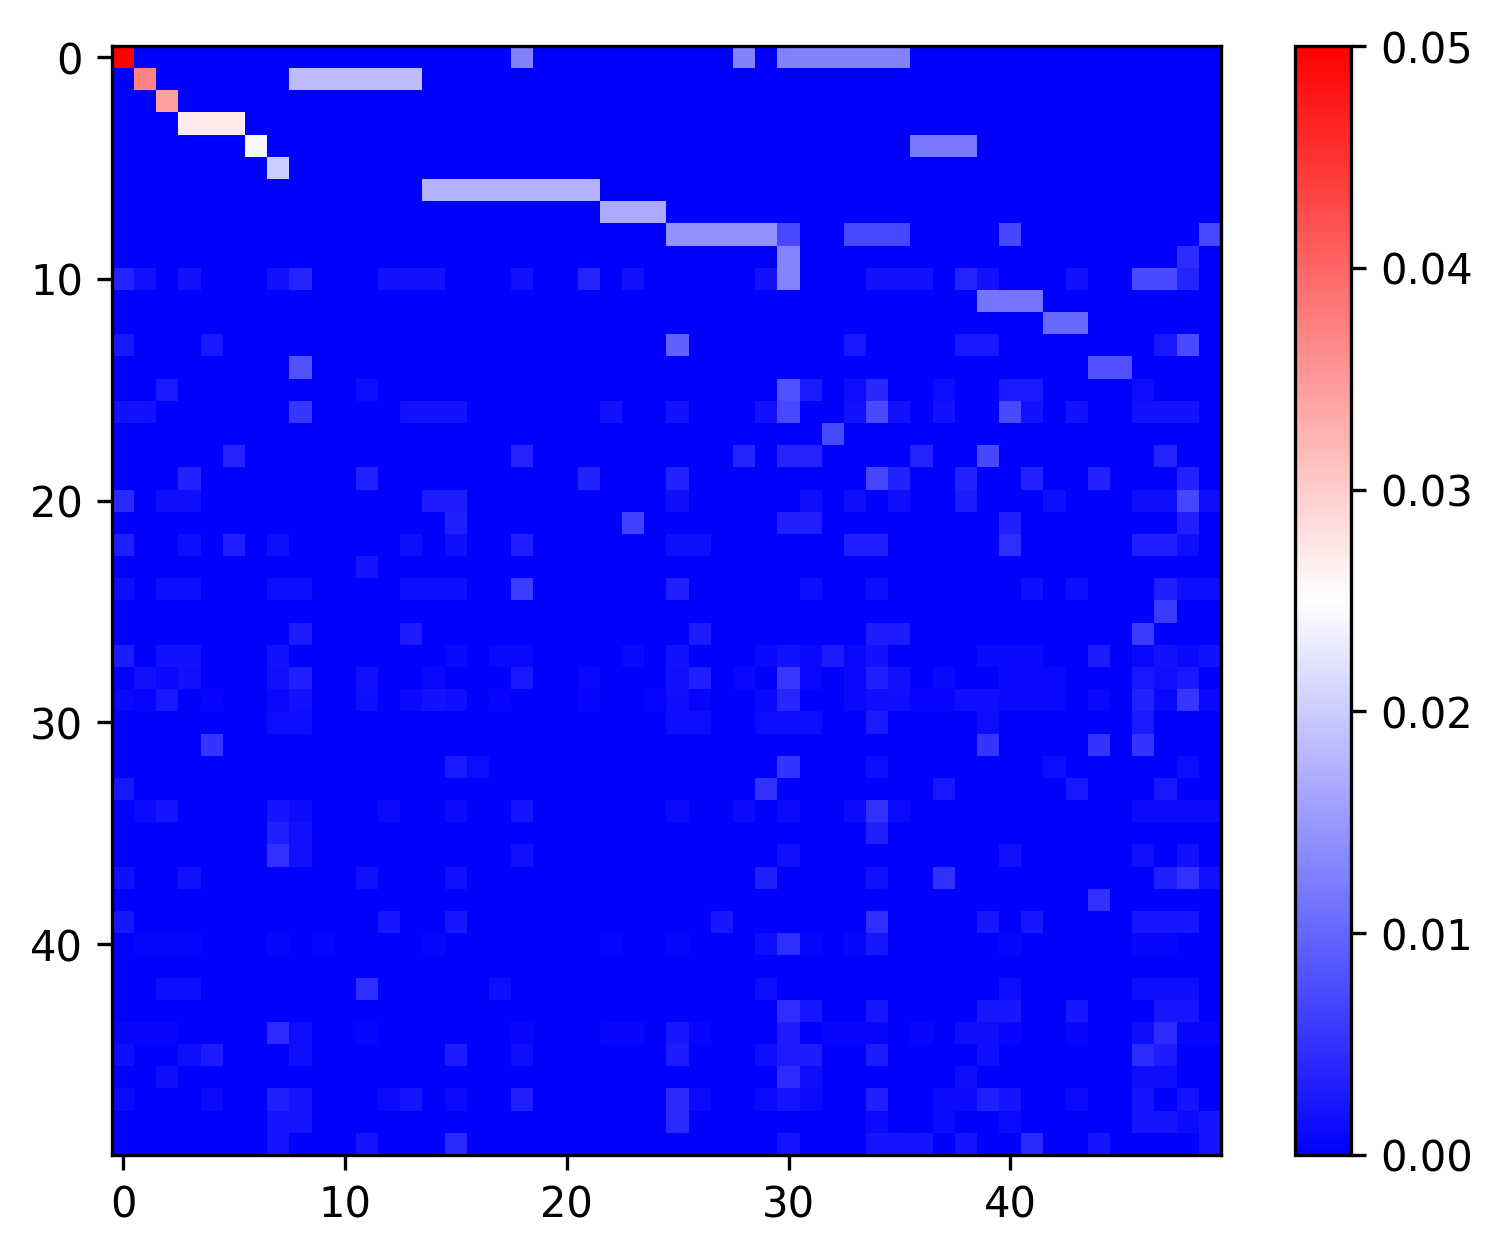

In [199]:
cre_df = scdata.obsm['CRE']
creM = np.array(cre_df)
cres = list(cre_df.columns)

icells,icres = np.where(creM>=5)
leiden_cre = leiden[icells]
icls,icts = np.unique(leiden_cre,return_counts=True)
dic_cts_allCre = dict(zip(icls,icts))
icls,icts = np.unique(leiden,return_counts=True)
dic_cts_all = dict(zip(icls,icts))
frs2 = [dic_cts_allCre.get(i,0)/dic_cts_all[i] for i in dic_cts_all]


Mleid = np.max(leiden)+1
Mcre = len(cres)+1
ileicre,icts = np.unique(leiden_cre+icres*Mleid,return_counts=True)
Mfr = np.zeros([Mleid,Mcre])
Mfr[ileicre%Mleid,ileicre//Mleid]=icts
Mcts = Mfr.copy()
uleiden,uctsleiden = np.unique(leiden,return_counts=True)
Mfr = Mfr/uctsleiden[:,np.newaxis]

plt.imshow(Mfr,vmax=0.01)
plt.figure(dpi=300)
plt.imshow(Mfr[np.argsort(np.max(Mfr,axis=1))[::-1]][:,np.argsort(np.max(Mfr,axis=0))[::-1]][:50,:50],vmax=0.05,cmap='bwr')
plt.colorbar()

In [196]:
clsO,creO = np.unravel_index(np.argsort(Mfr.ravel())[::-1][:50],Mfr.shape)
print(list(zip(clsO,creO)))

[(132, 189), (136, 300), (142, 306), (140, 309), (140, 329), (140, 130), (131, 110), (137, 46), (136, 413), (136, 323), (136, 265), (136, 53), (136, 0), (136, 245), (135, 156), (135, 41), (135, 363), (135, 151), (135, 213), (135, 89), (135, 307), (135, 113), (134, 313), (134, 247), (134, 257), (127, 208), (127, 362), (127, 350), (127, 356), (127, 107), (121, 154), (104, 154), (132, 356), (132, 213), (132, 44), (132, 94), (132, 305), (132, 367), (132, 154), (132, 298), (131, 128), (131, 193), (131, 274), (130, 160), (130, 201), (130, 282), (129, 326), (129, 118), (112, 107), (128, 109)]


In [191]:
icl,icre = (118, 367)
Mfr[icl,icre]*dic_cts_all[icl],dic_cts_all[icl]

(2.0, 285)

In [182]:
dic_cts_all[140]

57

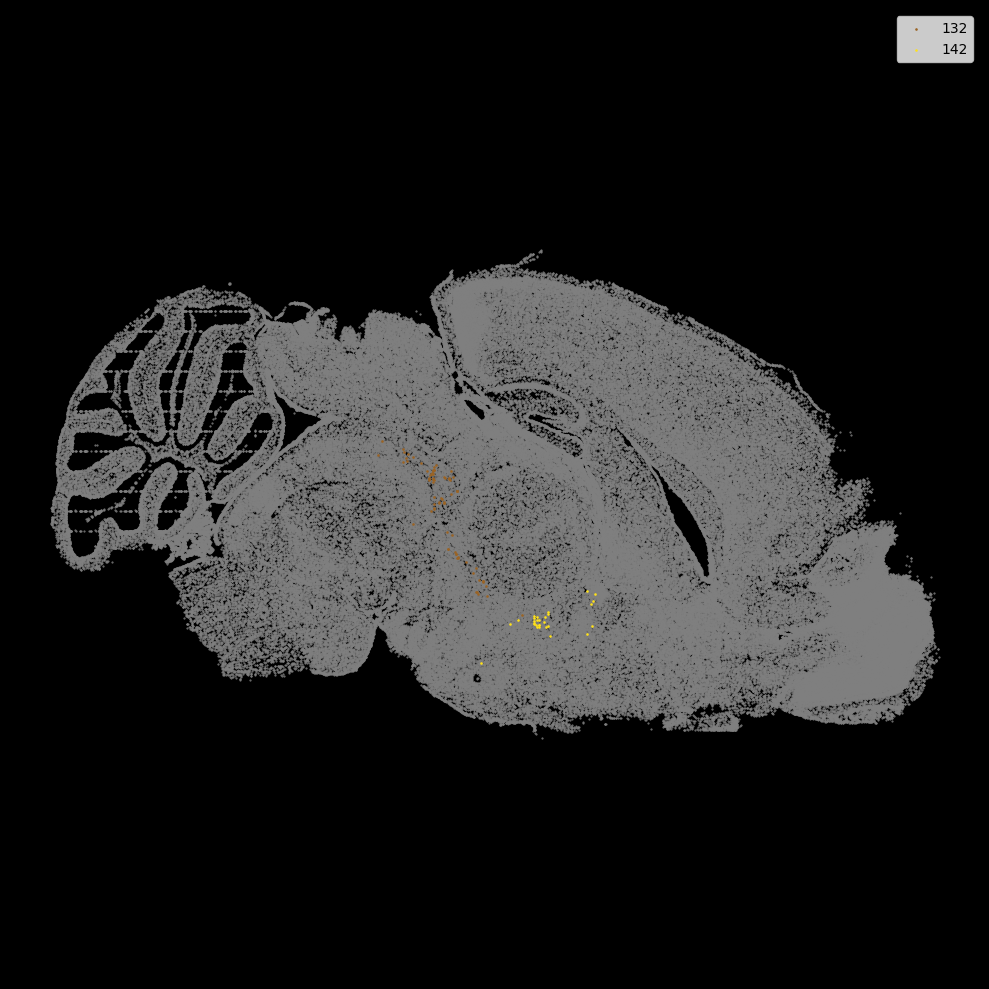

In [184]:
plot_cluster_scdata(scdata,clusters=[132,142],transpose=-1,flipx=-1,flipy=-1,sbig=3,small=1,plot_legend = True);

array([12043,  8851,  8716,  7987,  7102,  6653,  6443,  5889,  5703,
        5378,  5340,  4567,  4407,  4393,  4144,  4101,  3939,  3921,
        3909,  3805,  3723,  3684,  3665,  3422,  3416,  3209,  3131,
        3075,  2943,  2873,  2798,  2738,  2482,  2403,  2104,  2057,
        2039,  2030,  1965,  1953,  1900,  1884,  1834,  1810,  1798,
        1777,  1722,  1682,  1612,  1595,  1542,  1540,  1529,  1440,
        1437,  1416,  1413,  1379,  1376,  1312,  1277,  1274,  1265,
        1248,  1245,  1212,  1151,  1142,  1136,  1067,  1037,  1010,
         981,   970,   951,   948,   944,   902,   901,   893,   843,
         816,   813,   775,   763,   760,   736,   720,   709,   693,
         690,   674,   659,   651,   628,   622,   619,   611,   591,
         569,   567,   560,   551,   549,   541,   501,   491,   490,
         487,   455,   445,   433,   415,   410,   408,   396,   353,
         315,   285,   281,   268,   230,   219,   208,   191,   176,
         140,   139,

In [122]:
icells,icres = np.where(creM>=10)
leiden_cre = leiden[icells]
icls,icts = np.unique(leiden_cre,return_counts=True)
dic_cts_allCre = dict(zip(icls,icts))
icls,icts = np.unique(leiden,return_counts=True)
dic_cts_all = dict(zip(icls,icts))
frs2 = [dic_cts_allCre.get(i,0)/dic_cts_all[i] for i in dic_cts_all]

print(np.argsort(frs2)[::-1][:20])


cresCl,ctsCl = np.unique(icres[leiden_cre==35],return_counts=True)
reorder = np.argsort(ctsCl)[::-1]
list(zip(cresCl[reorder],ctsCl[reorder]))

[127 132 104 102  35  69  93 118  75  61 135  87 119  90  56  48  71  57
  91 111]


[(56, 8),
 (176, 5),
 (258, 5),
 (104, 5),
 (2, 4),
 (290, 4),
 (193, 3),
 (107, 3),
 (352, 3),
 (306, 3),
 (282, 2),
 (13, 2),
 (252, 2),
 (246, 2),
 (238, 2),
 (222, 2),
 (415, 2),
 (51, 2),
 (189, 2),
 (43, 2),
 (177, 2),
 (292, 2),
 (151, 2),
 (125, 2),
 (122, 2),
 (29, 2),
 (62, 2),
 (187, 2),
 (201, 2),
 (305, 2),
 (303, 2),
 (376, 2),
 (325, 2),
 (326, 2),
 (307, 2),
 (397, 2),
 (317, 2),
 (367, 2),
 (85, 1),
 (91, 1),
 (79, 1),
 (52, 1),
 (106, 1),
 (75, 1),
 (68, 1),
 (64, 1),
 (359, 1),
 (358, 1),
 (344, 1),
 (382, 1),
 (293, 1),
 (49, 1),
 (391, 1),
 (131, 1),
 (44, 1),
 (396, 1),
 (41, 1),
 (39, 1),
 (33, 1),
 (22, 1),
 (19, 1),
 (16, 1),
 (398, 1),
 (12, 1),
 (11, 1),
 (7, 1),
 (5, 1),
 (128, 1),
 (340, 1),
 (132, 1),
 (138, 1),
 (299, 1),
 (281, 1),
 (277, 1),
 (270, 1),
 (264, 1),
 (300, 1),
 (255, 1),
 (251, 1),
 (244, 1),
 (226, 1),
 (313, 1),
 (217, 1),
 (211, 1),
 (208, 1),
 (207, 1),
 (206, 1),
 (198, 1),
 (323, 1),
 (192, 1),
 (186, 1),
 (185, 1),
 (181, 1),
 (329,

In [91]:
189

array([127, 132, 104, 102,  35,  69,  93, 118,  75,  61, 135,  87, 119,
        90,  56,  48,  71,  57,  91, 111], dtype=int64)

[(154, 7),
 (317, 4),
 (258, 4),
 (352, 3),
 (397, 2),
 (12, 2),
 (56, 2),
 (104, 2),
 (189, 2),
 (193, 2),
 (0, 2),
 (363, 2),
 (336, 1),
 (85, 1),
 (173, 1),
 (160, 1),
 (362, 1),
 (151, 1),
 (146, 1),
 (130, 1),
 (124, 1),
 (118, 1),
 (93, 1),
 (80, 1),
 (188, 1),
 (77, 1),
 (64, 1),
 (62, 1),
 (367, 1),
 (54, 1),
 (51, 1),
 (46, 1),
 (14, 1),
 (373, 1),
 (5, 1),
 (187, 1),
 (357, 1),
 (337, 1),
 (343, 1),
 (312, 1),
 (305, 1),
 (304, 1),
 (300, 1),
 (297, 1),
 (292, 1),
 (288, 1),
 (277, 1),
 (274, 1),
 (265, 1),
 (247, 1),
 (349, 1),
 (246, 1),
 (245, 1),
 (238, 1),
 (231, 1),
 (227, 1),
 (224, 1),
 (388, 1),
 (213, 1),
 (198, 1),
 (196, 1),
 (219, 1)]

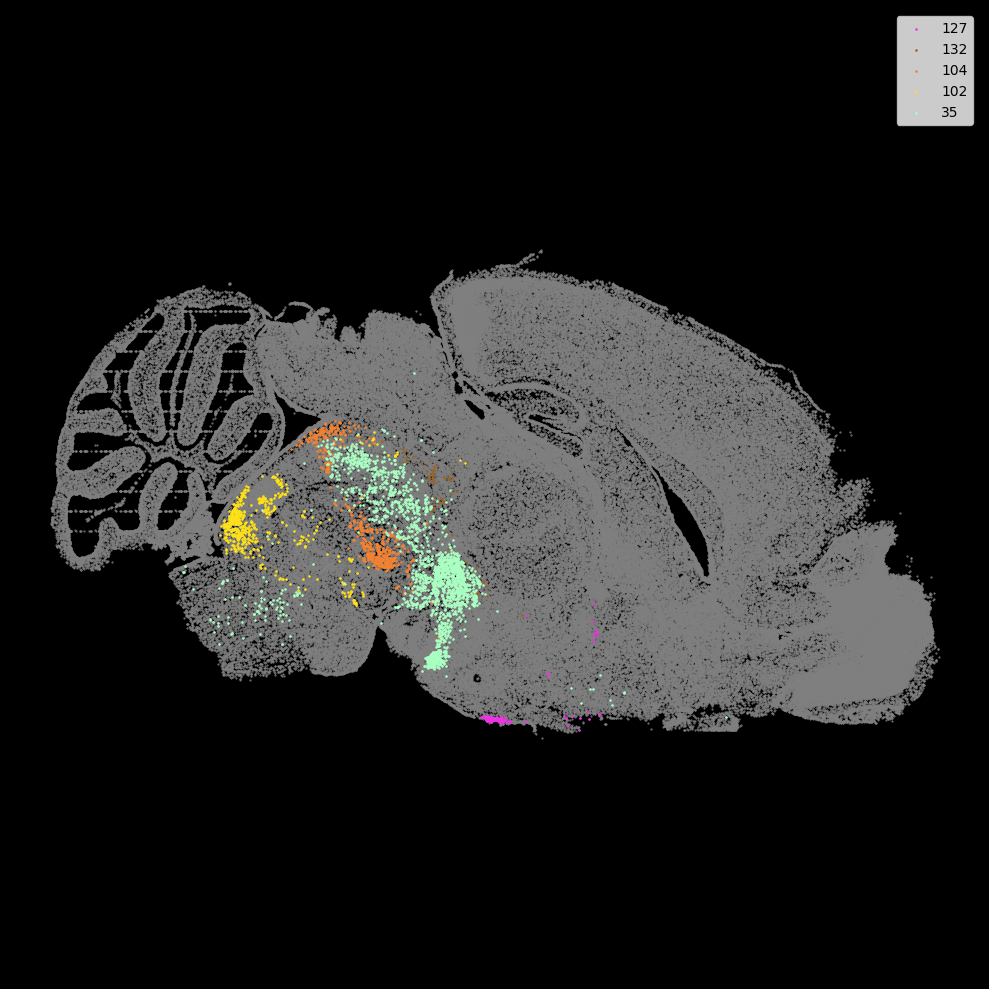

In [75]:
plot_cluster_scdata(scdata,clusters=np.argsort(frs2)[::-1][:5],transpose=-1,flipx=-1,flipy=-1,sbig=3,small=1,plot_legend = True);

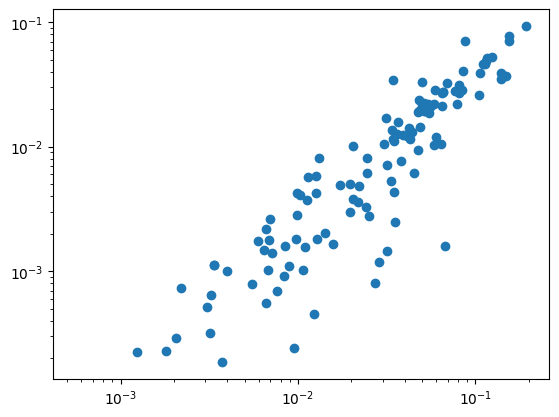

In [64]:

from matplotlib import pyplot as plt
plt.loglog(frs1,frs2,'o')